# Start

In [ ]:
ticker = "STRS.TA"

In [ ]:
ticker = ticker.upper()

In [ ]:
from typing import Any, Dict, Optional
import pandas as pd

def _df_to_table_payload(
    df: pd.DataFrame,
    scale_abs_gt: float = 1,
) -> Dict[str, Any]:
    if df is None or getattr(df, "empty", True):
        return {"index": [], "columns": [], "values": []}

    df2 = df.copy()

    if scale_abs_gt != 1:
        def _scale(x):
            if isinstance(x, (int, float)) and abs(x) > 2:
                return x / scale_abs_gt
            return x

        df2 = df2.applymap(_scale)

    df2 = df2.where(pd.notnull(df2), None)

    return {
        "index": [str(x) for x in df2.index.tolist()],
        "columns": [str(c) for c in df2.columns.tolist()],
        "values": df2.values.tolist(),
    }



In [ ]:
def df_to_llm_markdown(df: pd.DataFrame, scale_abs_gt: float = 1.0) -> str:
    """
    Converts a financial data DataFrame into an LLM-optimized Markdown table.
    Performs axis transposition, scaling, and handling of missing values.
    """
    if df is None or getattr(df, "empty", True):
        return ""

    # 1. Create a copy and transpose the axes
    # Dates become rows, and metrics (Net Debt, Revenue, etc.) become columns
    df_llm = df.copy().T

    # Give the index column a clear name to provide context to the model
    df_llm.index.name = "Reporting_Period"

    # 2. Apply scaling if necessary
    if scale_abs_gt != 1:
        def _scale(x):
            # Ensure the value is numeric and not NaN before dividing
            if isinstance(x, (int, float)) and pd.notna(x) and abs(x) > 2:
                return x / scale_abs_gt
            return x

        # Backward compatibility for Pandas (applymap was replaced by map in newer versions)
        if hasattr(df_llm, "map"):
            df_llm = df_llm.map(_scale)
        else:
            df_llm = df_llm.applymap(_scale)

    # 3. Handle missing values
    # LLMs process "N/A" or "-" much better than "NaN" or "None", which can be confusing
    df_llm = df_llm.fillna("N/A")

    # 4. Convert to Markdown format
    return df_llm.to_markdown()

In [ ]:
def df_to_llm_csv(df: pd.DataFrame, scale_abs_gt: float = 1.0) -> str:
    """
    Converts a financial data DataFrame into an LLM-optimized CSV format.
    Performs axis transposition, scaling, rounding, and handling of missing values.
    """
    if df is None or getattr(df, "empty", True):
        return ""

    # 1. Create a copy and transpose the axes
    # Dates become rows, and metrics (Net Debt, Revenue, etc.) become columns
    df_llm = df.copy().T

    # Give the index column a clear name to provide context to the model
    df_llm.index.name = "Reporting_Period"

    # Optional but highly recommended: Drop columns that are completely NaN to save tokens
    df_llm = df_llm.dropna(axis=1, how='all')

    # 2. Apply scaling if necessary
    if scale_abs_gt != 1:
        def _scale(x):
            # Ensure the value is numeric and not NaN before dividing
            if isinstance(x, (int, float)) and pd.notna(x) and abs(x) > 2:
                return x / scale_abs_gt
            return x

        # Backward compatibility for Pandas (applymap was replaced by map in newer versions)
        if hasattr(df_llm, "map"):
            df_llm = df_llm.map(_scale)
        else:
            df_llm = df_llm.applymap(_scale)

    # 3. Round numeric values to 2 decimal places (Saves a massive amount of tokens)
    for col in df_llm.columns:
        if pd.api.types.is_numeric_dtype(df_llm[col]):
            df_llm[col] = df_llm[col].round(2)

    # 4. Convert to CSV format
    # na_rep="N/A" explicitly tells the LLM that a value is missing, preventing hallucinations
    return df_llm.to_csv(na_rep="N/A")

In [ ]:
from __future__ import annotations

from copy import deepcopy
from typing import Any, Dict, Iterable, Optional, Set, Tuple
import yfinance as yf


def _is_number(x: Any) -> bool:
    return isinstance(x, (int, float)) and not isinstance(x, bool)


def _convert_range_str(value: str, factor: float) -> str:
    """
    Converts strings like: "38670.0 - 40070.0" by applying factor to both ends.
    If parsing fails, returns the original string.
    """
    if not isinstance(value, str):
        return value
    parts = [p.strip() for p in value.split("-")]
    if len(parts) != 2:
        return value
    try:
        a = float(parts[0])
        b = float(parts[1])
        return f"{a * factor:.4f} - {b * factor:.4f}"
    except Exception:
        return value


# Reasonable default "price-ish" keys in yfinance .info for TASE tickers (agorot-based quotes)
DEFAULT_PRICE_KEYS: Set[str] = {
    # spot / OHLC
    "currentPrice",
    "previousClose",
    "open",
    "dayLow",
    "dayHigh",
    "regularMarketPreviousClose",
    "regularMarketOpen",
    "regularMarketDayLow",
    "regularMarketDayHigh",
    "regularMarketPrice",
    "bid",
    "ask",

    # moving averages
    "fiftyDayAverage",
    "twoHundredDayAverage",

    # 52w / all-time levels
    "fiftyTwoWeekLow",
    "fiftyTwoWeekHigh",
    "allTimeHigh",
    "allTimeLow",

    # absolute price changes (IMPORTANT)
    "regularMarketChange",
    "fiftyTwoWeekLowChange",
    "fiftyTwoWeekHighChange",
    "fiftyDayAverageChange",
    "twoHundredDayAverageChange",

    # dividends per share (quoted in trading currency)
    "dividendRate",
    "trailingAnnualDividendRate",
    "lastDividendValue",

    # analysis
    "targetHighPrice",
    "targetLowPrice",
    "targetMeanPrice",
    "targetMedianPrice",
}

# Strings that embed price ranges
DEFAULT_PRICE_RANGE_STR_KEYS: Set[str] = {
    "regularMarketDayRange",
    "fiftyTwoWeekRange",
}

# Reasonable default "financial-ish" keys that are in ILS and should be divided by FX only
DEFAULT_FINANCIAL_KEYS: Set[str] = {
    "totalCash",
    "totalDebt",
    "totalRevenue",
    "grossProfits",
    "ebitda",
    "netIncomeToCommon",
    "freeCashflow",
    "operatingCashflow",
    "bookValue",
    "totalCashPerShare",
    "revenuePerShare",
    # "trailingEps",
    "epsTrailingTwelveMonths",
}


def convert_price_keys_to_usd(
    info: Dict[str, Any],
    *,
    to_usd: float = 1,
    price_keys: Optional[Iterable[str]] = None,
    range_str_keys: Optional[Iterable[str]] = None,
    update_currency_fields: bool = True,
) -> Dict[str, Any]:
    """
    Converts *price-related* fields:
      agorot -> ILS (divide by 100) -> USD (divide by to_usd)

    Returns a NEW dict, does not mutate input.
    """
    out = deepcopy(info)

    pkeys = set(price_keys) if price_keys is not None else set(DEFAULT_PRICE_KEYS)
    rkeys = set(range_str_keys) if range_str_keys is not None else set(DEFAULT_PRICE_RANGE_STR_KEYS)

    factor = 1.0 / to_usd

    for k in pkeys:
        if k in out and _is_number(out[k]):
            out[k] = out[k] * factor

    for k in rkeys:
        if k in out and isinstance(out[k], str):
            out[k] = _convert_range_str(out[k], factor)

    # Optional: update quote currency marker
    if update_currency_fields:
        # yfinance sometimes uses "ILA" for agorot-based quotes on TASE; after conversion we want USD
        if "currency" in out:
            out["currency"] = "USD"

    return out


def convert_financial_keys_to_usd(
    info: Dict[str, Any],
    *,
    to_usd: float = 1,
    financial_keys: Optional[Iterable[str]] = None,
    update_currency_fields: bool = True,
) -> Dict[str, Any]:
    """
    Converts *financial* fields that are already in ILS:
      ILS -> USD (divide by to_usd)

    Returns a NEW dict, does not mutate input.
    """
    out = deepcopy(info)

    fkeys = set(financial_keys) if financial_keys is not None else set(DEFAULT_FINANCIAL_KEYS)
    factor = 1.0 / to_usd

    if out.get("currency") == "USD":
        keys_to_remove = {"bookValue", "revenuePerShare", "totalCashPerShare", "trailingEps", "epsTrailingTwelveMonths"}
        fkeys = fkeys - keys_to_remove

    for k in fkeys:
        if k in out and _is_number(out[k]):
            out[k] = out[k] * factor

    if update_currency_fields:
        if "financialCurrency" in out:
            out["financialCurrency"] = "USD"

    return out

def find_currency(curr):
    currency_tickers = {
    # --- Israel ---
    'ILA': "ILS=X",   # Israeli Agorot (Minor unit of ILS)
    'ILS': "ILS=X",   # Israeli New Shekel

    # --- North America ---
    'CAD': "CAD=X",   # Canadian Dollar
    'MXN': "MXN=X",   # Mexican Peso

    # --- Europe ---
    'EUR': "EUR=X",   # Euro
    'GBP': "GBP=X",   # British Pound Sterling
    'GBp': "GBP=X",   # British Pence (Minor unit of GBP)
    'CHF': "CHF=X",   # Swiss Franc
    'SEK': "SEK=X",   # Swedish Krona
    'NOK': "NOK=X",   # Norwegian Krone
    'RUB': "RUB=X",   # Russian Ruble

    # --- Asia & Pacific ---
    'JPY': "JPY=X",   # Japanese Yen
    'CNY': "CNY=X",   # Chinese Yuan
    'HKD': "HKD=X",   # Hong Kong Dollar
    'TWD': "TWD=X",   # Taiwan Dollar
    'KRW': "KRW=X",   # South Korean Won
    'INR': "INR=X",   # Indian Rupee
    'SGD': "SGD=X",   # Singapore Dollar
    'AUD': "AUD=X",   # Australian Dollar
    'NZD': "NZD=X",   # New Zealand Dollar

    # --- South America & Africa ---
    'BRL': "BRL=X",   # Brazilian Real
    'ZAR': "ZAR=X",   # South African Rand
    'ZAC': "ZAR=X",   # South African Cent (Minor unit of ZAR)
    'TRY': "TRY=X",   # Turkish Lira
}

    try:
      ticker_obj = yf.Ticker(currency_tickers[curr])
      currency_rate = ticker_obj.info.get("regularMarketPrice", 1)
    except:
      currency_rate = 1

    if curr in ['ILA', 'GBp', 'ZAC']:
        currency_rate = currency_rate * 100

    return currency_rate

def recalculate_derived_metrics(info: Dict[str, Any]) -> Dict[str, Any]:
    """
    Recalculates ratios like PE, PriceToBook, EV, etc. based on the
    unifed USD values of price and financials.
    """
    # 1. Ensure basic values exist
    price = info.get("currentPrice")
    shares = info.get("impliedSharesOutstanding") or info.get("sharesOutstanding")

    if not price or not shares:
        return info

    # 2. Recalculate Market Cap (Must be accurate for other calcs)
    market_cap = price * shares
    info["marketCap"] = market_cap

    # 3. Recalculate EPS (Net Income / Shares)
    # YFinance often reports EPS in ILS even if financials are USD.
    # Best to recalc from Net Income which is reliable.
    net_income = info.get("netIncomeToCommon")
    if _is_number(net_income):
        info["trailingEps"] = net_income / shares
        # Now Recalculate PE
        if info["trailingEps"] > 0:
            info["trailingPE"] = price / info["trailingEps"]
        else:
            info["trailingPE"] = None

    # 4. Recalculate Price to Book
    book_value = info.get("bookValue") # Assumed to be in USD after conversion
    if _is_number(book_value) and book_value != 0:
        info["priceToBook"] = price / book_value

    # 5. Recalculate Enterprise Value (EV)
    # EV = Market Cap + Total Debt - Total Cash
    total_debt = info.get("totalDebt")
    total_cash = info.get("totalCash")

    if _is_number(total_debt) and _is_number(total_cash):
        ev = market_cap + total_debt - total_cash
        info["enterpriseValue"] = ev

    # 6. EV based ratios
        ebitda = info.get("ebitda")
        if _is_number(ebitda) and ebitda != 0:
            info["enterpriseToEbitda"] = ev / ebitda

        revenue = info.get("totalRevenue")
        if _is_number(revenue) and revenue != 0:
            info["enterpriseToRevenue"] = ev / revenue

    # 7. Dividend ratios - FIXED
    yield_val = info.get("dividendYield")

    if _is_number(price) and _is_number(yield_val):
        if yield_val > 0.5:
            yield_decimal = yield_val / 100.0
        else:
            yield_decimal = yield_val

        calculated_rate = price * yield_decimal

        info["dividendRate"] = calculated_rate

    else:
        info.pop("dividendRate", None)
        info.pop("trailingAnnualDividendRate", None)

    # 8. Recalculate Price to Sales (P/S)
    revenue = info.get("totalRevenue")
    if _is_number(revenue) and revenue > 0:
        info["priceToSalesTrailing12Months"] = market_cap / revenue

    return info

In [ ]:
def get_advanced_financial_summary(data):
    financial_keys = [

        'totalRevenue', 'revenueGrowth', 'grossProfits', 'ebitda',
        'netIncomeToCommon', 'totalCash', 'totalDebt', 'freeCashflow', 'operatingCashflow',

        'earningsGrowth', 'earningsQuarterlyGrowth',

        'grossMargins', 'operatingMargins', 'ebitdaMargins', 'profitMargins',
        'returnOnEquity', 'returnOnAssets',

        'trailingEps', 'forwardEps', 'bookValue',

        'currentRatio', 'quickRatio', 'debtToEquity'
    ]

    return {key: data.get(key) for key in financial_keys if key in data}

# YF.INFO AGENT

In [ ]:
import pandas as pd

# no warnings:
import warnings
warnings.filterwarnings('ignore')

def get_info_data(ticker: str) -> dict:
    info_dict = {}
    ticker_obj = yf.Ticker(ticker)
    fin_rate = 1.0
    price_rate = 1.0

    try:
        raw_info = ticker_obj.info

        # --- 1. Identify Currencies ---
        fin_curr_name = raw_info.get("financialCurrency", 'USD')
        price_curr_name = raw_info.get("currency", 'USD')

        if fin_curr_name != "USD" or price_curr_name != "USD":

          # Get Rates
          if fin_curr_name != "USD":
              fin_rate = find_currency(fin_curr_name)

          if price_curr_name != "USD":
              price_rate = find_currency(price_curr_name)

          # --- 2. Convert Data ---
          # Convert Financials if needed
          if fin_curr_name != "USD":
              raw_info = convert_financial_keys_to_usd(raw_info, to_usd=fin_rate)

          # Convert Prices if needed (Handles Agorot too)
          if price_curr_name != "USD":
              raw_info = convert_price_keys_to_usd(raw_info, to_usd=price_rate)

          # --- 3. RECALCULATE (The New Step) ---
          # This fixes the mixed currency ratios and the broken EPS
          raw_info = recalculate_derived_metrics(raw_info)

        # --- 4. Metadata ---
        info_dict["info"] = raw_info
        info_dict["info"]["original_price_currency"] = price_curr_name
        info_dict["info"]["original_financial_currency"] = fin_curr_name
        info_dict["info"]["price_currency_to_USD"] = price_rate
        info_dict["info"]["financial_currency_to_USD"] = fin_rate

        info_dict["financials"] = get_advanced_financial_summary(raw_info)

        info_dict["change"] = raw_info.get("52WeekChange", 0)

    except Exception as e:
        print(f"Error processing {ticker}: {e}")
        info_dict["info"] = "Not available"
        info_dict["financials"] = "Not available"
        info_dict["change"] = 0

    try:
        info_dict["short_name"] = info_dict["info"].get("shortName")
    except:
        info_dict["short_name"] = False

    # --- Analyst data ---
    try:
        info_dict["price_targets"] = ticker_obj.analyst_price_targets
        for k, v in info_dict["price_targets"].items():
            info_dict["price_targets"][k] = v / price_rate

    except:
        info_dict["price_targets"] = []

    try:
        info_dict["recommendations"] = _df_to_table_payload(ticker_obj.recommendations)
    except:
        info_dict["recommendations"] = "Not available"

    try:
        info_dict["down_upgrades"] = _df_to_table_payload(ticker_obj.upgrades_downgrades)
    except:
        info_dict["down_upgrades"] = "Not available"

    try:
        info_dict["earnings_estimate"] = _df_to_table_payload(ticker_obj.earnings_estimate)
    except:
        info_dict["earnings_estimate"] = "Not available"

    try:
        info_dict["revenue_estimate"] = _df_to_table_payload(ticker_obj.revenue_estimate)
    except:
        info_dict["revenue_estimate"] = "Not available"

    try:
        info_dict["num_of_analysts"] = int(
            ticker_obj.revenue_estimate["numberOfAnalysts"].iloc[0]
        )
    except:
        info_dict["num_of_analysts"] = 0

    # --- News ---
    try:
        info_dict["news"] = ticker_obj.news
    except:
        info_dict["news"] = "Not available"

    # --- Options ---
    try:
        first_expiry = ticker_obj.options[0]
    except:
        first_expiry = None

    try:
        info_dict["calls"] = _df_to_table_payload(
            ticker_obj.option_chain(first_expiry).calls
        ) if first_expiry else "Not available"
    except:
        info_dict["calls"] = None

    try:
        info_dict["puts"] = _df_to_table_payload(
            ticker_obj.option_chain(first_expiry).puts
        ) if first_expiry else "Not available"
    except:
        info_dict["puts"] = None

    # --- Holders / insiders ---
    try:
        info_dict["insider_purchases"] = _df_to_table_payload(
            ticker_obj.insider_purchases
        )
    except:
        info_dict["insider_purchases"] = "Not available"

    try:
        info_dict["insider_transactions"] = _df_to_table_payload(
            ticker_obj.insider_transactions
        )
    except:
        info_dict["insider_transactions"] = "Not available"

    try:
        info_dict["insider_roster_holders"] = _df_to_table_payload(
            ticker_obj.institutional_holders
        )
    except:
        info_dict["insider_roster_holders"] = "Not available"

    try:
        info_dict["major_holders"] = _df_to_table_payload(
            ticker_obj.major_holders
        )
    except:
        info_dict["major_holders"] = "Not available"

    try:
        info_dict["institutional_holders"] = _df_to_table_payload(
            ticker_obj.institutional_holders
        )
    except:
        info_dict["institutional_holders"] = "Not available"

    try:
        info_dict["mutualfund_holders"] = _df_to_table_payload(
            ticker_obj.mutualfund_holders
        )
    except:
        info_dict["mutualfund_holders"] = "Not available"

    print(f"Downloaded info for {ticker}")
    return info_dict

info_dict = get_info_data(ticker)
# info_dict["info"]
# info_dict["insider_purchases"]
# info_dict["insider_transactions"]
# info_dict["insider_roster_holders"]
# info_dict["major_holders"]
# info_dict["institutional_holders"]
# info_dict["mutualfund_holders"]

# info_dict["price_targets"]
# info_dict["recommendations"]
# info_dict["down_upgrades"]
# info_dict["earnings_estimate"]
info_dict["revenue_estimate"]
# info_dict["num_of_analysts"]

# info_dict["news"]

# info_dict["calls"]
# info_dict["puts"]
# info_dict["info"]

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: STRS.TA"}}}


Downloaded info for STRS.TA


{'index': ['0q', '+1q', '0y', '+1y'],
 'columns': ['avg',
  'low',
  'high',
  'numberOfAnalysts',
  'yearAgoRevenue',
  'growth'],
 'values': [[3214000000.0, 3214000000.0, 3214000000.0, 1.0, nan, nan],
  [0.0, 0.0, 0.0, 0.0, nan, nan],
  [12554000000.0, 12554000000.0, 12554000000.0, 1.0, nan, nan],
  [12806000000.0, 12806000000.0, 12806000000.0, 1.0, 12554000000.0, 0.0201]]}

In [ ]:
ticker_obj = yf.Ticker(ticker)
ticker_obj.info

{'address1': '49 Hasivim Street',
 'address2': 'Kiryat Matalon',
 'city': 'Petah Tikva',
 'zip': '4959504',
 'country': 'Israel',
 'phone': '972 3 675 2499',
 'fax': '972 3 675 2279',
 'website': 'https://www.strauss-group.com',
 'industry': 'Packaged Foods',
 'industryKey': 'packaged-foods',
 'industryDisp': 'Packaged Foods',
 'sector': 'Consumer Defensive',
 'sectorKey': 'consumer-defensive',
 'sectorDisp': 'Consumer Defensive',
 'longBusinessSummary': "Strauss Group Ltd., together with its subsidiaries, develops, manufactures, markets, sells, and distributes various food and beverage products in Israel, North America, Brazil, Europe, and internationally. The company operates through six segments: Health & Wellness; Fun & Indulgence; Israel Coffee; International Coffee; Strauss Water; and Other. It offers yogurts, dairy desserts, soft cheeses, flavored milk beverages, soft cheeses, milk and beverages, flavored milk beverages, refrigerated dips and spreads, fresh pasta products, honey

In [ ]:
info_dict["info"]

{'address1': '49 Hasivim Street',
 'address2': 'Kiryat Matalon',
 'city': 'Petah Tikva',
 'zip': '4959504',
 'country': 'Israel',
 'phone': '972 3 675 2499',
 'fax': '972 3 675 2279',
 'website': 'https://www.strauss-group.com',
 'industry': 'Packaged Foods',
 'industryKey': 'packaged-foods',
 'industryDisp': 'Packaged Foods',
 'sector': 'Consumer Defensive',
 'sectorKey': 'consumer-defensive',
 'sectorDisp': 'Consumer Defensive',
 'longBusinessSummary': "Strauss Group Ltd., together with its subsidiaries, develops, manufactures, markets, sells, and distributes various food and beverage products in Israel, North America, Brazil, Europe, and internationally. The company operates through six segments: Health & Wellness; Fun & Indulgence; Israel Coffee; International Coffee; Strauss Water; and Other. It offers yogurts, dairy desserts, soft cheeses, flavored milk beverages, soft cheeses, milk and beverages, flavored milk beverages, refrigerated dips and spreads, fresh pasta products, honey

In [ ]:
info_dict["financials"]

{'totalRevenue': 2424128506.53925,
 'revenueGrowth': 0.097,
 'grossProfits': 714010219.2712634,
 'ebitda': 236515885.133606,
 'netIncomeToCommon': 213246802.09485498,
 'totalCash': 104870250.9554668,
 'totalDebt': 853624758.3043532,
 'freeCashflow': -45263147.8288033,
 'operatingCashflow': 99770177.96067207,
 'earningsGrowth': 0.282,
 'earningsQuarterlyGrowth': 0.283,
 'grossMargins': 0.29454002,
 'operatingMargins': 0.06962,
 'ebitdaMargins': 0.09757,
 'profitMargins': 0.087969996,
 'returnOnEquity': 0.22167999,
 'returnOnAssets': 0.039979998,
 'trailingEps': 1.8236061457813126,
 'forwardEps': 5.17,
 'bookValue': 8.822807526432722,
 'currentRatio': 1.017,
 'quickRatio': 0.631,
 'debtToEquity': 74.951}

In [ ]:
info_dict["change"]

0.7367573

# SEC AGENT


In [ ]:
pip install html2text

In [ ]:
import re
import json
import requests
import html2text
import pandas as pd
import io
from datetime import datetime, timedelta

HEADERS = {
    "User-Agent": "YourAppName your_email@domain.com",
    "Accept-Encoding": "gzip, deflate",
    "Host": "data.sec.gov"
}

def cik_from_ticker(ticker: str) -> str:
    url = "https://www.sec.gov/files/company_tickers.json"
    r = requests.get(url, headers={"User-Agent": HEADERS["User-Agent"]}, timeout=30)
    r.raise_for_status()
    data = r.json()
    ticker_u = ticker.upper()
    for _, row in data.items():
        if row["ticker"].upper() == ticker_u:
            return str(row["cik_str"]).zfill(10)
    raise ValueError(f"Ticker not found: {ticker}")

def get_recent_filings(cik10: str) -> dict:
    url = f"https://data.sec.gov/submissions/CIK{cik10}.json"
    # print(url)
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    return r.json()

def build_primary_doc_url(cik10: str, accession_no: str, primary_doc: str) -> str:
    acc_nodash = accession_no.replace("-", "")
    cik_nolead = str(int(cik10))
    return f"https://www.sec.gov/Archives/edgar/data/{cik_nolead}/{acc_nodash}/{primary_doc}"

def download_filing_text(url: str) -> str:
    r = requests.get(url, headers={"User-Agent": HEADERS["User-Agent"]}, timeout=60)
    r.raise_for_status()
    return r.text

def extract_tables_from_text(text_content):
    lines = text_content.split('\n')

    tables = []
    current_table = []
    in_table = False

    for line in lines:
        stripped = line.strip()

        if stripped.startswith('|') or (len(stripped.split('|')) > 2):

            if '---' in stripped:
                continue

            in_table = True

            row = [cell.strip() for cell in stripped.split('|') if cell.strip() != '']
            if row:
                current_table.append(row)
        else:
            if in_table:

                if len(current_table) > 1:
                    try:

                        df = pd.DataFrame(current_table[1:], columns=current_table[0])
                        json_df = _df_to_table_payload(df)
                        tables.append(json_df)
                    except:
                        df = pd.DataFrame(current_table)
                        json_df = _df_to_table_payload(df)
                        tables.append(json_df)
                current_table = []
                in_table = False

    return tables

def get_largest_6k_in_range(json_data, months_back=3, ref_date_str=None):
    """
    Identifies the best 6-K filing using a hybrid approach:
    1. Sorts candidates by size.
    2. Downloads content.
    3. Validates based on KEYWORDS (Semantic) AND TABLES (Structural).
    """

    # --- Configuration ---
    # Keywords that MUST appear in a financial report (usually in headers)
    FINANCIAL_KEYWORDS = [
        "CONSOLIDATED BALANCE SHEETS",
        "STATEMENTS OF OPERATIONS",
        "FINANCIAL POSITION",
        "CASH FLOWS",
        "UNAUDITED CONDENSED",
        "FINANCIAL RESULTS",
        "QUARTER"
    ]

    # 1. Date Setup
    if ref_date_str:
        current_date = datetime.strptime(ref_date_str, "%Y-%m-%d")
    else:
        current_date = datetime.now()

    cutoff_date = current_date - timedelta(days=30 * months_back)

    # 2. Extract Data
    recent = json_data['filings']['recent']
    cik = json_data['cik']

    candidates = []
    count = len(recent['accessionNumber'])

    # 3. Filter Candidates (Initial Screener)
    for i in range(count):
        form_type = recent['form'][i]
        filing_date_str = recent['filingDate'][i]
        filing_date = datetime.strptime(filing_date_str, "%Y-%m-%d")
        file_size = recent['size'][i]

        if form_type == '6-K' and (cutoff_date <= filing_date <= current_date):
            candidates.append({
                "index": i,
                "date": filing_date_str,
                "size": file_size,
                "accession_number": recent['accessionNumber'][i],
                "primary_document": recent['primaryDocument'][i]
            })

    if not candidates:
        print("No 6-K filings found in range.")
        return None

    # Sort by size (Descending) - Assume bigger is more likely to be the report
    sorted_candidates = sorted(candidates, key=lambda x: x['size'], reverse=True)

    # 4. Iterate, Download & Validate
    for candidate in sorted_candidates:
        print(f"Checking candidate 6-K from {candidate['date']} ({candidate['size']/1024:.0f} KB)...")

        acc_num_clean = candidate['accession_number'].replace('-', '')

        # --- Resolve URL (Try EX-99 Logic first) ---
        final_url = f"https://www.sec.gov/Archives/edgar/data/{cik}/{acc_num_clean}/{candidate['primary_document']}"
        try:
            index_json_url = f"https://www.sec.gov/Archives/edgar/data/{cik}/{acc_num_clean}/index.json"
            file_list_content = download_filing_text(index_json_url)
            if file_list_content:
                items = json.loads(file_list_content).get('directory', {}).get('item', [])
                for item in items:
                    name = item.get('name', '')
                    doc_type = item.get('type', '')
                    if ('EX-99' in doc_type or '99' in name) and name.lower().endswith(('htm', 'html')):
                        final_url = f"https://www.sec.gov/Archives/edgar/data/{cik}/{acc_num_clean}/{name}"
                        print(f"   -> Switched to Exhibit: {name}")
                        break
        except:
            pass

        # --- Content Validation ---
        try:
            html_content = download_filing_text(final_url)
            if not html_content: continue

            # Convert to Text
            h = html2text.HTML2Text()
            h.ignore_links = True; h.ignore_images = True; h.body_width = 0
            text_content = h.handle(html_content)

            # A. Check for Tables
            tables = extract_tables_from_text(text_content)
            table_count = len(tables)

            # B. Check for Keywords (in first 3000 chars - headers usually appear early)
            text_start = text_content[:5000].upper()
            found_keywords = [kw for kw in FINANCIAL_KEYWORDS if kw in text_start]

            print(f"   -> Tables: {table_count}, Keywords found: {found_keywords}")

            # --- DECISION LOGIC ---
            # 1. Must have at least 2 tables (Balance sheet + P&L)
            # 2. MUST have at least one financial keyword OR have a lot of tables (>5)
            is_valid = (table_count >= 2) and (len(found_keywords) > 1 or table_count > 5)

            if is_valid:
                print(f"   -> SUCCESS! Verified Financial Report.")
                index_url = f"https://www.sec.gov/Archives/edgar/data/{cik}/{candidate['accession_number']}-index.html"

                return {
                    "filing_date": candidate['date'],
                    "size_kb": int(candidate['size'] / 1024),
                    "direct_url": final_url,
                    "index_url": index_url,
                    "accession_number": candidate['accession_number'],
                    "pre_downloaded_content": {
                        "text": text_content,
                        "tables": tables
                    }
                }
            else:
                print("   -> Content validation failed (Not a financial report). Skipping.")

        except Exception as e:
            print(f"   -> Error checking content: {e}")
            continue

    return None

def latest_filing_full_text(ticker: str) -> dict:
    """
    Retrieves the full text and extracted tables of the latest filings for a given ticker.

    Logic:
    - For '6-K' forms (Foreign Private Issuers): It utilizes a helper function to find
      the largest file (by size) within the last 3 months, assuming this represents
      the full quarterly report rather than a generic press release.
    - For other forms ('10-Q', '10-K', '20-F'): It simply retrieves the most recent
      filing available in the SEC history.

    Args:
        ticker (str): The stock ticker symbol (e.g., 'NVMI', 'AAPL').

    Returns:
        dict: A dictionary where keys are form types and values contain the 'url',
              'text', 'tables', and 'date' of the filing.
    """
    # Define the list of forms to search for. Added 6-K for Israeli/Foreign companies.
    form_types = ["10-Q", "10-K", "20-F", "6-K"]
    files_dict = {}
    ticker = ticker.upper()

    try:
        # Retrieve CIK and the raw filing history JSON
        cik10 = cik_from_ticker(ticker)
        sub = get_recent_filings(cik10) # 'sub' is the full JSON response

        # Extract lists for the standard iteration logic
        recent = sub.get("filings", {}).get("recent", {})
        forms = recent.get("form", [])
        accessions = recent.get("accessionNumber", [])
        primary_docs = recent.get("primaryDocument", [])
        filing_dates = recent.get("filingDate", [])

        for form_type in form_types:
            target_url = None
            filing_date = None

            # ---------------------------------------------------------
            # Logic A: Special handling for 6-K (Find largest in range)
            # ---------------------------------------------------------
            if form_type == "6-K":
                # Calls the validation-based helper function
                best_6k = get_largest_6k_in_range(sub, months_back=3)

                if best_6k:
                    # Use the pre-downloaded content!
                    files_dict[form_type] = {
                        "url": best_6k['direct_url'],
                        "text": best_6k['pre_downloaded_content']['text'],
                        "tables": best_6k['pre_downloaded_content']['tables'],
                        "date": best_6k['filing_date']
                    }
                    print(f"Selected 6-K: {best_6k['size_kb']}KB from {best_6k['filing_date']}")
                    continue # Skip the common download step below because we already have the data

            # ---------------------------------------------------------
            # Logic B: Standard handling for 10-K, 10-Q, 20-F (Take newest)
            # ---------------------------------------------------------
            else:
                # Iterate through the lists to find the first (most recent) match
                for f, acc, doc, dt in zip(forms, accessions, primary_docs, filing_dates):
                    if f.upper() == form_type.upper():
                        target_url = build_primary_doc_url(cik10, acc, doc)
                        filing_date = dt
                        break # Stop after finding the first match

            # ---------------------------------------------------------
            # Common Download & Processing Step
            # ---------------------------------------------------------
            if target_url:
                try:
                    # Download HTML content
                    html = download_filing_text(target_url)
                    print(f"Downloaded HTML size: {len(html)}")

                    # Convert HTML to Clean Text
                    h = html2text.HTML2Text()
                    h.ignore_links = True
                    h.ignore_images = True
                    h.body_width = 0 # No line wrapping
                    text = h.handle(html)

                    print(f"Downloaded txt size: {len(text)}")

                    # Extract Tables
                    tables = extract_tables_from_text(text)
                    print(f"Extracted {len(tables)} tables from {form_type}")

                    # Store in result dictionary
                    files_dict[form_type] = {
                        "url": target_url,
                        "text": text,
                        "tables": tables,
                        "date": filing_date
                    }
                    print(f"Successfully processed {form_type} filing for {ticker} on {filing_date}")

                except Exception as download_error:
                    print(f"Failed to download/process {form_type}: {download_error}")

        return files_dict

    except Exception as e:
        print(f"General Error for {ticker}: {e}")
        files_dict["SEC"] = {
                        "url": None,
                        "text": None,
                        "tables": None,
                        "date": None
                    }
        return files_dict

files_dict = latest_filing_full_text(ticker)
for k, v in files_dict.items():
  if v["url"]:
    print(k, v["url"][:1000])
  else:
    print(k, v)
# files_dict["6-K"]["tables"][:1000]


General Error for STRS.TA: Ticker not found: STRS.TA
SEC {'url': None, 'text': None, 'tables': None, 'date': None}


# FINANCE AGENT


In [ ]:
import yfinance as yf
import pandas as pd

# no warnings:
import warnings
warnings.filterwarnings('ignore')

#  'original_price_currency': 'ILA',
#  'original_financial_currency': 'ILS',
#  'price_currency_to_USD': 3.1077,
#  'financial_currency_to_USD': 3.1077

def get_financial_data(ticker: str, info_dict: dict, info_financials: dict) -> dict:
    financial_dict = {}
    ticker_obj = yf.Ticker(ticker)

    # 1. Maintain original metadata keys
    financial_dict["info"] = info_dict
    financial_currency_rate = info_dict.get("financial_currency_to_USD", 1)
    financial_dict["currency_statement"] = "Financial data is in USD"
    financial_dict["info_financials"] = info_financials

    # Helper to wrap the original df_to_llm_csv with a name
    def get_named_table(df, title):
        try:
            # We call the new CSV conversion function
            csv_table = df_to_llm_csv(df, financial_currency_rate)

            # If the resulting CSV is empty, return "Not available"
            if not csv_table.strip():
                return f"### {title}\nNot available\n\n"

            # Wrap the CSV in markdown code blocks so the LLM parses it perfectly
            return f"### {title}\n```csv\n{csv_table}```\n\n"
        except:
            return f"### {title}\nNot available\n\n"

    # --- 2. Financials (Income Statement) ---
    financial_dict["financials_annual"] = get_named_table(ticker_obj.financials, "Annual Income Statement")
    financial_dict["financials_quarterly"] = get_named_table(ticker_obj.quarterly_financials, "Quarterly Income Statement")

    # --- 3. Balance Sheet ---
    financial_dict["balance_sheet_annual"] = get_named_table(ticker_obj.balance_sheet, "Annual Balance Sheet")
    financial_dict["balance_sheet_quarterly"] = get_named_table(ticker_obj.quarterly_balance_sheet, "Quarterly Balance Sheet")

    # --- 4. Cash Flow ---
    financial_dict["cashflow_annual"] = get_named_table(ticker_obj.cashflow, "Annual Cash Flow Statement")
    financial_dict["cashflow_quarterly"] = get_named_table(ticker_obj.quarterly_cashflow, "Quarterly Cash Flow Statement")

    # --- 5. Aggregates (Built as structured strings instead of raw tuples) ---
    try:
        # Maintaining your order: Balance Sheet, Cashflow, Financials
        financial_dict["Annual Reports"] = (
            f"## ANNUAL REPORTS\n"
            f"{financial_dict['balance_sheet_annual']}"
            f"{financial_dict['cashflow_annual']}"
            f"{financial_dict['financials_annual']}"
        )
    except:
        financial_dict["Annual Reports"] = "Not available"

    try:
        financial_dict["Quarterly Reports"] = (
            f"## QUARTERLY REPORTS\n"
            f"{financial_dict['balance_sheet_quarterly']}"
            f"{financial_dict['cashflow_quarterly']}"
            f"{financial_dict['financials_quarterly']}"
        )
    except:
        financial_dict["Quarterly Reports"] = "Not available"

    # --- 6. The final output for the LLM ---
    try:
        financial_dict["All Reports"] = (
            f"{financial_dict['Annual Reports']}\n\n"
            f"{financial_dict['Quarterly Reports']}"
        )
    except:
        financial_dict["All Reports"] = "Not available"

    print(f"Downloaded financial data for {ticker}")
    return financial_dict

financial_dict = get_financial_data(ticker, info_dict["info"], info_dict["financials"])
financial_dict["financials_annual"]
# financial_dict["financials_quarterly"]
# financial_dict["balance_sheet_annual"]
# financial_dict["balance_sheet_quarterly"]
# financial_dict["cashflow_annual"]
# financial_dict["cashflow_quarterly"]
# financial_dict["Annual Reports"]
# financial_dict["Quarterly Reports"]
# financial_dict["All Reports"]

# for k, v in financial_dict.items():
#     print(k, v)

Downloaded financial data for STRS.TA


'### Annual Income Statement\n```csv\nReporting_Period,Tax Effect Of Unusual Items,Tax Rate For Calcs,Normalized EBITDA,Total Unusual Items,Total Unusual Items Excluding Goodwill,Net Income From Continuing Operation Net Minority Interest,Reconciled Depreciation,Reconciled Cost Of Revenue,EBITDA,EBIT,Net Interest Income,Interest Expense,Interest Income,Normalized Income,Net Income From Continuing And Discontinued Operation,Total Expenses,Total Operating Income As Reported,Diluted Average Shares,Basic Average Shares,Diluted EPS,Basic EPS,Diluted NI Availto Com Stockholders,Net Income Common Stockholders,Otherunder Preferred Stock Dividend,Net Income,Minority Interests,Net Income Including Noncontrolling Interests,Net Income Continuous Operations,Tax Provision,Pretax Income,Other Non Operating Income Expenses,Special Income Charges,Other Special Charges,Write Off,Restructuring And Mergern Acquisition,Net Non Operating Interest Income Expense,Interest Expense Non Operating,Interest Income 

# VARIABLE_EXTRARCTOR

In [ ]:
from logging import info
import yfinance as yf
import pandas as pd

# no warnings:
import warnings
warnings.filterwarnings('ignore')

#  'original_price_currency': 'ILA',
#  'original_financial_currency': 'ILS',
#  'price_currency_to_USD': 3.1077,
#  'financial_currency_to_USD': 3.1077

def get_variables(ticker: str, info_dict: dict, financial_dict_quarter_bs, financial_dict_annual_finance, info_financials: dict) -> dict:
    variables_dict = {}
    variables_dict["shares_outstanding"] = info_dict.get("impliedSharesOutstanding", 1)
    variables_dict["price"] = info_dict.get("currentPrice", 0)
    variables_dict["market_cap"] = info_dict.get("marketCap", 0)
    variables_dict["price_currency"] = info_dict.get("price_currency_to_USD", 1)
    variables_dict["financial_currency"] = info_dict.get("financial_currency_to_USD", 1)
    if variables_dict["financial_currency"] != 1:
      variables_dict["ev"] = variables_dict["market_cap"]
    else:
      variables_dict["ev"] = info_dict.get("enterpriseValue", variables_dict["market_cap"])
    variables_dict["differnce"] = variables_dict["ev"] - variables_dict["market_cap"]
    book_value = info_dict.get("bookValue", 0)
    variables_dict["Equity"] = book_value * variables_dict["shares_outstanding"]
    variables_dict["current_ratio"] = info_dict.get("currentRatio", 0)
    try:
        bs = financial_dict_quarter_bs
        variables_dict["Total_assets"] = bs["values"][bs["index"].index("Total Assets")][0]
    except:
        variables_dict["Total_assets"] = 1
    try:
        variables_dict["Equity_to_assets"] = variables_dict["Equity"] / variables_dict["Total_assets"]
    except:
        variables_dict["Equity_to_assets"] = 0
    try:
        variables_dict["revenue"] = info_financials.get("totalRevenue", 1)
    except:
        variables_dict["revenue"] = 1
    try:
        variables_dict["net_income"] = info_financials.get("netIncomeToCommon", 1)
    except:
        variables_dict["net_income"] = 1

    print(f"Downloaded variables for {ticker}")
    return variables_dict

variables_dict = get_variables(ticker, info_dict["info"], financial_dict["balance_sheet_quarterly"], financial_dict["financials_annual"], info_dict["financials"])
variables_dict["Equity_to_assets"]
print(variables_dict["ev"]/1000000)
print(variables_dict["market_cap"]/1000000)
print(variables_dict["differnce"]/1000000)
print(variables_dict["revenue"])




Downloaded variables for STRS.TA
5080.46829067866
5080.46829067866
0.0
2424128506.53925


# FILE BUILDER

In [ ]:
# DEEPSEEK_API_KEY = "sk-0f6ab46c3ce84c38bf609e54d9d8bc90"
DEEPSEEK_API_KEY = "sk-bb7fec4de1634443a4ce2754e5774b4b"

In [ ]:
def get_dicts(ticker):
    info_dict = get_info_data(ticker)
    files_dict = latest_filing_full_text(ticker)
    financial_dict = get_financial_data(ticker, info_dict["info"], info_dict["financials"])
    variables_dict = get_variables(ticker, info_dict["info"], financial_dict["balance_sheet_quarterly"], financial_dict["financials_annual"], info_dict["financials"])
    return info_dict, files_dict, financial_dict, variables_dict

In [ ]:
import threading
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

_thread_local = threading.local()

def _build_session_with_retries(*, total_retries: int, backoff_factor: float, pool_size: int) -> requests.Session:
    retry = Retry(
        total=total_retries,
        connect=total_retries,
        read=total_retries,
        status=total_retries,
        backoff_factor=backoff_factor,
        status_forcelist=(408, 429, 500, 502, 503, 504),
        allowed_methods=frozenset(["POST"]),
        raise_on_status=False,
        respect_retry_after_header=True,
    )

    adapter = HTTPAdapter(
        max_retries=retry,
        pool_connections=pool_size,
        pool_maxsize=pool_size,
    )

    s = requests.Session()
    s.mount("https://", adapter)
    s.mount("http://", adapter)
    return s

def _get_session(*, total_retries: int, backoff_factor: float, pool_size: int) -> requests.Session:
    s = getattr(_thread_local, "session", None)
    if s is None:
        s = _build_session_with_retries(
            total_retries=total_retries,
            backoff_factor=backoff_factor,
            pool_size=pool_size,
        )
        _thread_local.session = s
    return s

def deepseek_simple_text(
    *,
    api_key: str,
    prompt: str,
    model: str = "deepseek-chat",
    temperature: float = 0.5,
    timeout: tuple[float, float] = (10.0, 180.0),
    max_retries: int = 4,
    backoff_factor: float = 0.4,
    short_answer: bool = True,
    print_prompt: bool = False,
    pool_size: int = 20,
) -> str:
    url = "https://api.deepseek.com/chat/completions"

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }

    if short_answer:
        prompt = prompt + " Return a focused, high-signal summary of the insights that matter most for valuation and deep understanding of the business. Think like an investor allocating long-term capital and ignore noise. Highlight only the core drivers of intrinsic value: earnings quality, durability of growth, competitive position and competition intensity, pricing power, capital intensity and reinvestment needs, cyclicality, and key risks. Each bullet should state a clear insight and why it matters for valuation. Use 8–14 bullet points and keep the total length between 150–300 words."

    if print_prompt:
        # prompt = prompt + "\n\n" + "----------" + "\n\n" + prompt
        print("------------------------------------------------")
        print(prompt)

    payload = {
        "model": model,
        "temperature": temperature,
        "messages": [
            {"role": "system", "content": "Answer clearly and concisely."},
            {"role": "user", "content": prompt},
        ],
    }

    session = _get_session(
        total_retries=max_retries,
        backoff_factor=backoff_factor,
        pool_size=pool_size,
    )

    resp = session.post(url, headers=headers, json=payload, timeout=timeout)

    if resp.status_code >= 400:
        body_snippet = (resp.text or "")[:500]
        raise requests.HTTPError(f"HTTP {resp.status_code}: {body_snippet}", response=resp)

    data = resp.json()
    return data["choices"][0]["message"]["content"]


In [ ]:
from datetime import datetime
from typing import Optional

def append_text_to_file(
    *,
    text: str,
    header: Optional[str] = None,
    file_path: str = "analysis.txt",
    add_timestamp: bool = False,
    two_rows_n = True,
) -> None:
    """
    Appends text to a file.
    Creates the file if it does not exist.
    """

    with open(file_path, "a", encoding="utf-8") as f:
        if two_rows_n:
          f.write("\n\n")
        if add_timestamp:
            ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            f.write(f"\n\n--- {ts} ---\n")

        if header:
            f.write(f"# {header}:")
            f.write("\n")
            f.write(f'{text.strip()}\n')

        else:
            f.write(text.strip() + "\n")


In [ ]:
from pathlib import Path

def load_text_from_file(file_path: str = "/content/analysis.txt") -> str:
    """
    Loads and returns the full text content of a file.

    Parameters
    ----------
    file_path : str
        Path to the text file.

    Returns
    -------
    str
        File content as a single string.
    """
    path = Path(file_path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    if not path.is_file():
        raise ValueError(f"Not a file: {file_path}")

    with path.open("r", encoding="utf-8") as f:
        return f.read().strip()


In [ ]:
from typing import Tuple

def what_it_does_insights_result(info_dict) -> Tuple[str, str]:
    """
    Generate a clear, plain-language explanation of what the company actually does.

    This function is designed to be thread-safe and used in parallel execution.
    It does NOT write to disk. Instead, it returns the section header and body text,
    so the caller can handle file writing in a controlled, sequential phase.

    Returns:
        Tuple[str, str]:
            header: Section title to be used in the report
            body:   Generated analysis text
    """

    header = "What the company is doing"

    prompt = f"""
You are a sharp equity analyst.

Here is raw company information data:
{info_dict["info"]}

Your task:
Explain, in clear and simple language, what this company actually does in practice.

Guidelines:
- Focus on the core product or service.
- Explain who the customers are and what problem the company solves.
- Translate business jargon into plain, concrete language.
- If multiple activities exist, explain the main one first and mention others briefly.

Write 5–7 short sentences.
""".strip()

    try:
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=True,
        )
        return header, answer

    except Exception as e:
        # Never fail the full pipeline because one section crashed
        return header + " (Error)", f"Failed to generate section: {type(e).__name__}: {str(e)[:300]}"


In [ ]:
from typing import Tuple

def info_insights_result(info_dict) -> Tuple[str, str]:
    """
    Generate deep, second-order investment insights from structured company profile data.

    This function is designed to be thread-safe and used in parallel execution.
    It does NOT write to disk. Instead, it returns the section header and body text,
    allowing the caller to control when and how results are written to the report.

    Returns:
        Tuple[str, str]:
            header: Section title to be used in the report
            body:   Generated analytical insights text
    """

    header = "General Information Insights"

    prompt = f"""
You are a world-class equity analyst, long-term investor, and strategic thinker.

You are given a single Python dictionary called info_dict["info"], extracted from a financial API.
This dictionary contains company profile data, governance indicators, market data, valuation metrics,
growth rates, profitability ratios, balance sheet strength, ownership structure, analyst expectations,
and operational details.

Your task is to extract the deepest, smartest, and most non-obvious insights possible from this data.

Rules:
- Think like a buy-side analyst managing concentrated capital.
- Do not repeat the raw numbers mechanically.
- Always interpret numbers relative to each other.
- Highlight second-order implications.
- Distinguish between signal and noise.
- Be explicit about what truly matters and what is misleading.
- If something looks extraordinary, explain why.
- If something looks risky or unsustainable, explain the mechanism.
- If valuation implies extreme expectations, articulate them clearly.
- If governance, ownership, margins, growth, or capital structure stand out, explain the consequences.
- Connect business model, financials, and market expectations into a single coherent story.

Output format:
- Bullet points only.
- Each bullet must be a complete insight, not a statistic.
- No generic textbook explanations.
- No filler or repetition.

Here is the data:
{info_dict["info"]}

Now extract the smartest possible insights.
""".strip()

    try:
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=True,
        )
        return header, answer

    except Exception as e:
        # Never allow a single section failure to break the full analysis pipeline
        return header + " (Error)", f"Failed to generate section: {type(e).__name__}: {str(e)[:300]}"


In [ ]:
from typing import Tuple

def news_insights_result(info_dict) -> Tuple[str, str]:
    """
    Generate an analyst-grade synthesis of the company's recent news flow.

    This function is designed to be thread-safe and used in parallel execution.
    It does NOT write to disk. Instead, it returns the section header and body text,
    allowing the caller to handle file writing sequentially at the end.

    Returns:
        Tuple[str, str]:
            header: Section title to be used in the report
            body:   Synthesized news insights text
    """

    header = "News Review"

    prompt = f"""
You are a senior investment analyst specializing in interpreting news flow for public companies.

Inputs:
- company_short_name: the company’s short name
- news: a collection of all recent news items related to the company

Objective:
Produce a holistic, analyst-grade summary of everything the news collectively says about the company,
its trajectory, risks, and market perception.

Guiding principles:
- Treat the news as a dataset, not as individual headlines.
- Synthesize patterns, repetition, and emphasis across items.
- Identify what the news collectively implies about strategy, fundamentals, and expectations.
- Distinguish between structural developments and short-term noise.
- Read between the lines like a professional investor.

What to extract:
- The dominant narrative emerging from the news
- Confirmation or contradiction of the company’s strategic direction
- Implied impact on growth, margins, capital allocation, or competitive position
- Market sentiment and expectation drift
- Emerging risks or unresolved uncertainties
- Upside optionality implied by recurring themes

Output rules:
- Bullet points only
- Each bullet must reflect synthesis, not a single article
- No headlines, no chronology, no PR language
- Be concise, sharp, and opinionated
- Focus on what actually matters for an investor

Inputs:
Company: {info_dict["short_name"]}
News dataset:
{info_dict["news"]}

Now summarize what the news says about this company as an investment.
""".strip()

    try:
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=True,
        )
        return header, answer

    except Exception as e:
        # Never allow a single section failure to break the full analysis pipeline
        return header + " (Error)", f"Failed to generate section: {type(e).__name__}: {str(e)[:300]}"


In [ ]:
from typing import Tuple

def options_analyst_insights_result(info_dict) -> Tuple[str, str]:
    """
    Generate synthesis insights from the option market that reflect market-implied beliefs
    about the company's equity risk, narrative, and valuation asymmetry.

    This function is designed to be thread-safe and used in parallel execution.
    It does NOT write to disk. Instead, it returns the section header and body text,
    allowing the caller to handle file writing sequentially at the end.

    Returns:
        Tuple[str, str]:
            header: Section title to be used in the report
            body:   Synthesized options-market insights text
    """

    header = "Options Insights"

    if not info_dict.get("calls") and not info_dict.get("puts"):
        return header, "No options data available"

    prompt = f"""
You are a senior options strategist focused on extracting valuation and perception signals
from option markets.

You are given two complete option chains:
- calls_json: call options
- puts_json: put options

Objective:
Explain what the option market implies about how the company and its stock are priced and perceived.

Mindset:
- Options reflect priced beliefs and probabilities.
- Focus on valuation expectations, asymmetry, and narrative.
- Translate option activity into how the market views the business and equity risk profile.

Output requirement:
- Produce 5 to 10 key points only
- Each point must be a high-level, synthesis insight
- No tables, no mechanics, no strike-by-strike listing
- No trading recommendations
- Each point should clearly connect option pricing to market perception of the company

What to extract:
- Market-implied company narrative
- Embedded upside expectations
- Downside risk being priced or ignored
- Valuation asymmetry (confidence vs fear)
- Whether the stock is treated as a story, growth platform, or cash-flow asset
- Signals of speculative vs institutional behavior
- What outcomes the market is overpaying or underpaying for

Inputs:
calls_df:
{info_dict["calls"]}

puts_df:
{info_dict["puts"]}

Your output should be only 5 to 10 key insights that summarize what the options market says about this company and its stock.
""".strip()

    try:
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=True,
        )
        return header, answer

    except Exception as e:
        # Never allow a single section failure to break the full analysis pipeline
        return header + " (Error)", f"Failed to generate section: {type(e).__name__}: {str(e)[:300]}"


In [ ]:
from typing import Tuple

def _financials_insights_one_result(
    financial_dict,
    info_dict,
    report_key: str,
    report_description: str,
    footer_note: str,
) -> Tuple[str, str]:
    """
    Generate a single financials insights section for one report set (annual, quarterly, or all).

    This function is thread-safe and does not perform any file I/O.
    It returns (header, body) so the caller can write results sequentially later.
    """

    name_of_company = info_dict["short_name"]
    currency_statement = financial_dict["currency_statement"]
    reports = financial_dict[report_key]

    header = f"{report_key} Insights"

    prompt = f"""
You are a senior CPA and financial reporting expert with deep experience analyzing public company
financial statements (IFRS and US GAAP) from both an accounting and equity-investment perspective.

You are given multiple financial reports from the same company or related periods.
Each report may include financial statements, notes, management discussion, and accounting disclosures.

Your mission:
Extract all the most important, intelligent, non-obvious, and decision-critical insights
that emerge from these reports, focusing on what truly matters for understanding the company’s
financial reality and investment quality.

Core mindset:
- Think like a forensic accountant who also understands markets and valuation.
- Look beyond reported profits to economic substance.
- Identify what deserves special attention, skepticism, or follow-up.
- Assume the reader is sophisticated but time-constrained.

What to analyze and surface insights on:
1) Earnings Quality
2) Revenue Recognition and Growth Integrity
3) Cost Structure and Margins
4) Cash Flow Reality
5) Balance Sheet Strength and Risk
6) Accounting Changes and Red Flags
7) Capital Allocation and Equity Impact
8) Cross-Report and Trend Analysis

Output rules:
- Bullet points only
- Each bullet must be a clear insight, not a restatement of numbers
- Prioritize depth, judgment, and interpretation
- Be precise, skeptical, and professional
- No generic textbook explanations

Input:
Name of company: {name_of_company}
Reports description: {report_description}
Financial reports:
{reports}

Currency:
{currency_statement}

Now write all the most important, high-impact insights that emerge from these reports.
""".strip()

    try:
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=True,
        )
        # print(prompt)

        body = answer.strip() + "\n\n" + footer_note.strip()
        return header, body

    except Exception as e:
        return header + " (Error)", f"Failed to generate section: {type(e).__name__}: {str(e)[:300]}"


In [ ]:
from typing import Tuple

def financials_annual_insights_result(financial_dict, info_dict) -> Tuple[str, str]:
    """
    Financial insights based on annual reports only.
    """
    return _financials_insights_one_result(
        financial_dict=financial_dict,
        info_dict=info_dict,
        report_key="Annual Reports",
        report_description="These are the annual reports only.",
        footer_note="This analysis is based solely on annual reports and does not incorporate any quarterly reports.",
    )

def financials_quarterly_insights_result(financial_dict, info_dict) -> Tuple[str, str]:
    """
    Financial insights based on quarterly reports only.
    """
    return _financials_insights_one_result(
        financial_dict=financial_dict,
        info_dict=info_dict,
        report_key="Quarterly Reports",
        report_description="These are the quarterly reports only.",
        footer_note="This analysis is based solely on quarterly reports and does not incorporate any annual reports.",
    )

def financials_all_insights_result(financial_dict, info_dict) -> Tuple[str, str]:
    """
    Financial insights based on both annual and quarterly reports.
    """
    return _financials_insights_one_result(
        financial_dict=financial_dict,
        info_dict=info_dict,
        report_key="All Reports",
        report_description="The first part of the reports consists of annual reports, and the second part consists of quarterly reports.",
        footer_note="This analysis is based on both annual and quarterly reports.",
    )


In [ ]:
from typing import Tuple

def analyst_expectations_insights_result(info_dict) -> Tuple[str, str]:
    """
    Synthesize the market-implied "analyst belief system" from consensus datasets.

    This function is thread-safe and suitable for parallel execution.
    It performs no file I/O and returns (header, body) so the caller can write results
    sequentially at the end of the pipeline.

    Returns:
        Tuple[str, str]:
            header: Section title to be used in the report
            body:   Synthesized analyst expectations insights text
    """

    header = "Analyst Expectations Insights"

    financial_currency = info_dict["info"]["original_financial_currency"]
    if financial_currency != 'USD':
        curr_statement = "The Earnings estimate and the Revenue estimate may be in " + financial_currency + "."
    else:
        curr_statement = ""

    if info_dict.get("num_of_analysts", 0) <= 0:
        return header, "No analysts found"

    prompt = f"""
You are a senior sell-side synthesis analyst. Your specialty is extracting the market-implied
'analyst belief system' from consensus data and analyst actions.

You are given several short JSON datasets about analysts’ views on a company:
- price_targets
- recommendations
- down_upgrades
- earnings_estimate
- revenue_estimate

Your objective:
Synthesize what these datasets collectively imply about analysts’ beliefs, expectations, conviction,
and the risks they are (and are not) underwriting.

How to think:
- Analysts’ price targets and ratings reflect narratives and incentives, not just math.
- The important signal is dispersion, direction of change, and consistency across datasets.
- Look for gaps between rating optimism and forecast realism.
- Focus on what has changed recently and what that reveals about belief updates.

What to extract (insights must be grounded in the provided JSONs):
1) Consensus belief and narrative
2) Conviction and disagreement
3) Expectation drift
4) Embedded financial assumptions
5) Asymmetry and risk posture
6) What the data suggests analysts may be missing

Output rules:
- 5 to 12 bullet points only
- Each bullet must be a synthesis insight about analyst beliefs (not a description of fields)
- Be direct and analytical
- No generic explanations, no filler
- If the JSONs are missing key context (e.g., dates, sample size), state how that limits confidence

Inputs:
Price targets:
{info_dict["price_targets"]}

Recommendations:
{info_dict["recommendations"]}

Downgrades & upgrades:
{info_dict["down_upgrades"]}

Earnings estimate:
{info_dict["earnings_estimate"]}

Revenue estimate:
{info_dict["revenue_estimate"]}

{curr_statement}

Now extract the key insights about what analysts collectively believe about this company and its stock.
""".strip()

    try:
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=True,
        )
        return header, answer

    except Exception as e:
        # Never allow a single section failure to break the full analysis pipeline
        return header + " (Error)", f"Failed to generate section: {type(e).__name__}: {str(e)[:300]}"


In [ ]:
from typing import Tuple, List

def merge_texts_with_newlines(texts: List[str]) -> str:
    """
    Combine a list of text strings into a single text block separated by newlines.
    """
    return "\n".join(text.strip() for text in texts if text and text.strip())


def holders_insights_result(info_dict, ticker) -> Tuple[str, str]:
    """
    Generate deep ownership-structure and holder-behavior insights for a company.

    This function is thread-safe and suitable for parallel execution.
    It performs no file I/O and returns (header, body) so the caller can write results
    sequentially at the end of the pipeline.

    Returns:
        Tuple[str, str]:
            header: Section title to be used in the report
            body:   Synthesized ownership and holders analysis text
    """

    header = "Holders Analysis"

    list_of_holder_keys = [
        "insider_purchases",
        "insider_transactions",
        "insider_roster_holders",
        "major_holders",
        "institutional_holders",
        "mutualfund_holders",
    ]

    holders_dict = {}
    list_of_legit_keys = []

    for k in list_of_holder_keys:
        if info_dict.get(k) not in (None, "Not available"):
            holders_dict[k] = info_dict[k]
            list_of_legit_keys.append(k)

    if not holders_dict:
        return header, "No holders data available"

    text_of_holders = merge_texts_with_newlines(list_of_legit_keys)

    prompt = f"""
You are a senior buy-side equity analyst specializing in ownership structure analysis,
insider behavior, and capital allocation signals.

Input:
Ticker: {ticker}

Holders files you will receive:
{text_of_holders}

Holders data:
{holders_dict}

Your task is NOT to summarize tables mechanically, but to deeply analyze what the ownership
structure and transactions reveal about incentives, confidence, risk, and potential future behavior.

Your objectives:

1) Ownership Structure Analysis
- Identify major holder categories and ownership concentration
- Assess who effectively controls influence over the company
- Highlight unusually high or low insider ownership relative to company maturity

2) Institutional Holders Dynamics
- Identify key institutional holders and position changes
- Distinguish passive vs active ownership
- Infer accumulation vs distribution behavior

3) Insider Trading Analysis
- Analyze patterns of insider buying and selling
- Separate routine transactions from signal-rich behavior
- Focus on senior executives and repeated patterns

4) Changes and Trends
- Identify meaningful shifts in ownership structure over time
- Assess correlations with valuation levels or major events

5) Qualitative Interpretation
- Extract non-obvious, decision-relevant insights
- Highlight alignment, confidence, overhang risk, and red flags

Output requirements:
- Analytical, professional language
- Focus on insights, not raw numbers
- Separate ownership structure, institutional behavior, and insider trading insights
- No generic explanations

Your goal is to understand who owns the company, how that is changing, and why it matters.
""".strip()

    try:
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=True,
        )
        return header, answer

    except Exception as e:
        # Never allow a single section failure to break the full analysis pipeline
        return header + " (Error)", f"Failed to generate section: {type(e).__name__}: {str(e)[:300]}"


In [ ]:
from typing import Tuple

def _sec_file_insights_one_result(
    report_name: str,
    report_text: str,
    company_name: str,
) -> Tuple[str, str]:
    """
    Generate decision-grade investment insights from a single SEC filing.

    This function is thread-safe and suitable for parallel execution.
    It performs no file I/O and returns (header, body) so the caller can write results
    sequentially at the end of the pipeline.

    Returns:
        Tuple[str, str]:
            header: Section title to be used in the report
            body:   Synthesized SEC filing insights text
    """

    header = f"{report_name} Insights"

    prompt = f"""
You are a senior buy-side equity analyst with deep experience analyzing public company financial reports.

You are given:
- report_name: the name/type of the financial report
- company_name: the company’s name
- report: the full raw text of the financial report

Your task is to extract the most important, decision-grade insights from this report.

Core principles:
- Think like an investor allocating real capital.
- Focus on what changed, why it changed, and whether it matters.
- Separate durable trends from one-off effects.
- Translate accounting language into economic reality.
- Highlight both upside drivers and hidden risks.
- Be skeptical of management language.

You must analyze and extract insights across all critical dimensions:

1) Business & Strategy
2) Revenue Quality & Growth
3) Profitability & Margins
4) Cash Flow Reality
5) Balance Sheet & Financial Risk
6) Capital Allocation
7) Guidance & Management Signals
8) Accounting & Red Flags
9) Risks & Sensitivities
10) Bottom-Line Investor Takeaway

Output rules:
- Bullet points only
- Each bullet must be an insight, not a summary
- No raw table repetition
- No generic explanations
- Be analytical and opinionated

Inputs:
Company: {company_name}
Report name: {report_name}
Report text:
{report_text}

Now extract the most important insights from this financial report.
""".strip()

    try:
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=True,
        )
        return header, answer

    except Exception as e:
        # Never allow a single section failure to break the full analysis pipeline
        return header + " (Error)", f"Failed to generate section: {type(e).__name__}: {str(e)[:300]}"



def sec_files_insights_results(files_dict, ticker) -> List[Tuple[str, str]]:
    """
    Prepare SEC filing insight tasks for parallel execution.

    This function selects the first two SEC reports and converts them into
    independent, thread-safe tasks that return (header, body).

    It performs no file I/O.

    Returns:
        List[Tuple[str, str]]:
            A list of (header, body) sections for the report
    """

    company_name = ticker
    results: List[Tuple[str, str]] = []

    for i, (report_name, report_data) in enumerate(files_dict.items()):
        if i >= 2:
            break

        report_text = report_data.get("text")
        if not report_text:
            continue

        results.append(
            _sec_file_insights_one_result(
                report_name=report_name,
                report_text=report_text,
                company_name=company_name,
            )
        )

    return results

In [ ]:
from typing import List, Tuple

def _sec_tables_insights_one_result(
    report_name: str,
    tables,
    company_name: str,
) -> Tuple[str, str]:
    """
    Generate decision-grade, quantitative insights from extracted SEC filing tables.

    This function is thread-safe and suitable for parallel execution.
    It performs no file I/O and returns (header, body) so the caller can write results
    sequentially at the end of the pipeline.

    Returns:
        Tuple[str, str]:
            header: Section title to be used in the report
            body:   Synthesized quantitative insights text derived from tables
    """

    header = f"{report_name} Tables Insights"

    prompt = f"""
You are a senior buy-side equity analyst with deep expertise in quantitative financial analysis and financial modeling.

You are given:
- report_name: the name/type of the financial report
- company_name: the company’s name
- tables: a list of key financial tables extracted from the report, provided in JSON format.
  Each table follows this structure: {{ "index": [...], "columns": [...], "values": [...] }}.

Your task is to extract the most important, decision-grade insights solely from these financial tables.

Core principles:
- Think like a quantitative investor allocating real capital.
- Focus on the numbers: trends, ratios, deviations, and anomalies.
- Translate raw data into economic reality (e.g., rising inventory vs. flat sales).
- Separate durable trends from one-off accounting noise.
- Highlight both upside drivers and hidden risks visible in the data.

You must analyze and extract insights across all critical quantitative dimensions visible in the tables:
1) Revenue Quality & Growth Mechanics
2) Profitability & Margin Structure
3) Cash Flow Reality & Quality of Earnings
4) Balance Sheet Strength & Financial Risk
5) Capital Allocation Signals
6) Risks & Sensitivities (Data-Driven)
7) Bottom-Line Quantitative Takeaway

Output rules:
- Bullet points only
- Each bullet must be derived directly from the data, not a description of the table
- Do not mechanically repeat numbers without interpretation
- Be direct, analytical, and opinionated
- Prioritize insight over completeness

Inputs:
Company: {company_name}
Report name: {report_name}
Tables (JSON):
{tables}

Now extract the most important quantitative insights from these financial tables.
""".strip()

    try:
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=True,
        )
        return header, answer

    except Exception as e:
        # Never allow a single section failure to break the full analysis pipeline
        return header + " (Error)", f"Failed to generate section: {type(e).__name__}: {str(e)[:300]}"


def sec_tables_insights_results(files_dict, ticker) -> List[Tuple[str, str]]:
    """
    Prepare SEC table-based insight tasks for parallel execution.

    This function selects the first two SEC reports and converts them into
    independent, thread-safe tasks that return (header, body).

    It performs no file I/O.

    Returns:
        List[Tuple[str, str]]:
            A list of (header, body) sections for the report
    """

    company_name = ticker
    results: List[Tuple[str, str]] = []

    for i, (report_name, report_data) in enumerate(files_dict.items()):
        if i >= 2:
            break

        tables = report_data.get("tables")
        if not tables:
            continue

        results.append(
            _sec_tables_insights_one_result(
                report_name=report_name,
                tables=tables,
                company_name=company_name,
            )
        )

    return results


In [ ]:
def swot_analysis(ticker):
  text = load_text_from_file()
  prompt = f"""You are a senior buy-side equity analyst with deep experience in fundamental company analysis, competitive strategy, and long-term capital allocation.

  You are given:

  Ticker: {ticker}
  Analysis text: {text}

  Your task is to perform a **high-quality SWOT analysis** of the company based strictly on the provided text, using professional investor judgment.

  ### Core principles

  * Think like an investor allocating real capital.
  * Focus on economic reality, not marketing language.
  * Infer implications even when they are not explicitly stated.
  * Be skeptical of management narratives and optimistic framing.
  * Distinguish between structural strengths and temporary advantages.
  * Separate near-term noise from long-term strategic positioning.

  ### Analysis requirements

  Structure your output into four clearly separated sections:

  #### Strengths

  Identify the company’s true competitive advantages.
  Focus on factors such as:

  * Structural moat or lack thereof
  * Pricing power, differentiation, or cost advantages
  * Quality of revenue and customer base
  * Technology, IP, scale, or ecosystem advantages
  * Management execution or strategic clarity

  Avoid generic statements. Every strength should explain *why it matters economically*.

  #### Weaknesses

  Highlight internal limitations and vulnerabilities.
  Focus on:

  * Fragile business model elements
  * Dependence on external factors
  * Margin pressure, operating leverage issues, or capital intensity
  * Execution risks, organizational weaknesses, or strategic incoherence
  * Misalignment between valuation and fundamentals if evident

  Be precise and critical.

  #### Opportunities

  Identify realistic upside scenarios implied by the text.
  Focus on:

  * Market expansion, TAM growth, or new monetization paths
  * Operating leverage inflection points
  * Strategic optionality embedded in the business
  * Industry or regulatory tailwinds
  * Second-order effects that could materially change outcomes

  Distinguish between plausible opportunities and speculative hopes.

  #### Threats

  Assess external and structural risks.
  Focus on:

  * Competitive dynamics and disruption risk
  * Technological obsolescence
  * Regulatory, geopolitical, or macro exposure
  * Capital markets dependence
  * Scenarios where the core thesis breaks

  Emphasize asymmetric or existential risks where relevant.

  ### Style guidelines

  * Write in a clear, concise, professional tone.
  * Be analytical, not descriptive.
  * Avoid repeating the input text verbatim.
  * Prioritize insight over completeness.
  * Assume the reader is sophisticated and time-constrained."""

  answer = deepseek_simple_text(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt)

  append_text_to_file(
      text=answer,
      header="SWOT Analysis")


In [ ]:
def market_analyst(ticker):
  text = load_text_from_file()
  prompt = f"""
  You are a senior market strategist and buy-side equity analyst with deep expertise in industry analysis, competitive dynamics, and long-term capital allocation.

  You are given:
  - Ticker: {ticker}
  - Company-related text: {text}

  The text may include company disclosures, annual reports, investor presentations, analyst commentary, or strategic descriptions.
  Your task is to **deeply characterize the market context of this company**, using professional judgment and inference where necessary.

  You are not summarizing the text.
  You are extracting, structuring, and interpreting the market reality in which this company operates.

  Core mindset:
  - Think like an investor evaluating whether this company is positioned in the *right market*.
  - Translate qualitative descriptions into economic and strategic implications.
  - Be skeptical of vague or inflated market claims.
  - Distinguish between addressable opportunity and realistically capturable value.
  - Focus on what actually matters for long-term value creation.

  Answer the following dimensions in a structured and coherent way, always grounding your analysis in the context of THIS specific company:

  1. Market Definition
  Clearly define the market the company is truly operating in.
  If the company claims multiple markets, explain which one actually drives value today and which are optional or aspirational.
  Avoid buzzwords and overly broad definitions.
  Explain the market in practical, economic terms.

  2. Market Size
  Assess the size of the relevant market.
  Clarify whether the discussion refers to TAM, SAM, or SOM, even if the text does not explicitly label it.
  Explain how realistic the stated market size is for this company, not in theory but in practice.
  If numbers are not given, infer relative scale and constraints.

  3. Market Growth
  Analyze the growth profile of the market.
  Is growth structural, cyclical, speculative, or policy-driven?
  Is growth accelerating, decelerating, or uneven across segments?
  Explain how market growth translates, or fails to translate, into revenue growth for this company.

  4. Competitive Landscape
  Identify the key players in the market.
  Differentiate between incumbents, challengers, substitutes, and potential entrants.
  Explain the basis of competition: price, technology, scale, regulation, switching costs, or distribution.
  Avoid simple lists. Focus on competitive dynamics.

  5. Market Share and Relative Positioning
  Assess the company’s current market share or implied positioning.
  If exact shares are not stated, reason qualitatively about relative scale versus competitors.
  Explain whether the company is a leader, niche player, follower, or optional disruptor.
  Discuss whether its position is improving, stable, or at risk.

  6. Value Chain Position
  Explain where the company sits in the industry value chain.
  Clarify whether it captures high-value or low-value parts of the chain.
  Identify dependencies on upstream suppliers or downstream partners.
  Explain how this positioning affects margins, bargaining power, and scalability.

  7. Strategic Implications
  Synthesize what this market structure implies for the company’s long-term prospects.
  Explain whether the market is attractive or structurally challenging.
  Highlight any misalignment between the company’s ambitions and the realities of the market.
  Focus on implications that matter for valuation and strategic decision-making.

  Style and quality requirements:
  - Write like a senior analyst briefing an investment committee.
  - Be precise, analytical, and insight-driven.
  - Avoid generic market descriptions.
  - Avoid repeating the input text verbatim.
  - Prioritize clarity, depth, and economic relevance over length.

  The final output should read as a **decision-grade market characterization**, not a generic industry overview.
  """

  answer = deepseek_simple_text(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt)

  append_text_to_file(
      text=answer,
      header="Market Analysis")


In [ ]:
def bear_vs_bull_insights(ticker):
  text = load_text_from_file()
  prompt = f"""
  You are a senior buy-side investment analyst known for writing sharp, original, and intellectually honest investment theses.

  You are given a body of text about a company. The text may include financial data, qualitative analysis, market context, risks, management behavior, or strategic positioning.

  Input:
  Ticker: {ticker}
  company_text:
  {text}

  Your task is to write TWO distinct, high-quality analytical paragraphs:

  1. Bull Case Thesis:
    - Articulate a clear and compelling bullish investment thesis.
    - Describe the MOST OPTIMISTIC but still plausible scenario.
    - Explain what must go right for this outcome to materialize.
    - Identify the key operational, strategic, financial, or market inflection points.
    - Clarify why the market might be underestimating this upside today.
    - Focus on structural advantages, optionality, leverage to growth, or mispriced risk.

  2. Bear Case Thesis:
    - Articulate a clear and intellectually honest bearish investment thesis.
    - Describe the MOST DAMAGING plausible downside scenario.
    - Explain what must go wrong for this outcome to materialize.
    - Identify the core fragilities, hidden risks, or flawed assumptions.
    - Clarify why the market might be overestimating durability, growth, or profitability.
    - Focus on execution risk, competitive pressure, capital intensity, valuation risk, or structural decay.

  Guidelines:
  - Each thesis should be a single, dense, analytical paragraph.
  - Do NOT mirror the bull and bear cases mechanically.
  - Do NOT summarize the input text.
  - Do NOT use marketing language.
  - Avoid generic phrases such as “if execution improves” or “if macro worsens”.
  - Be specific, causal, and thoughtful.
  - Write as if presenting to a skeptical investment committee.
  - The goal is not balance, but clarity of scenarios.

  Your objective is to define the upside and downside boundaries of reality for this company.
  """

  answer = deepseek_simple_text(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt)

  append_text_to_file(
      text=answer,
      header="Bull vs Bear Thesis")


In [ ]:
def change_up_anaysis(ticker, change):
  text = load_text_from_file()
  change_in_percent = change * 100
  prompt = f"""You are a senior buy-side equity analyst specializing in diagnosing major price re-ratings.

  You are given:
  - ticker: {ticker}
  - 52-week change: {change_in_percent}%
  - analysis text: {text}

  The stock has appreciated significantly over the last 52 weeks.

  Your mission is NOT to summarize the company.
  Your mission is to explain, with maximum analytical depth, WHY the market re-rated this stock so aggressively.

  Think like a capital allocator who must decide whether the move reflects real structural value creation or temporary exuberance.

  STEP 1 — Classify the Re-Rating
  Determine whether the move was primarily driven by:
  - Earnings acceleration
  - Multiple expansion
  - Business model inflection
  - AI/technology positioning shift
  - Margin regime change
  - Capital allocation improvement
  - Regulatory tailwinds
  - Balance sheet repair
  - Narrative-driven momentum
  Be precise. Do not give generic explanations.

  STEP 2 — Identify What Fundamentally Changed
  Compare the company 52 weeks ago versus today across:
  - Revenue growth durability
  - Gross and operating margin structure
  - Unit economics
  - Competitive moat
  - TAM expectations
  - Capital intensity
  - Leverage and liquidity
  - Management credibility
  What truly improved? What did not?

  STEP 3 — Valuation Transmission Mechanism
  For each identified driver:
  - Explain how it changed forward cash flow expectations
  - Explain how it changed perceived risk
  - Clarify whether the stock move is mostly multiple expansion or earnings expansion
  - Identify whether terminal value assumptions materially shifted

  STEP 4 — Detect Overreaction vs Structural Shift
  Assess whether:
  - The rally is fundamentally justified
  - The rally is partially narrative-driven
  - Expectations have become fragile
  - The stock is now pricing in perfection

  Be skeptical. Assume markets can overshoot.

  STEP 5 — Final Diagnosis
  Provide:
  1) The primary driver of the 52-week surge
  2) Secondary contributing factors
  3) Whether the company is structurally stronger than 52 weeks ago
  4) Whether the magnitude of the move appears rational, stretched, or speculative

  Reason step by step and explain your reasoning clearly.
  Deliver a deep analytical narrative, not a summary.
  """
  answer = deepseek_simple_text(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt,
      short_answer = False
      )

  append_text_to_file(
      text=answer,
      header="Significant Change Analysis")

In [ ]:
def change_down_anaysis(ticker, change):
  text = load_text_from_file()
  change_in_percent = change * 100
  prompt = f"""You are a senior buy-side equity analyst specializing in forensic analysis of major drawdowns.

  You are given:
  - ticker: {ticker}
  - 52-week change: {change_in_percent}%
  - analysis text: {text}

  The stock has declined significantly over the last 52 weeks.

  Your mission is NOT to summarize the company.
  Your mission is to diagnose, with maximum analytical depth, WHY the market repriced this company downward so aggressively.

  Think like a distressed equity analyst trying to determine whether this is structural impairment or market overreaction.

  STEP 1 — Classify the Drawdown
  Determine whether the decline was primarily driven by:
  - Earnings deterioration
  - Margin compression
  - Demand destruction
  - Structural business model weakness
  - Competitive displacement
  - Technological disruption
  - Regulatory pressure
  - Capital allocation failure
  - Balance sheet stress
  - Multiple compression due to risk repricing
  Be precise. Avoid vague explanations.

  STEP 2 — Identify What Actually Broke (If Anything)
  Compare the company 52 weeks ago versus today across:
  - Revenue trajectory
  - Margins
  - Unit economics
  - Competitive positioning
  - TAM outlook
  - Cash flow durability
  - Leverage and refinancing risk
  - Management credibility
  What truly deteriorated? What remained intact?

  STEP 3 — Valuation Mechanics
  For each identified driver:
  - Explain how forward cash flow expectations changed
  - Explain whether the discount rate increased
  - Clarify whether this is mostly earnings impairment or multiple compression
  - Assess whether the terminal value narrative collapsed

  STEP 4 — Separate Structural Damage from Cyclicality
  Distinguish between:
  - Temporary cyclical weakness
  - Accounting noise
  - Market fear
  - Structural impairment
  - Permanent moat erosion

  Be intellectually honest. Assume the market may be right.

  STEP 5 — Final Diagnosis
  Provide:
  1) The primary driver of the 52-week decline
  2) Secondary contributing factors
  3) Whether the business model is structurally weaker or temporarily pressured
  4) Whether the magnitude of the decline appears rational, excessive, or signaling deeper risk

  Reason step by step and explain your reasoning clearly.
  Deliver a rigorous analytical narrative, not a summary.
  """
  answer = deepseek_simple_text(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt,
      short_answer = False
      )

  append_text_to_file(
      text=answer,
      header="Significant Change Analysis")

In [ ]:
def for_value_insights(financial_dict, ticker):
  text = load_text_from_file()
  financial_reports = financial_dict["All Reports"]

  prompt = f"""
  You are a senior buy-side investment analyst with strong judgment and a deep sense for what truly matters in valuation work.

  You are given a body of information about a company, including narrative analysis and financial reports.

  Input:
  Ticker: {ticker}

  Company text:
  {text}

  Financial reports:
  {financial_reports}

  Your task is to READ and INTERNALIZE all the information above, and then extract the most important insights that, in your professional judgment, a valuation analyst MUST understand before attempting to value this company.

  Produce a list of concise, high-quality BULLET POINTS.

  There is no fixed structure you must follow.

  Focus on:
  - What actually drives long-term value in this business
  - What assumptions dominate valuation outcomes
  - What is easy to misunderstand or misprice
  - What aspects of the business deserve disproportionate attention in a valuation model

  Each bullet should reflect a real analytical insight, not a summary or a restatement.

  Avoid generic language, boilerplate finance phrases, or mechanical checklists.

  Do not explain the company. Do not explain valuation methods.
  Just extract the truths that matter most for valuation.

  Write as if you are briefing a strong analyst who will build the valuation themselves.
  Bullets only. Quality over quantity.
  """

  answer = deepseek_simple_text(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt,
      short_answer = False
      )

  append_text_to_file(
      text=answer,
      header="Key Insights for Valuation")


In [ ]:
import os

def reset_file_if_not_empty(file_path: str = "analysis.txt") -> None:
    """
    Checks if a file exists and contains any content.
    If it does, clears the file completely.
    """

    if not os.path.exists(file_path):
        return

    if os.path.getsize(file_path) > 0:
        with open(file_path, "w", encoding="utf-8") as f:
            pass


In [ ]:
def generate_first_text(ticker, variables_dict, file_path: str = "analysis.txt"):
    title = f"# {ticker} — Analysis file"

    # Write title as a real Markdown H1 (no "header: value" formatting)
    append_text_to_file(
        text=title,
        header=None,
        file_path=file_path,
        two_rows_n=False,   # don't prepend extra blank lines before the title
        add_timestamp=False
    )

    # Add one blank line after title for readability
    append_text_to_file(
        text="",
        header=None,
        file_path=file_path,
        two_rows_n=False
    )

    price = float(variables_dict.get("price", 0) or 0)
    if price > 0:
        append_text_to_file(
            text=f"Current Price: {price}",
            file_path=file_path,
            two_rows_n=False
        )

    append_text_to_file(
        text="",
        header=None,
        file_path=file_path,
        two_rows_n=False
    )

    mc = float(variables_dict.get("market_cap", 0) or 0)
    if mc > 0:
        append_text_to_file(
            text=f"Market Cap: {mc}",
            file_path=file_path,
            two_rows_n=False
        )

    append_text_to_file(
        text="",
        header=None,
        file_path=file_path,
        two_rows_n=False
    )

    currency = variables_dict.get("financial_currency", "Unknown - not USD")
    append_text_to_file(
            text=f"Currency: {currency}",
            file_path=file_path,
            two_rows_n=False
        )

    append_text_to_file(
        text="",
        header=None,
        file_path=file_path,
        two_rows_n=False
    )


In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Callable, List, Tuple, Any, Dict

Section = Tuple[str, str]


def _run_section_task(fn: Callable[..., Section], *args, **kwargs) -> Section:
    """
    Execute a section function safely and return a (header, body) result.

    This wrapper ensures that a single failure does not crash the full pipeline.
    """
    try:
        return fn(*args, **kwargs)
    except Exception as e:
        name = getattr(fn, "__name__", "UnknownSection")
        return f"{name} (Error)", f"Error: {type(e).__name__}: {str(e)[:300]}"


def _run_sections_parallel(
    tasks: List[Tuple[Callable[..., Any], tuple, dict]],
    max_workers: int,
) -> List[Any]:
    """
    Run a list of tasks in parallel and return results in the original task order.

    Each task is a tuple: (callable, args_tuple, kwargs_dict).
    Results are placed back into a list by index to preserve order.
    """
    if not tasks:
        return []

    workers = min(max_workers, len(tasks))
    results: List[Any] = [None] * len(tasks)  # type: ignore

    with ThreadPoolExecutor(max_workers=workers) as ex:
        future_to_idx = {
            ex.submit(_run_section_task, fn, *args, **kwargs): idx
            for idx, (fn, args, kwargs) in enumerate(tasks)
        }

        for fut in as_completed(future_to_idx):
            idx = future_to_idx[fut]
            results[idx] = fut.result()

    return results


def make_analysis_file(
    ticker: str,
    parallel_workers: int = 6,
) -> tuple:
    """
    Build the full analysis text using parallel execution for independent sections.

    The pipeline is split into:
    1) Parallel, thread-safe sections that return (header, body) or a list of such sections.
    2) Sequential sections that depend on previous output or should run last.
    3) Single, sequential write phase to the analysis file to avoid race conditions.

    Returns:
        (info_dict, files_dict, financial_dict, variables_dict)
    """

    info_dict, files_dict, financial_dict, variables_dict = get_dicts(ticker)
    reset_file_if_not_empty()
    generate_first_text(ticker, variables_dict)
    print()

    if not info_dict.get("short_name"):
        print("No valid ticker")
        return info_dict, files_dict, financial_dict, variables_dict

    parallel_tasks: List[Tuple[Callable[..., Any], tuple, dict]] = [
        (what_it_does_insights_result, (info_dict,), {}),
        (info_insights_result, (info_dict,), {}),
        (news_insights_result, (info_dict,), {}),
        (financials_annual_insights_result, (financial_dict, info_dict), {}),
        (financials_quarterly_insights_result, (financial_dict, info_dict), {}),
        (financials_all_insights_result, (financial_dict, info_dict), {}),
        (analyst_expectations_insights_result, (info_dict,), {}),
        (holders_insights_result, (info_dict, ticker), {}),
        # (options_analyst_insights_result, (info_dict,), {}),
        # (sec_files_insights_results, (files_dict, ticker), {}),
        # (sec_tables_insights_results, (files_dict, ticker), {}),

    ]

    parallel_results = _run_sections_parallel(parallel_tasks, max_workers=parallel_workers)

    sections_to_write: List[Section] = []
    for item in parallel_results:
        if item is None:
            continue
        if isinstance(item, tuple) and len(item) == 2 and all(isinstance(x, str) for x in item):
            sections_to_write.append(item)  # (header, body)
        elif isinstance(item, list):
            for sub in item:
                if isinstance(sub, tuple) and len(sub) == 2 and all(isinstance(x, str) for x in sub):
                    sections_to_write.append(sub)
        else:
            sections_to_write.append(("Unknown Section", str(item)))

    # Single sequential write phase (thread-safe)
    for header, body in sections_to_write:
        append_text_to_file(text=body, header=header)

    print("Finished writing sections")

    change = info_dict.get("change", 0)
    print(f"Change: {change}")
    x = 0.35
    if change < (x*(-1)):
        change_down_anaysis(ticker, change)
        print("Finished change_down_anaysis")
    elif change > x:
        change_up_anaysis(ticker, change)
        print("Finished change_up_anaysis")

    # Sequential tail sections (run after parallel work is complete)
    market_analyst(ticker)
    print("Finished market_analyst")
    swot_analysis(ticker)
    print("Finished swot_analysis")
    bear_vs_bull_insights(ticker)
    print("Finished bear_vs_bull_insights")
    for_value_insights(financial_dict, ticker)
    print("Finished for_value_insights")

    print("Finished")
    return info_dict, files_dict, financial_dict, variables_dict


In [ ]:
info_dict, files_dict, financial_dict, variables_dict = make_analysis_file(ticker)

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"No fundamentals data found for symbol: STRS.TA"}}}


Downloaded info for STRS.TA
General Error for STRS.TA: Ticker not found: STRS.TA
Downloaded financial data for STRS.TA
Downloaded variables for STRS.TA

Finished writing sections
Change: 0.7367573
Finished change_up_anaysis
Finished market_analyst
Finished swot_analysis
Finished bear_vs_bull_insights
Finished for_value_insights
Finished


## ---VALUATION AGENT---

In [ ]:
text = load_text_from_file()
text

'# STRS.TA — Analysis file\n\nCurrent Price: 43.46023850519737\n\nMarket Cap: 5082104434.092213\n\nCurrency: 3.1362\n\n\n\n# What the company is doing:\n**What the company does:** Strauss Group is an Israeli food and beverage manufacturer. It makes everyday grocery items like coffee, yogurt, dairy desserts, snacks, and water purification systems, selling them under brands such as Milky and Dany primarily in Israel, but also in North America, Brazil, and Europe.\n\n**Investment Insights:**\n\n*   **Core Business & Customers:** It operates in the defensive packaged foods sector, selling essential, non-discretionary products to consumers through retailers. This provides stable, recurring demand, reducing earnings volatility.\n*   **Competitive Position & Growth:** The company holds strong local market shares in Israel (e.g., coffee, dairy), but faces intense competition globally from larger players, limiting its pricing power and growth potential outside its home region.\n*   **Earnings Q

In [ ]:
instructions_dcf_range = """Based on the input you receive, estimate the following valuation assumptions for DCF and return them in STRICT JSON.
Return EXACTLY one JSON object and nothing else (no markdown, no explanations, no extra keys).

Output schema (must match exactly):
{
  "step_by_step_analysis": "string",
  "fcf_next_year": [lower, upper],
  "fcf_rationale": "string",
  "g": [lower, upper],
  "g_rationale": "string",
  "WACC": [lower, upper],
  "wacc_rationale": "string",
  "TERMINAL": [lower, upper],
  "terminal_rationale": "string"
}

Definitions:
- "step_by_step_analysis": Take a deep breath. Before providing the final numbers, use this field to write out a high-level summary of your evaluation of the valuation. Focus strictly on the critical drivers and constraints that directly inform your specific numeric estimates for the DCF model below.
- "*_rationale" fields: For each numerical range estimate, you MUST provide a concise justification in its corresponding '_rationale' field. You MUST explicitly cite the specific historical figures, margins, or data points from the provided text or CSV that mathematically bridge your logic to your final estimate.
- "fcf_next_year" represents a realistic, normalized, and sustainable Free Cash Flow for the next fiscal year under normal operating conditions.
  It should reflect a year of full, ongoing business activity, excluding one-off or non-recurring items, temporary working capital distortions, extraordinary capital expenditures, or artificial margin assumptions.
  The value should capture the company’s true representative cash-generating capacity assuming the business is operating normally, efficiently, and at a steady-state level, without unusual shocks or temporary effects.
  This value should be expressed in U.S. dollars.
- "g" represents the range of sustainable annual growth rates in Free Cash Flow during the explicit forecast period.
  The range should reflect economically plausible growth based on the company’s industry, competitive position, reinvestment capacity, and market maturity.
  Exclude short-term rebounds, cyclical spikes, or speculative growth assumptions.
  Growth must be consistent with realistic margins and capital intensity, and sustainable without assuming persistent efficiency gains beyond normal operations.
- "WACC" represents the range of appropriate Weighted Average Cost of Capital used to discount future cash flows.
  The range should reflect the company’s fundamental business risk, capital structure, geographic exposure, and prevailing macroeconomic conditions.
  Assumptions must be internally consistent with leverage, cash flow stability, and cyclicality.
  Avoid artificially low discount rates that would mechanically inflate intrinsic value.
- "TERMINAL" represents the range of sustainable perpetual growth rates used in the terminal value calculation.
  The range should reflect long-term economic reality, typically converging toward long-term nominal GDP growth or lower.
  Assume a mature, steady-state business with stable margins and reinvestment needs.
  Exclude assumptions of perpetual excess returns, structural margin expansion, or growth materially above the overall economy.

Rules:
1) "step_by_step_analysis" and all "*_rationale" fields must be single comprehensive strings.
2) "fcf_next_year", "g", "WACC", and "TERMINAL" must each be a list of exactly 2 numbers: [lower, upper].
3) The lower value must be <= the upper value.
4) Use absolute numeric values for FCF, expressed in full units (not percentages, not thousands, and not millions). Example: one million should be written as 1000000, not 1M.
5) Use decimals, not percent strings, for "g", "WACC", and "TERMINAL". Example: 0.1 means 10%.
6) Do NOT include null, NaN, strings (except for step_by_step_analysis and rationales), percentages, formatted numbers, or ranges inside the arrays.
7) If the input is missing critical information, still produce best-effort ranges, and use "step_by_step_analysis" to state what was missing and how you handled it.
8) Your task is to apply informed analyst judgment to select the assumptions that yield the most robust, defensible, and economically coherent DCF valuation for the company.
9) ZERO POLITENESS: DO NOT output any conversational text, pleasantries, or markdown formatting before or after the JSON. You will be penalized for generating anything other than the raw JSON object.
"""

instructions_profit_pe_range = """Based on the input you receive, estimate the company's REPRESENTATIVE steady-state earnings power in 3 years and its REPRESENTATIVE valuation multiple, and return them in STRICT JSON.
Return EXACTLY one JSON object and nothing else (no markdown, no explanations, no extra keys).

Output schema (must match exactly):
{
  "step_by_step_analysis": "string",
  "net_income_3y": [lower, upper],
  "net_income_rationale": "string",
  "pe_multiple": [lower, upper],
  "pe_rationale": "string"
}

Definitions:
- "step_by_step_analysis": Take a deep breath. Before providing the final numbers, use this field to write out your step-by-step evaluation of the valuation. This is your internal scratchpad to formulate a robust thesis. Focus strictly on the critical drivers and constraints that directly inform your specific numeric estimates for net income and the P/E multiple below.
- "*_rationale" fields: For each numerical range estimate, you MUST provide a concise justification in its corresponding '_rationale' field. You MUST explicitly cite the specific historical figures, margins, or data points from the provided text or CSV that mathematically bridge your logic to your final estimate.
- "net_income_3y" represents the real, normal, sustainable annual net income the company could generate in year 3,
  excluding one-offs, temporary margins, or unrealistic assumptions. This value should be expressed in U.S. dollars.
- "pe_multiple" represents a carefully underwritten, long-term P/E (Price to Earnings) multiple that reflects the company’s true business quality and earnings power.
  It should be derived with deep investor judgment and incorporate earnings quality and sustainability, growth durability,
  competitive position and moat (including the intensity and trajectory of competition), cyclicality and downside risk, capital intensity and reinvestment requirements,
  capital allocation and return profile, and the overall risk profile (including macro, regulatory, and execution risk).
  The chosen multiple must represent a realistic, through-cycle valuation anchor based on durable fundamentals rather than short-term sentiment,
  and should explicitly account for how competitive dynamics and reinvestment needs can strengthen or erode long-term returns.

Rules:
1) "step_by_step_analysis" and all "*_rationale" fields must be single comprehensive strings.
2) "net_income_3y" and "pe_multiple" must each be a list of exactly 2 numbers: [lower, upper].
3) The lower value must be <= the upper value.
4) Use absolute numeric values for net income, expressed in full units (not percentages, not thousands, and not millions). For example: one million should be written as 1000000, not 1M.
5) Do NOT include null, NaN, strings (except for step_by_step_analysis and rationales), percentages, formatted numbers, or ranges inside the arrays.
6) Your step_by_step_analysis should reference business fundamentals, scalability, margins, growth durability, cyclicality, risk, and realism.
7) If the input is missing critical information, still produce best-effort ranges and explicitly state assumptions in "step_by_step_analysis".
8) ZERO POLITENESS: DO NOT output any conversational text, pleasantries, or markdown formatting before or after the JSON. You will be penalized for generating anything other than the raw JSON object.
"""

instructions_revenue_ev_sales_range = """Based on the input you receive, estimate the company's REPRESENTATIVE normalized revenue level in 3 years and its REPRESENTATIVE EV/Sales valuation multiple, and return them in STRICT JSON.
Return EXACTLY one JSON object and nothing else (no markdown, no explanations, no extra keys).

Output schema (must match exactly):
{
  "step_by_step_analysis": "string",
  "revenue_3y": [lower, upper],
  "revenue_rationale": "string",
  "ev_sales_multiple": [lower, upper],
  "ev_sales_rationale": "string"
}

Definitions:
- "step_by_step_analysis": Take a deep breath. Before providing the final numbers, use this field to write out your step-by-step evaluation of the valuation. This is your internal scratchpad to formulate a robust thesis. Focus strictly on the critical drivers and constraints that directly inform your specific numeric estimates for revenue and the EV/Sales multiple below.
- "*_rationale" fields: For each numerical range estimate, you MUST provide a concise justification in its corresponding '_rationale' field. You MUST explicitly cite the specific historical figures, margins, or data points from the provided text or CSV that mathematically bridge your logic to your final estimate.
- "revenue_3y" represents the REAL, NORMALIZED, sustainable annual revenue the company could generate in year 3,
  excluding one-offs, temporary pricing, or unrealistic ramp assumptions. This value should be expressed in U.S. dollars.
- "ev_sales_multiple" represents a reasonable, long-term EV/Sales (Enterprise Value to Sales) multiple reflecting
  gross margin potential, growth durability, competitive position, balance sheet risk, cyclicality, and capital intensity.

Rules:
1) "step_by_step_analysis" and all "*_rationale" fields must be single comprehensive strings.
2) "revenue_3y" and "ev_sales_multiple" must each be a list of exactly 2 numbers: [lower, upper].
3) The lower value must be <= the upper value.
4) Use absolute numeric values for revenue, expressed in full units (not percentages, not thousands, and not millions). For example: one million should be written as 1000000, not 1M.
5) Do NOT include null, NaN, strings (except for step_by_step_analysis and rationales), percentages, formatted numbers, or ranges inside the arrays.
6) Your step_by_step_analysis should reference unit economics, TAM realism, growth constraints, go-to-market velocity, pricing, churn/retention (if applicable), cyclicality, competitive dynamics, and capital structure considerations when interpreting EV versus equity value.
7) If the input is missing critical information, still produce best-effort ranges and explicitly state assumptions in "step_by_step_analysis".
8) ZERO POLITENESS: DO NOT output any conversational text, pleasantries, or markdown formatting before or after the JSON. You will be penalized for generating anything other than the raw JSON object.
"""

instructions_target_market_cap = """Based on the input you receive, estimate a reasonable TARGET MARKET CAPITALIZATION for the company's common equity, as a professional equity analyst would, and return it in STRICT JSON.
Return EXACTLY one JSON object and nothing else (no markdown, no explanations, no extra keys).

Output schema (must match exactly):
{
  "step_by_step_analysis": "string",
  "target_market_cap": number,
  "target_market_cap_rationale": "string"
}

Definitions:
- "step_by_step_analysis": Take a deep breath. Before providing the final number, use this field to write out your step-by-step evaluation of the valuation. This is your internal scratchpad to formulate a robust thesis. Focus strictly on the critical drivers, capital structure adjustments (net debt/cash), and constraints that directly inform your specific numeric estimate for the target market cap below.
- "target_market_cap_rationale" fields: For each numerical estimate, you MUST provide a concise justification in 'target_market_cap_rationale' field. You MUST explicitly cite the specific historical figures, margins, or data points from the provided text or CSV that mathematically bridge your logic to your final estimate.
- "target_market_cap" represents the fair, forward-looking total equity value of the company,
  based on normalized fundamentals, realistic assumptions, and long-term valuation logic.

Rules:
1) "step_by_step_analysis" and "target_market_cap_rationale" fields must be single comprehensive strings.
2) "target_market_cap" must be a single numeric value, expressed as total equity value (not enterprise value).
3) Use an absolute numeric value in full currency units (not percentages, not thousands, and not millions).
4) Do NOT include null, NaN, strings (except for step_by_step_analysis and rationales), percentages, formatted numbers, or ranges.
5) Your step_by_step_analysis should reference your valuation framework, earnings or revenue normalization, multiple selection, risk factors, capital structure adjustments (net debt, dilution, minority interests), and assumption discipline.
6) If the input is missing critical information, still produce a best-effort target market cap and explicitly state assumptions in "step_by_step_analysis".
7) ZERO POLITENESS: DO NOT output any conversational text, pleasantries, or markdown formatting before or after the JSON. You will be penalized for generating anything other than the raw JSON object.
"""

instructions_sotp = """Based on the input you receive, perform a Sum-Of-The-Parts (SOTP) valuation as a professional equity analyst would.

You must:
1) Identify the company's distinct business activities/segments (including any material sub-activities if relevant).
2) Estimate the intrinsic equity value of EACH activity separately (standalone), using appropriate valuation logic per activity.
3) Return the result in STRICT JSON only.

Return EXACTLY one JSON object and nothing else (no markdown, no explanations, no extra keys).

Output schema (must match exactly):
{
  "step_by_step_analysis": "string",
  "<activity_name_1>": number,
  "<activity_name_2>": number,
  "<activity_name_3>": number,
  "...": number
}

Definitions:
- "step_by_step_analysis": Take a deep breath. Before providing the final numbers, use this field to write out your step-by-step evaluation of the SOTP valuation. This is your internal scratchpad. Focus strictly on how you define the segments, the valuation method used per segment, the handling of shared costs/overhead, and the allocation of net debt/cash and non-operating assets or liabilities.
- Each activity value is the estimated intrinsic EQUITY VALUE attributable to common shareholders for that activity, in absolute full units (not thousands, not millions), in the same currency as the input. This value should be expressed in U.S. dollars.
- "activity_name" must be a concise, human-readable segment label (e.g., "Subscription Software", "Services", "Consumer Lending", "Israel P&C Insurance", "Net Cash / (Debt)", "Corporate Overhead", etc.).

Rules:
1) "step_by_step_analysis" must be a single comprehensive string and MUST be the first key in the JSON.
2) Each activity value must be a single numeric value (no ranges), expressed in absolute full units (not percentages, not thousands, not millions).
3) Do NOT include null, NaN, or strings for numeric values.
4) Do NOT add any nested objects. All activities must be top-level keys.
5) Your step_by_step_analysis must explicitly mention:
   - how segments were defined,
   - which valuation method(s) were used per segment (e.g., EV/Sales, EV/EBIT, P/E, DCF, book/float-based, sum of investments, etc.),
   - how you handled shared costs/overhead allocation,
   - how you treated net debt/cash and non-operating assets or liabilities (and where you allocated them),
   - any critical assumptions and normalization choices.
6) If the input is missing critical information (segment financials, margins, allocation details, capital structure),
   still produce a best-effort SOTP:
   - infer segments from qualitative description if needed,
   - use reasonable proxy margins/multiples,
   - and state the assumptions explicitly in "step_by_step_analysis".
7) Do NOT include a "total" key and do NOT include a per-share target price in this output.
8) ZERO POLITENESS: DO NOT output any conversational text, pleasantries, or markdown formatting before or after the JSON. You will be penalized for generating anything other than the raw JSON object.
"""

instructions_bull_base_bear_target = """Based on the input you receive, produce a probabilistic 3-scenario investment thesis (Bull / Base / Bear) as a professional equity analyst would.

You must:
1) Build a Bull, Base, and Bear thesis from the provided information (and reasonable investor-grade inferences when data is missing).
2) For EACH thesis, provide:
   - probability of that thesis materializing (as a decimal between 0 and 1),
   - target MARKET CAPITALIZATION if that thesis materializes.
3) Return the result in STRICT JSON only.

Return EXACTLY one JSON object and nothing else (no markdown, no explanations, no extra keys).

Output schema (must match exactly):
{
  "step_by_step_analysis": "string",
  "bull": [number, number],
  "bull_rationale": "string",
  "base": [number, number],
  "base_rationale": "string",
  "bear": [number, number],
  "bear_rationale": "string"
}

Definitions:
- "step_by_step_analysis": Take a deep breath. Before providing the final numbers, use this field to write out your step-by-step evaluation of the valuation scenarios. This is your internal scratchpad. Focus strictly on what differentiates bull vs base vs bear, the valuation method(s) used to derive each target market cap, key normalization choices, how you treated net debt/cash, and the probability weightings.
- "*_rationale" fields: For each scenario estimate, you MUST provide a concise justification in its corresponding '_rationale' field. You MUST explicitly cite the specific historical figures, margins, or data points from the provided text or CSV that mathematically bridge your logic to your final probability and target market cap estimates.
- "bull" / "base" / "bear" values are 2-item arrays (tuples):
  [probability, target_market_cap]
- probability must be a single numeric value in [0, 1] (decimal, not a percentage).
- target_market_cap is the intrinsic TOTAL MARKET CAPITALIZATION for common equity, expressed in absolute U.S. dollars (equity value, not enterprise value).

Rules:
1) "step_by_step_analysis" and all "*_rationale" fields must be single comprehensive strings.
2) bull, base, and bear must each be present exactly once and each must be a 2-item array: [probability, target_market_cap].
3) Do NOT output ranges. Each probability and target market cap must be a single number.
4) Do NOT output null, NaN, strings (except for step_by_step_analysis and rationales), percentages, or formatted numbers inside the arrays.
5) Do NOT add nested objects. No additional top-level keys beyond step_by_step_analysis, bull, base, bear, and their corresponding rationales.
6) Probabilities must be internally consistent and sum to exactly 1.0 (within rounding tolerance of ±0.001).
7) Your step_by_step_analysis must justify the differentiation between scenarios, the valuation methods, assumptions regarding net debt/cash, share count/dilution impacts on equity value, and explicitly state any proxy assumptions used due to missing inputs.
8) Do NOT include a "total" key, do NOT include per-share price outputs, and do NOT include scenario narratives outside "step_by_step_analysis" and the rationales.
9) ZERO POLITENESS: DO NOT output any conversational text, pleasantries, or markdown formatting before or after the JSON. You will be penalized for generating anything other than the raw JSON object.
"""

instructions_bull_base_bear_ni_pe = """Based on the input you receive, produce a probabilistic 3-scenario fundamental earnings outlook (Bull / Base / Bear) and a single carefully underwritten long-term P/E multiple as a professional equity analyst would.

You must:
1) Build a Bull, Base, and Bear scenario from the provided information (and reasonable investor-grade inferences when data is missing).
2) For EACH scenario, provide:
   - probability of that scenario materializing (as a decimal between 0 and 1),
   - the company's normalized, representative NET INCOME in 3 years under that scenario.
3) Provide ONE (single) carefully underwritten long-term P/E multiple for the business (not scenario-specific).
4) Return the result in STRICT JSON only.

Return EXACTLY one JSON object and nothing else (no markdown, no explanations, no extra keys).

Output schema (must match exactly):
{
  "step_by_step_analysis": "string",
  "bull": [number, number],
  "bull_rationale": "string",
  "base": [number, number],
  "base_rationale": "string",
  "bear": [number, number],
  "bear_rationale": "string",
  "pe_multiple": number,
  "pe_rationale": "string"
}

Definitions:
- "step_by_step_analysis": Take a deep breath. Before providing the final numbers, use this field to write out your step-by-step evaluation of the scenarios and valuation multiple. This is your internal scratchpad to formulate a robust thesis. Focus strictly on what differentiates bull vs base vs bear in operating reality, how net income was normalized, and the specific rationale behind your chosen through-cycle P/E multiple.
- "*_rationale" fields: For each scenario and multiple estimate, you MUST provide a concise justification in its corresponding '_rationale' field. You MUST explicitly cite the specific historical figures, margins, or data points from the provided text or CSV that mathematically bridge your logic to your final probability, net income, and P/E estimates.
- "bull" / "base" / "bear" values are 2-item arrays (tuples):
  [probability, net_income_3y_normalized]
- probability must be a single numeric value in [0, 1] (decimal, not a percentage).
- net_income_3y_normalized is the estimated normalized, representative NET INCOME attributable to common shareholders in year 3, expressed in absolute full units (not thousands, not millions), in U.S. dollars.
- "pe_multiple" is a single long-term P/E valuation anchor for the business, not tailored to any specific scenario.

P/E definition and underwriting requirements:
- "pe_multiple" represents a carefully underwritten, long-term P/E (Price to Earnings) multiple that reflects the company’s true business quality and earnings power.
- It must be derived with deep investor judgment and incorporate: earnings quality and sustainability, growth durability, competitive position and moat (including the intensity and trajectory of competition), cyclicality and downside risk, capital intensity and reinvestment requirements, capital allocation and return profile, and the overall risk profile (including macro, regulatory, and execution risk).
- The chosen multiple must represent a realistic, through-cycle valuation anchor based on durable fundamentals rather than short-term sentiment, and must explicitly account for how competitive dynamics and reinvestment needs can strengthen or erode long-term returns.

Rules:
1) "step_by_step_analysis" and all "*_rationale" fields must be single comprehensive strings.
2) bull, base, and bear must each be present exactly once and each must be a 2-item array: [probability, net_income_3y_normalized].
3) Do NOT output ranges. Each probability, each net income, and pe_multiple must be a single number.
4) Do NOT output null, NaN, strings (except for step_by_step_analysis and rationales), percentages, or formatted numbers inside the arrays.
5) Do NOT add nested objects. No additional top-level keys beyond step_by_step_analysis, bull, base, bear, pe_multiple, and their corresponding rationales.
6) Probabilities must be internally consistent and sum to exactly 1.0 (within rounding tolerance of ±0.001).
7) Your step_by_step_analysis must explicitly justify:
   - what differentiates bull vs base vs bear in operating reality (growth, margins, pricing, retention, competition, cycle, execution),
   - how net_income_3y_normalized was estimated and normalized (one-offs removed, SBC treatment, tax rate assumptions, cycle normalization),
   - which valuation logic informed pe_multiple (quality, durability, competition, capital intensity, risk) and why that multiple is realistic through-cycle,
   - how you handled share count / dilution and any material non-operating items.
8) If the input is missing critical information, still produce a best-effort answer, infer plausible drivers, use reasonable proxy margins/tax rates, and state these assumptions explicitly in "step_by_step_analysis".
9) Do NOT output a target price, do NOT output equity value, and do NOT include scenario narratives outside "step_by_step_analysis" and the rationales.
10) ZERO POLITENESS: DO NOT output any conversational text, pleasantries, or markdown formatting before or after the JSON. You will be penalized for generating anything other than the raw JSON object.
"""

instructions_forest_logic = """Based on the input you receive, estimate the company's REPRESENTATIVE average annual revenue growth over the next 3 years, its REPRESENTATIVE normalized operating profitability margin, its REPRESENTATIVE normalized annual net financing result, and its REPRESENTATIVE fair long-term P/E multiple, and return them in STRICT JSON.

Return EXACTLY one JSON object and nothing else (no markdown, no explanations, no extra keys).

Output schema (must match exactly):
{
  "step_by_step_analysis": "string",
  "revenue_growth_3y_avg": number,
  "revenue_growth_rationale": "string",
  "operating_profitability_margin": number,
  "margin_rationale": "string",
  "net_financing_result": number,
  "financing_rationale": "string",
  "pe_multiple": number,
  "pe_rationale": "string"
}

Definitions:
- "step_by_step_analysis": Take a deep breath. Before providing the final numbers, use this field to write out your step-by-step evaluation of the business, economics, financials, and risks. This is your internal scratchpad to formulate a robust thesis. Focus strictly on the critical drivers and constraints that directly inform your specific numeric estimates for growth, margins, financing, and valuation below.
- "*_rationale" fields: For each numerical estimate, you MUST provide a concise justification in its corresponding '_rationale' field. You MUST explicitly cite the specific historical figures, margins, or data points from the provided text or CSV that mathematically bridge your logic to your final estimate.
- "revenue_growth_3y_avg" represents the REALISTIC, normalized average annual revenue growth rate expected over the next 3 years.
  It must be expressed as a numeric decimal ratio (for example 0.20 for 20% annual growth).
  It should reflect sustainable growth, excluding temporary rebounds, one-off contracts, or unrealistic TAM assumptions.
  It can also be negative if you believe the revenue will decline over the years.
- "operating_profitability_margin" represents the NORMALIZED, sustainable operating income margin (operating income / revenue),
  expressed as a numeric decimal ratio (for example 0.18 for 18%).
  Exclude temporary cost cuts, peak-cycle margins, accounting distortions, or unusually high incentive adjustments.
- "net_financing_result" represents the expected normalized annual financing result in absolute U.S. dollars.
  If the company is expected to generate net financing income, return a positive number.
  If it is expected to incur net financing expenses, return a negative number.
  This must be expressed as a full absolute value (not in thousands or millions).
  For example: negative fifty million dollars must be written as -50000000.
- "pe_multiple" represents a carefully underwritten, long-term fair P/E multiple reflecting durable earnings power.
  It must incorporate earnings quality, cyclicality, competitive intensity and trajectory,
  reinvestment requirements, capital structure risk, regulatory and macro sensitivity,
  capital allocation discipline, and the sustainability of returns on invested capital.
  This multiple should represent a realistic through-cycle anchor rather than short-term sentiment or peak optimism.

Rules:
1) "step_by_step_analysis" and all "*_rationale" fields must be single comprehensive strings.
2) "revenue_growth_3y_avg", "operating_profitability_margin", "net_financing_result", and "pe_multiple" must each be a single numeric value (not a list, not a range).
3) Growth and margins must be numeric decimal ratios, not percentages.
4) Financing result must be expressed as a full absolute numeric value in U.S. dollars (no abbreviations).
5) Do NOT include null, NaN, percentages, formatted numbers, or ranges in the numerical fields.
6) Your step_by_step_analysis must reference growth durability, TAM realism, competitive dynamics, pricing power, operating leverage, cost structure, capital intensity, balance sheet strength, refinancing risk, interest rate sensitivity, and cyclicality where relevant.
7) ZERO POLITENESS: DO NOT output any conversational text, pleasantries, or markdown formatting before or after the JSON. You will be penalized for generating anything other than the raw JSON object.
"""

def build_prompt_dream_valuation(name):
    output_schema = """{
      "step_by_step_analysis": "string",
      "target_market_cap": number,
      "target_market_cap_rationale": "string"
    }"""

    instructions_dream_team = f"""Act as the digital embodiment of {name}.
    You must fully internalize {name}'s specific investment philosophy, historical writings, famous axioms, and unique 'mental models.'

    Discard generic financial analysis methods if they conflict with {name}'s approach.
    - If {name} ignores 'Beta' or 'EBITDA', you must ignore them.
    - If {name} prioritizes 'Moat', 'Margin of Safety', or 'DCF', you must make them the core of your valuation.
    - Adopt {name}'s specific attitude towards risk, time horizon, and market psychology.
    Based on the input you receive, as {name}, estimate a reasonable TARGET MARKET CAPITALIZATION for the company's common equity, as a professional equity analyst like {name} would, and return it in STRICT JSON.
    Return EXACTLY one JSON object and nothing else (no markdown, no explanations, no extra keys).

    Output schema (must match exactly):
    {output_schema}

    Definitions:
    - "step_by_step_analysis": Take a deep breath. Before providing the final number, use this field to write out your step-by-step evaluation of the company, acting strictly in the persona of {name}. This is your internal scratchpad. Walk through the thesis, the mental models used, the dismissal of irrelevant metrics, and the calculation of intrinsic value according to {name}'s unique framework.
    - "target_market_cap_rationale": For each numerical estimate, you MUST provide a concise justification in 'target_market_cap_rationale' field. You MUST explicitly cite the specific historical figures, margins, or data points from the provided text or CSV that mathematically bridge your logic to your final estimate, strictly through the lens of {name}'s philosophy.
    - "target_market_cap" represents the fair, forward-looking total equity value of the company, based on normalized fundamentals and {name}'s long-term valuation logic.

    Rules:
    1) "step_by_step_analysis" and "target_market_cap_rationale" fields must be single comprehensive strings.
    2) "target_market_cap" must be a single numeric value, expressed as total equity value (not enterprise value).
    3) Use an absolute numeric value in full currency units (not percentages, not thousands, and not millions).
    4) Do NOT include null, NaN, strings (except for step_by_step_analysis and rationales), or formatted numbers for numeric values.
    5) Your step_by_step_analysis should explicitly reference {name}'s valuation framework, the specific adjustments made (or ignored), and how the margin of safety or other core principles were applied to reach the target.
    6) Do NOT add any other fields, nested objects, comments, or trailing text outside the JSON.
    7) If the input is missing critical information, still produce a best-effort target market cap and explicitly state assumptions in "step_by_step_analysis" exactly as {name} would reason through missing data.
    8) ZERO POLITENESS: DO NOT output any conversational text, pleasantries, or markdown formatting before or after the JSON. You will be penalized for generating anything other than the raw JSON object.
    """

    return instructions_dream_team



In [ ]:
import json
import re
from typing import Dict, Any, Tuple, List

def extract_dcf_range_json(text: str) -> Dict[str, Any]:
    # Extract JSON block from text
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return {}

    json_str = match.group(0)

    # Parse JSON
    data = json.loads(json_str)

    # Basic validation of required keys
    required_keys = ["fcf_next_year", "g", "WACC", "TERMINAL"]
    for key in required_keys:
        if key not in data:
            return {}

    # Return structured data (tuples for ranges as in your original code)
    return {
        "fcf_next_year": tuple(data["fcf_next_year"]),
        "g": tuple(data["g"]),
        "WACC": tuple(data["WACC"]),
        "TERMINAL": tuple(data["TERMINAL"]),
    }


def extract_profit_pe_range_json(text: str) -> Dict[str, Any]:
    # Extract JSON block from text
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return {}

    json_str = match.group(0)

    # Parse JSON
    data = json.loads(json_str)

    # Basic validation
    required_keys = ["net_income_3y", "pe_multiple"]
    for key in required_keys:
        if key not in data:
            return {}


    return {
        "net_income_3y": tuple(data["net_income_3y"]),
        "pe_multiple": tuple(data["pe_multiple"])
    }


def extract_revenue_ev_sales_range_json(text: str) -> Dict[str, Any]:
    # Extract JSON block from text
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return {}

    json_str = match.group(0)

    # Parse JSON
    data = json.loads(json_str)

    # Basic validation of required keys
    required_keys = ["revenue_3y", "ev_sales_multiple"]
    for key in required_keys:
        if key not in data:
            return {}

    # Return structured data (tuples for ranges)
    return {
        "revenue_3y": tuple(data["revenue_3y"]),
        "ev_sales_multiple": tuple(data["ev_sales_multiple"]),
    }

def extract_target_market_cap_json(text: str) -> Dict[str, Any]:
    # Extract JSON block from text
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return {}

    json_str = match.group(0)

    # Parse JSON
    data = json.loads(json_str)

    # Basic validation of required keys
    required_keys = ["target_market_cap"]
    for key in required_keys:
        if key not in data:
            return {}

    # Return structured data
    return {
        "target_market_cap": float(data["target_market_cap"]),
    }


def extract_sotp_json(text: str) -> Dict[str, Any]:
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return {}

    json_str = match.group(0)
    data = json.loads(json_str)

    # All keys except "step_by_step_analysis" are assumed to be activity names
    activities = {}
    for key, value in data.items():
        if key == "step_by_step_analysis":
            continue

        if not isinstance(value, (int, float)):
            return {}

        activities[key] = float(value)

    if len(activities) == 0:
        return {}

    return {
        "activities": activities,
    }

def extract_bbb_tp_json(text: str) -> Dict[str, Any]:
    # Extract JSON block from text
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return {}

    json_str = match.group(0)
    data = json.loads(json_str)

    # Required keys validation
    required_keys = {"bull", "base", "bear"}
    missing = required_keys - data.keys()
    if missing:
        return {}

    scenarios: Dict[str, Tuple[float, float]] = {}

    for scenario in ["bull", "base", "bear"]:
        value = data[scenario]

        if not isinstance(value, list) or len(value) != 2:
            return {}

        probability, target_market_cap = value

        if not isinstance(probability, (int, float)):
            return {}

        if not isinstance(target_market_cap, (int, float)):
            return {}

        if not (0.0 <= probability <= 1.0):
            return {}

        scenarios[scenario] = (float(probability), float(target_market_cap))

    # Validate probabilities sum to exactly 1.0 (with a small floating-point tolerance)
    prob_sum = sum(p for p, _ in scenarios.values())
    if abs(prob_sum - 1.0) > 0.001:
        return {}

    # Return structured data
    return {
        "scenarios": scenarios,
    }

def extract_bbb_ni_pe_json(text: str) -> Dict[str, Any]:
    # Extract JSON block from text
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return {}

    json_str = match.group(0)
    data = json.loads(json_str)

    # Required keys validation
    required_keys = {"bull", "base", "bear", "pe_multiple"}
    missing = required_keys - data.keys()
    if missing:
        return {}

    # Validate pe_multiple is numeric
    if not isinstance(data["pe_multiple"], (int, float)):
        return {}

    pe_multiple = float(data["pe_multiple"])
    scenarios: Dict[str, Tuple[float, float]] = {}

    for scenario in ["bull", "base", "bear"]:
        value = data[scenario]

        if not isinstance(value, list) or len(value) != 2:
            return {}

        probability, net_income = value

        if not isinstance(probability, (int, float)):
            return {}

        if not isinstance(net_income, (int, float)):
            return {}

        if not (0.0 <= probability <= 1.0):
            return {}

        scenarios[scenario] = (float(probability), float(net_income))

    # Validate probabilities sum to 1.0
    prob_sum = sum(p for p, _ in scenarios.values())
    if abs(prob_sum - 1.0) > 0.001:
        return {}

    # Return structured data
    return {
        "scenarios": scenarios,
        "pe_multiple": pe_multiple,
    }

def extract_forest_logic_json(text: str) -> Dict[str, Any]:
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return {}

    json_str = match.group(0)
    data = json.loads(json_str)

    required_keys = [
        "revenue_growth_3y_avg",
        "operating_profitability_margin",
        "net_financing_result",
        "pe_multiple"
    ]

    for key in required_keys:
        if key not in data:
            return {}

    return {
        "revenue_growth_3y_avg": float(data["revenue_growth_3y_avg"]),
        "operating_profitability_margin": float(data["operating_profitability_margin"]),
        "net_financing_result": float(data["net_financing_result"]),
        "pe_multiple": float(data["pe_multiple"]),
    }



In [ ]:
import datetime as dt

def build_prompt(ticker, financial_dict, instruction, text):
  financial_data = financial_dict["All Reports"]
  info = financial_dict["info"]
  currency_statement = financial_dict["currency_statement"]
  today_date = dt.date.today().strftime("%Y-%m-%d")
  additional_data = financial_dict["info_financials"]

  prompt = f"""
  You are a senior portfolio manager and professional investment decision-maker (buy-side).
  Your analyst team has delivered a full analysis package and expects a final, decision-grade judgment.

  You are given:
  1) Prepared analysis document (raw text)
  2) Financial data (structured)
  3) Company Profile Stats (structured)
  4) Explicit output instructions (strict JSON schema)

  Analysis document:
  <Analysis_Document>
  {text}
  </Analysis_Document>

  Financial data:
  <Financial_Data>
  {financial_data}
  {currency_statement}
  </Financial_Data>

  Company Profile Stats:
  <Company_Profile_Stats>
  {info}

  Relevant financial data from the Company Profile Stats:
  {additional_data}
  {currency_statement}
  </Company_Profile_Stats>

  <Internal_Thinking_Process>
  Primary objective:
  Internally understand the business, the economics, the risks, and the valuation deeply enough to make a real capital allocation decision.
  Think rigorously and skeptically. Do NOT explain your reasoning outside the JSON.
  All reasoning must stay internal or inside the "step_by_step_analysis" JSON field. Output JSON only, exactly per instructions.

  How to think internally (do NOT explain outside JSON, only reason and conclude):

  A) Business clarity and economic engine
  - Internally determine what the company actually sells, who pays, and why.
  - Identify the true revenue drivers, margin drivers, and operating leverage mechanics.
  - Identify binding constraints: supply, regulation, distribution, capital intensity, switching costs, dependencies.

  B) Market sizing and realism (TAM / SAM / SOM)
  - Internally construct TAM, SAM, SOM with precise definitions.
  - Use both top-down and bottom-up logic where possible.
  - Perform sanity checks on implied penetration, pricing power, growth rates, and time-to-scale.
  - Flag internally if the implied SOM embedded in valuation is unrealistic.

  C) Competitive landscape and moat durability
  - Internally map competitors, substitutes, and internal-build alternatives.
  - Evaluate sources of moat (if any) and whether they are strengthening or eroding.
  - Identify what specific competitive actions could break the thesis.

  D) Management and incentives
  - Internally assess management credibility, execution history, and capital allocation discipline.
  - Evaluate incentives, dilution risk, SBC, insider alignment, and governance quality.

  E) Financial quality and trajectory (use financial_data)
  - Internally assess:
    - Revenue growth quality and sustainability
    - Margin structure and durability
    - Opex discipline and scalability
    - Cash flow quality and capital intensity
    - Balance sheet strength, liquidity runway, and refinancing risk
  - Identify the small number of financial KPIs that truly matter.

  F) Valuation and expectations embedded in price
  - Internally infer what the market price assumes about scale, margins, and timing.
  - Triangulate base, bear, and bull cases without narrative explanation.
  - Internally verify consistency between valuation assumptions and TAM/SOM realities.

  G) Catalysts and timeline
  - Internally identify near-, mid-, and long-term catalysts.
  - Assess probability, impact, and falsification conditions for each.

  H) Risks and failure modes (pre-mortem)
  - Assume internally that the investment fails.
  - Identify the most likely fundamental, financial, execution, and external causes.
  - Define leading indicators that would signal thesis breakdown.

  I) Decision framing and portfolio fit
  - Internally classify the investment type (compounder, optionality, cyclical, binary, etc.).
  - Assess appropriate position sizing logic based on risk, volatility, liquidity, and correlation.
  - Arrive at a clear decision with conviction level and time horizon.

  J) Missing information
  - Internally identify what data is missing to raise or lower conviction.
  - Formulate internally precise follow-up diligence questions.

  K) Time anchoring and recency discipline
  - Today’s date is: {today_date} (in the format of YYYY-MM-DD).
  - Internally anchor all analysis, assumptions, and conclusions to information that is valid and available as of this date.
  - Prefer the most recent audited annual statements and the latest reported quarterly results that are chronologically closest to {today_date}.
  - When multiple periods are available, prioritize the newest complete period unless there is a clear reason to normalize across cycles.
  - Treat outdated figures, older guidance, or stale market narratives as lower-weight evidence unless explicitly justified.

  You are asked to think as a true long-term investment analyst, combining rigorous financial logic with strategic, philosophical, and first-principles thinking.
  Your goal is not to produce a mechanical valuation, but to look into the future and estimate the asset’s true intrinsic value by integrating the full financial data with a deep, creative reading of the attached text.
  You must consider not only reported numbers, but also business quality, durability, structural industry forces, management intent, capital allocation behavior, hidden risks, second-order effects, and asymmetric opportunities.
  Treat the “Key Insights for Valuation” section as a strategic lens rather than a checklist, and use it to guide your understanding of where the market may be mispricing reality.
  Reason like a capital allocator deciding on permanent ownership: what must go right for this business to compound over a decade, what could quietly destroy value, and where optionality or regime shifts could create nonlinear outcomes.
  Your valuation should reflect this integrated perspective, grounded in logic, creativity, and intellectual honesty.

  In addition, you must rigorously guard against common analytical pitfalls:
  Value Trap Detection: Distinguish between a temporary mispricing and a terminal structural decline. Is the low valuation a bargain or a reflection of fading relevance?
  Intellectual Inversion: Actively construct a 'Short Thesis.' What are the specific conditions under which this investment fails miserably?
  Earnings Quality: Look past GAAP/IFRS numbers. Focus on owner earnings and FCF. Beware of aggressive accounting or 'one-time' adjustments that recur annually.
  Reflexivity & Macro Blindspots: Consider how the company’s own stock price or debt levels might affect its fundamentals (reflexivity). Ensure you aren't mistaking a cyclical peak for a secular growth trend.
  </Internal_Thinking_Process>

  <Output_Instructions>
  {instruction}
  Output EXACTLY one JSON object and nothing else.
  </Output_Instructions>

  My career as an analyst DEPENDS on the absolute accuracy and rigorous logic of this output. it depends on a perfectly structured JSON with deep, contrarian insights.
  """
  return prompt



In [ ]:
def calculate_dcf(variable_dict, fcf0, wacc, g, terminal_g, years=5):
    shares_outstanding = variable_dict["shares_outstanding"]
    diff = variable_dict["ev"] - variable_dict["market_cap"]

    if terminal_g >= wacc:
        return 0

    total_pv_explicit = 0
    current_fcf = fcf0

    for t in range(1, years + 1):
        if current_fcf < 0:
          return 0

        else:
          current_fcf = current_fcf * (1 + g)

        pv = current_fcf / ((1 + wacc) ** t)
        total_pv_explicit += pv

    next_fcf_terminal = current_fcf * (1 + terminal_g)
    terminal_value = next_fcf_terminal / (wacc - terminal_g)

    pv_terminal = terminal_value / ((1 + wacc) ** years)

    enterprise_value = total_pv_explicit + pv_terminal

    market_cap = enterprise_value - diff

    share = market_cap / shares_outstanding

    return share

def calculate_pe(variable_dict, pe, ni):
    fmc = pe * ni
    shares_outstanding = variable_dict["shares_outstanding"]
    share_price = fmc / shares_outstanding
    if share_price < 0:
      return 0
    return share_price

def calculate_ps(variable_dict, ev_sales_multiple, revenue):
    diff = variable_dict["ev"] - variable_dict["market_cap"]
    ev = ev_sales_multiple * revenue
    fmc = ev - diff
    shares_outstanding = variable_dict["shares_outstanding"]
    share_price = fmc / shares_outstanding
    if share_price < 0:
      return 0
    return share_price

def calculate_sotp(variable_dict, activities_dict):
  shares_outstanding = variable_dict["shares_outstanding"]
  mc = 0
  for activity_name, activity_value in activities_dict.items():
    mc += activity_value
  share_price = mc / shares_outstanding
  if share_price < 0:
    return 0
  return share_price

def calculate_bbb_tp(variable_dict, scenarios_dict):
  price = 0
  shares = variable_dict["shares_outstanding"]
  bear_prob = scenarios_dict["bear"][0]
  bear_mc = scenarios_dict["bear"][1]
  bear_tp = bear_mc / shares
  print("bear probability:", bear_prob, "bear target price:", bear_tp)
  price += bear_prob * bear_tp
  base_prob = scenarios_dict["base"][0]
  base_mc = scenarios_dict["base"][1]
  base_tp = base_mc / shares
  print("base probability:", base_prob, "base target price:", base_tp)
  price += base_prob * base_tp
  bull_prob = scenarios_dict["bull"][0]
  bull_mc = scenarios_dict["bull"][1]
  bull_tp = bull_mc / shares
  print("bull probability:", bull_prob, "bull target price:", bull_tp)
  price += bull_prob * bull_tp
  if price < 0:
    return 0
  return price

def calculate_bbb_ni_pe(variable_dict, scenarios_dict, pe_multiple):
  ni = 0
  bear_prob = scenarios_dict["bear"][0]
  bear_ni = scenarios_dict["bear"][1]
  print("bear probability:", bear_prob, "bear net income:", bear_ni)
  ni += bear_prob * bear_ni
  base_prob = scenarios_dict["base"][0]
  base_ni = scenarios_dict["base"][1]
  print("base probability:", base_prob, "base net income:", base_ni)
  ni += base_prob * base_ni
  bull_prob = scenarios_dict["bull"][0]
  bull_ni = scenarios_dict["bull"][1]
  print("bull probability:", bull_prob, "bull net income:", bull_ni)
  ni += bull_prob * bull_ni
  market_cap = ni * pe_multiple
  shares_outstanding = variable_dict["shares_outstanding"]
  share_price = market_cap / shares_outstanding
  if share_price < 0:
    return 0, ni
  return share_price, ni

def calculate_forest_logic(variable_dict, growth, op_margin, net_financing, pe):
  revenue = variable_dict["revenue"]
  if revenue <= 0:
    return 0, 0, 0, 0
  shares_outstanding = variable_dict["shares_outstanding"]
  revenue_3y = revenue * ((1+growth)**3)
  op_earnings = revenue_3y * op_margin
  net_bt_earnings = op_earnings + net_financing
  tax = 0.23
  net_earnings = net_bt_earnings * (1-tax)
  mc = net_earnings * pe
  price = mc / shares_outstanding
  if price < 0:
    return 0, 0, 0, 0
  return price, revenue_3y, net_earnings, pe



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def make_monte_carlo_dcf_range(dcf_range_json, variables_dict, num_simulations = 500000):
  fcf_low = dcf_range_json["fcf_next_year"][0]
  fcf_high = dcf_range_json["fcf_next_year"][1]
  print("fcf0:", fcf_low, fcf_high)
  g_low = dcf_range_json["g"][0]
  g_high = dcf_range_json["g"][1]
  print("g:", g_low, g_high)
  wacc_low = dcf_range_json["WACC"][0]
  wacc_high = dcf_range_json["WACC"][1]
  print("wacc:", wacc_low, wacc_high)
  terminal_low = dcf_range_json["TERMINAL"][0]
  terminal_high = dcf_range_json["TERMINAL"][1]
  print("terminal:", terminal_low, terminal_high)
  results = []
  fcf = (fcf_high+fcf_low)/2
  g = (g_high+g_low)/2
  wacc = (wacc_high+wacc_low)/2
  terminal_g = (terminal_high+terminal_low)/2
  share_price = calculate_dcf(variables_dict, fcf, wacc, g, terminal_g)
  if share_price > 0:
    results.append(share_price)

  return results

def make_monte_carlo_profit_pe_range(profit_pe_range_json, variables_dict, num_simulations = 500000):
  pe_low = profit_pe_range_json["pe_multiple"][0]
  pe_high = profit_pe_range_json["pe_multiple"][1]
  print("pe:", pe_low, pe_high)
  ni_low = profit_pe_range_json["net_income_3y"][0]
  ni_high = profit_pe_range_json["net_income_3y"][1]
  print("ni:", ni_low, ni_high)

  pe_results = []
  ni_results = []
  results = []

  pe = (pe_high+pe_low)/2
  ni = (ni_high+ni_low)/2
  pe_results.append(pe)
  ni_results.append(ni)
  share_price = calculate_pe(variables_dict, pe, ni)
  if share_price > 0:
    results.append(share_price)

  return results, pe_results, ni_results

def make_monte_carlo_revenue_ps_range(revenue_ps_range_json, variables_dict, num_simulations = 500000):
  ev_sales_multiple_low = revenue_ps_range_json["ev_sales_multiple"][0]
  ev_sales_multiple_high = revenue_ps_range_json["ev_sales_multiple"][1]
  print("ev_sales_multiple:", ev_sales_multiple_low, ev_sales_multiple_high)
  revenue_low = revenue_ps_range_json["revenue_3y"][0]
  revenue_high = revenue_ps_range_json["revenue_3y"][1]
  print("revenue:", revenue_low, revenue_high)

  ev_sales_multiple_results = []
  revenue_results = []
  results = []


  ev_sales_multiple = (ev_sales_multiple_high+ev_sales_multiple_low)/2
  ev_sales_multiple_results.append(ev_sales_multiple)
  revenue = (revenue_high+revenue_low)/2
  revenue_results.append(revenue)
  share_price = calculate_ps(variables_dict, ev_sales_multiple, revenue)
  if share_price > 0:
    results.append(share_price)

  return results, ev_sales_multiple_results, revenue_results

def get_target_price(target_price_json, variables_dict):
  shares = variables_dict["shares_outstanding"]
  mc = target_price_json["target_market_cap"]
  price = mc / shares
  print("target_price:", price)
  return [price]

def get_target_price_dreamteam(target_price_json, name, variables_dict):
  shares = variables_dict["shares_outstanding"]
  mc = target_price_json["target_market_cap"]
  price = mc / shares
  print(f"{name}:", price)
  return [price]

def get_sotp(sotp_json, variables_dict):
  for activity_name, activity_value in sotp_json["activities"].items():
    print(f"{activity_name}: {activity_value}")
  share_price = calculate_sotp(variables_dict, sotp_json["activities"])
  if share_price > 0:
    return [share_price]
  else:
    return []

def get_bbb_tp(bbb_tp_json, variables_dict):
  share_price = calculate_bbb_tp(variables_dict, bbb_tp_json["scenarios"])
  if share_price > 0:
    return [share_price]
  else:
    return []

def get_bbb_ni_pe(bbb_ni_pe_json, variables_dict):
  pe = bbb_ni_pe_json["pe_multiple"]
  price, ni = calculate_bbb_ni_pe(variables_dict, bbb_ni_pe_json["scenarios"], pe)
  if price > 0:
    return [price], [ni], [pe]
  else:
    return [], [ni], [pe]

def get_forest_logic(forest_logic_json, variables_dict):
  # growth, op_margin, net_financing, pe
  growth = forest_logic_json["revenue_growth_3y_avg"]
  print("growth:", growth)
  op_margin = forest_logic_json["operating_profitability_margin"]
  print("op_margin:", op_margin)
  net_financing = forest_logic_json["net_financing_result"]
  print("net_financing:", net_financing)
  pe = forest_logic_json["pe_multiple"]
  print("pe:", pe)
  price, revenue, net_earnings, pe = calculate_forest_logic(variables_dict, growth, op_margin, net_financing, pe)
  if price > 0:
    return [price], [revenue], [net_earnings], [pe]
  else:
    return [], [], [], []


def plot_results_old(results, name_of_eval, dollar_sign=True, thousands=False, bins=50):
    # Convert once to numpy for speed and convenience
    x = np.asarray(results, dtype=float)

    scale = 1000.0 if thousands else 1.0
    x = x / scale

    mean_val = x.mean()
    p25, p75 = np.quantile(x, [0.25, 0.75])

    unit_suffix = " (Thousands)" if thousands else ""
    currency = "$" if dollar_sign else ""
    value_text = f"Value{unit_suffix}" + (" ($)" if dollar_sign else "")

    lines = [
        f"Average Fair Value: {currency}{mean_val:,.2f}",
        f"Conservative Estimate (25th percentile): {currency}{p25:,.2f}",
        f"Aggressive Estimate (75th percentile): {currency}{p75:,.2f}",
    ]
    if thousands:
        lines.append("All numbers in Thousands")

    text = "\n\n".join(lines).rstrip() + "\n\n"
    print(text)

    plt.hist(x, bins=bins, edgecolor="black")
    plt.title(f"Monte Carlo Simulation of {name_of_eval}")
    plt.xlabel(value_text)
    plt.ylabel("Frequency")
    plt.axvline(mean_val, linestyle="dashed", linewidth=1, label="Mean")
    plt.legend()
    plt.show()

    return text


In [ ]:
def street_analysis(info_dict):
  price_targets = info_dict["price_targets"]
  if price_targets:
    lines = []
    prices = []
    currency = "$"
    price_targets_keys = price_targets.keys()
    print("price_targets:", price_targets)
    if "mean" in price_targets_keys:
      mean = price_targets["mean"]
      print("Mean:", mean)
      prices.append(mean)
      lines.append(f"Average: {currency}{mean:,.2f}")
    if "low" in price_targets_keys:
      low = price_targets["low"]
      print("Low:", low)
      lines.append(f"Low Estimate: {currency}{low:,.2f}")
    if "high" in price_targets_keys:
      high = price_targets["high"]
      print("High:", high)
      lines.append(f"High Estimate: {currency}{high:,.2f}")
    if lines:
      text = "\n\n".join(lines).rstrip() + "\n\n"
      print(text)
      append_text_to_file(text = text, header = "Street Analysis")
      return prices
    else:
      return []

def make_short_list_prices(list_of_all_results, price_currency):
  final_list = []
  price_dict = {}
  for results, name in list_of_all_results:
    if results:
      print(name, results)
      results_array = np.asarray(results, dtype=float)
      results_array = results_array * price_currency
      mean_val = results_array.mean()
      final_list.append(mean_val)
      p25, p75 = np.quantile(results_array, [0.25, 0.75])
      price_dict[name] = [mean_val, p25, p75]
  if final_list:
    mean_val = np.mean(final_list)
    p25, p75 = np.quantile(final_list, [0.25, 0.75])
    price_dict["Overall"] = [mean_val, p25, p75]
    return final_list, price_dict
  return [], {}

def make_dict_values(list_of_values):
  final_dict = {}
  if list_of_values:
    results_array = np.asarray(list_of_values, dtype=float)
    mean_val = results_array.mean()
    p25, p75 = np.quantile(results_array, [0.25, 0.75])
    value_final_list = [mean_val, p25, p75]
  else:
    value_final_list = [0, 0, 0]
  final_dict["Overall"] = value_final_list
  return final_dict

def overall_valuation(all_results, revenue_results, ni_results, pe_results, variables_dict):
  # price_currency = variables_dict.get("price_currency", 1)
  # financial_currency = variables_dict.get("financial_currency", 1)
  price_currency = 1
  financial_currency = 1
  current_price = variables_dict["price"] * price_currency
  append_text_to_file(text = "", header = "Overall Valuations", two_rows_n = False)
  append_text_to_file(text = f"Current Price: ${current_price}", two_rows_n = False)
  print("current_price:", current_price)
  name_of_eval = "Overall Price"
  price_text = plot_results(all_results, name_of_eval)[0]
  append_text_to_file(text = price_text, header = name_of_eval)
  name_of_eval = "Overall Revenue"
  revenue_text = plot_results(revenue_results, name_of_eval, thousands = True)[0]
  current_rev = variables_dict["revenue"]/1000 * financial_currency
  revenue_text += f"Current Revenue: ${current_rev:,.2f} (Thousands)" + "\n\n"
  append_text_to_file(text = revenue_text, header = name_of_eval)
  name_of_eval = "Overall Net Income"
  ni_text = plot_results(ni_results, name_of_eval, thousands = True)[0]
  current_ni = variables_dict["net_income"]/1000 * financial_currency
  ni_text += f"Current Net Income: ${current_ni:,.2f} (Thousands)" + "\n\n"
  append_text_to_file(text = ni_text, header = name_of_eval)
  name_of_eval = "Overall P/E"
  pe_text = plot_results(pe_results, name_of_eval, dollar_sign = False)[0]
  append_text_to_file(text = pe_text, header = name_of_eval)




In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Dict, Any, Tuple, List, Callable
import numpy as np

# ---------------------------------------------------------------------
# 1) Parallel helper (you said you already use this)
# ---------------------------------------------------------------------
def llm_n_answers_parallel(
    *,
    api_key: str,
    prompt: str,
    n: int,
    max_workers: int = 6,
) -> List[str]:

    h_t = 0.6
    l_t = 0.2
    if n == 1:
      temperatures = [(h_t+l_t)/2]
    else:
      temperatures = np.linspace(l_t, h_t, n)

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [
            ex.submit(
                deepseek_simple_text,
                api_key=api_key,
                prompt=prompt,
                temperature=float(temp),
                short_answer=False,
            )
            for temp in temperatures
        ]

        out: List[str] = []
        for f in as_completed(futures):
            out.append(f.result())

        return out


# ---------------------------------------------------------------------
# 2) Replace plot_results: no charts, only summary text
# ---------------------------------------------------------------------
def plot_results(results, name_of_eval, dollar_sign=True, thousands=False):
    # bins kept for compatibility, unused
    x = np.asarray(results, dtype=float)
    if x.size == 0:
        return "No results\n\n"

    scale = 1000.0 if thousands else 1.0
    x = x / scale

    mean_val = float(x.mean())
    p25, p75 = np.quantile(x, [0.25, 0.75])

    unit_suffix = " (Thousands)" if thousands else ""
    currency = "$" if dollar_sign else ""
    header = f"{name_of_eval}"
    lines = [
        f"Average: {currency}{mean_val:,.2f}{unit_suffix}",
        f"25th percentile: {currency}{p25:,.2f}{unit_suffix}",
        f"75th percentile: {currency}{p75:,.2f}{unit_suffix}",
    ]
    return ("\n\n".join(lines).rstrip() + "\n\n", header)


# ---------------------------------------------------------------------
# 3) Rewrite valuation functions:
#    - do ALL LLM calls in parallel
#    - do NOT write to file inside
#    - return (results, text_to_append)
# ---------------------------------------------------------------------
def dcf_range_full(financial_dict, text, num_iterations=3, llm_workers=6):
    prompt = build_prompt(ticker, financial_dict, instructions_dcf_range, text)
    answers = llm_n_answers_parallel(
        api_key=DEEPSEEK_API_KEY,
        prompt=prompt,
        n=num_iterations,
        max_workers=llm_workers,
    )

    all_results = []
    name_of_eval = "DCF Range Price Valuation"

    for answer in answers:
        dcf_range_json = extract_dcf_range_json(answer)
        if not dcf_range_json:
            continue
        all_results.extend(make_monte_carlo_dcf_range(dcf_range_json, variables_dict))

    if all_results:
        summary_text = plot_results(all_results, name_of_eval)
        return all_results, summary_text
    summary_text = ("\nNo results\n\n", name_of_eval)
    return [], summary_text


def profit_pe_range_full(financial_dict, text, num_iterations=3, llm_workers=6):
    prompt = build_prompt(ticker, financial_dict, instructions_profit_pe_range, text)
    answers = llm_n_answers_parallel(
        api_key=DEEPSEEK_API_KEY,
        prompt=prompt,
        n=num_iterations,
        max_workers=llm_workers,
    )

    all_results = []
    pe_results = []
    ni_results = []
    name_of_eval = "P/E & Earnings Range Price Valuation"

    for answer in answers:
        profit_pe_range_json = extract_profit_pe_range_json(answer)
        if not profit_pe_range_json:
            continue
        r, pe_r, ni_r = make_monte_carlo_profit_pe_range(profit_pe_range_json, variables_dict)
        all_results.extend(r)
        pe_results.extend(pe_r)
        ni_results.extend(ni_r)

    if all_results:
        summary_text = plot_results(all_results, name_of_eval)
        return all_results, pe_results, ni_results, summary_text

    summary_text = ("\nNo results\n\n", name_of_eval)
    return [], pe_results, ni_results, summary_text


def revenue_ps_range_full(financial_dict, text, num_iterations=3, llm_workers=6):
    prompt = build_prompt(ticker, financial_dict, instructions_revenue_ev_sales_range, text)
    answers = llm_n_answers_parallel(
        api_key=DEEPSEEK_API_KEY,
        prompt=prompt,
        n=num_iterations,
        max_workers=llm_workers,
    )

    all_results = []
    ps_results = []
    revenue_results = []
    name_of_eval = "Revenue & EV/S Range Price Valuation"

    for answer in answers:
        revenue_ps_range_json = extract_revenue_ev_sales_range_json(answer)
        if not revenue_ps_range_json:
            continue
        r, ps_r, rev_r = make_monte_carlo_revenue_ps_range(revenue_ps_range_json, variables_dict)
        all_results.extend(r)
        ps_results.extend(ps_r)
        revenue_results.extend(rev_r)

    if all_results:
        summary_text = plot_results(all_results, name_of_eval)
        return all_results, ps_results, revenue_results, summary_text

    summary_text = ("\nNo results\n\n", name_of_eval)
    return [], ps_results, revenue_results, summary_text


def target_price_full(financial_dict, text, num_iterations=3, llm_workers=6):
    prompt = build_prompt(ticker, financial_dict, instructions_target_market_cap, text)
    answers = llm_n_answers_parallel(
        api_key=DEEPSEEK_API_KEY,
        prompt=prompt,
        n=num_iterations,
        max_workers=llm_workers,
    )

    all_results = []
    name_of_eval = "LLM Target Price Valuation"

    for answer in answers:
        target_price_json = extract_target_market_cap_json(answer)
        if not target_price_json:
            continue
        all_results.extend(get_target_price(target_price_json, variables_dict))

    if all_results:
        summary_text = plot_results(all_results, name_of_eval)
        return all_results, summary_text

    summary_text = ("\nNo results\n\n", name_of_eval)
    return [], summary_text


def dream_valuation_full(financial_dict, text, names_list, llm_workers=6):
    # Parallelize across names
    name_of_eval = "Dream Team Target Price Valuation"

    def _one_name(name: str) -> Tuple[str, str]:
        instruction = build_prompt_dream_valuation(name)
        prompt = build_prompt(ticker, financial_dict, instruction, text)
        answer = deepseek_simple_text(
            api_key=DEEPSEEK_API_KEY,
            prompt=prompt,
            short_answer=False,
            temperature=0.6,
        )
        return name, answer

    all_results = []

    with ThreadPoolExecutor(max_workers=llm_workers) as ex:
        futures = [ex.submit(_one_name, nm) for nm in names_list]
        for f in as_completed(futures):
            name, answer = f.result()
            target_price_json = extract_target_market_cap_json(answer)
            if not target_price_json:
                continue
            all_results.extend(get_target_price_dreamteam(target_price_json, name, variables_dict))

    if all_results:
        summary_text = plot_results(all_results, name_of_eval)
        return all_results, summary_text

    summary_text = ("\nNo results\n\n", name_of_eval)
    return [], summary_text


def sotp_full(financial_dict, text, num_iterations=3, llm_workers=6):
    # Build prompt once (you used to build it inside loop)
    prompt = build_prompt(ticker, financial_dict, instructions_sotp, text)
    answers = llm_n_answers_parallel(
        api_key=DEEPSEEK_API_KEY,
        prompt=prompt,
        n=num_iterations,
        max_workers=llm_workers,
    )

    all_results = []
    name_of_eval = "SOTP Valuation"

    for answer in answers:
        sotp_json = extract_sotp_json(answer)
        if not sotp_json:
            continue
        all_results.extend(get_sotp(sotp_json, variables_dict))

    if all_results:
        summary_text = plot_results(all_results, name_of_eval)
        return all_results, summary_text

    summary_text = ("\nNo results\n\n", name_of_eval)
    return [], summary_text

def bbb_tp_full(financial_dict, text, num_iterations=3, llm_workers=6):
  prompt = build_prompt(ticker, financial_dict, instructions_bull_base_bear_target, text)
  answers = llm_n_answers_parallel(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt,
      n=num_iterations,
      max_workers=llm_workers,
  )
  all_results = []
  name_of_eval = "Bull Base Bear Target Price Valuation"
  for answer in answers:
    target_price_json = extract_bbb_tp_json(answer)
    if not target_price_json:
      continue
    all_results.extend(get_bbb_tp(target_price_json, variables_dict))

  if all_results:
    summary_text = plot_results(all_results, name_of_eval)
    return all_results, summary_text

  summary_text = ("\nNo results\n\n", name_of_eval)
  return [], summary_text

def bbb_ni_pe_full(financial_dict, text, num_iterations=3, llm_workers=6):
  prompt = build_prompt(ticker, financial_dict, instructions_bull_base_bear_ni_pe, text)
  answers = llm_n_answers_parallel(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt,
      n=num_iterations,
      max_workers=llm_workers,
  )
  all_results = []
  ni_results = []
  pe_results = []
  name_of_eval = "Bull Base Bear Net Income & P/E Valuation"
  for answer in answers:
    bbb_ni_pe_json = extract_bbb_ni_pe_json(answer)
    if not bbb_ni_pe_json:
      continue
    price, ni, pe = get_bbb_ni_pe(bbb_ni_pe_json, variables_dict)
    all_results.extend(price)
    ni_results.extend(ni)
    pe_results.extend(pe)

  if all_results:
    summary_text = plot_results(all_results, name_of_eval)
    return all_results, ni_results, pe_results, summary_text

  summary_text = ("\nNo results\n\n", name_of_eval)
  return [], ni_results, pe_results, summary_text

def forest_logic_full(financial_dict, text, num_iterations=3, llm_workers=6):
  prompt = build_prompt(ticker, financial_dict, instructions_forest_logic, text)
  # print(prompt)
  answers = llm_n_answers_parallel(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt,
      n=num_iterations + 1,
      max_workers=llm_workers,
  )
  all_results = []
  rev_results = []
  ni_results = []
  pe_results = []
  name_of_eval = "Forest Logic Valuation"
  for answer in answers:
    forest_logic_json = extract_forest_logic_json(answer)
    if not forest_logic_json:
      continue
    price, rev, ni, pe = get_forest_logic(forest_logic_json, variables_dict)
    all_results.extend(price)
    rev_results.extend(rev)
    ni_results.extend(ni)
    pe_results.extend(pe)
  if all_results:
    summary_text = plot_results(all_results, name_of_eval)
    return all_results, rev_results, ni_results, pe_results, summary_text

  summary_text = ("\nNo results\n\n", name_of_eval)
  return [], [], [], [] ,summary_text


# ---------------------------------------------------------------------
# 4) Run ALL valuation blocks together in parallel
#    - Collect their results + summary text
#    - Append text only at the very end
#    - Return final_dict as before
# ---------------------------------------------------------------------
def run_valuations(
    ticker,
    info_dict,
    financial_dict,
    variables_dict,
    text,
    n=3,
    llm_workers_each_block=6,
    blocks_workers=7,
    add_text = True
):
    final_dict = {}

    if not info_dict.get("short_name"):
        print("No valid ticker")
        return final_dict

    dream_valuation_team = [
    "Warren Buffett",
    "Benjamin Graham",
    "Aswath Damodaran",
    "Philip Fisher",
    "Charlie Munger",
    "Bill Ackman",
    "Cathie Wood"
    ]

    price_currency = variables_dict.get("price_currency", 1)
    financial_currency = variables_dict.get("financial_currency", 1)
    print("price_currency:", price_currency)
    print("financial_currency:", financial_currency)
    current_price = variables_dict["price"]
    current_revenue = variables_dict["revenue"]
    current_ni = variables_dict["net_income"]

    # Launch all blocks in parallel
    with ThreadPoolExecutor(max_workers=blocks_workers) as ex:
        fut_dcf = ex.submit(dcf_range_full, financial_dict, text, n, llm_workers_each_block)
        fut_pe = ex.submit(profit_pe_range_full, financial_dict, text, n, llm_workers_each_block)
        fut_ps = ex.submit(revenue_ps_range_full, financial_dict, text, n, llm_workers_each_block)
        # fut_target = ex.submit(target_price_full, financial_dict, text, n, llm_workers_each_block)
        fut_dream = ex.submit(dream_valuation_full, financial_dict, text, dream_valuation_team, llm_workers_each_block)
        # fut_sotp = ex.submit(sotp_full, financial_dict, text, n, llm_workers_each_block)
        fut_bbb_tp = ex.submit(bbb_tp_full, financial_dict, text, n, llm_workers_each_block)
        fut_bbb_ni_pe = ex.submit(bbb_ni_pe_full, financial_dict, text, n, llm_workers_each_block)
        fut_forest_logic = ex.submit(forest_logic_full, financial_dict, text, n, llm_workers_each_block)

        all_results_dcf, text_dcf = fut_dcf.result()

        all_results_profit_pe, pe_results_profit_pe, ni_results_profit_pe, text_pe = fut_pe.result()

        all_results_revenue_ps, ps_results_revenue_ps, revenue_results_revenue_ps, text_ps = fut_ps.result()

        # all_results_target, text_target = fut_target.result()

        all_results_dream, text_dream = fut_dream.result()

        # all_results_sotp, text_sotp = fut_sotp.result()

        all_results_bbb_tp, text_bbb_tp = fut_bbb_tp.result()

        all_results_bbb_ni_pe, ni_results_bbb_ni_pe, pe_results_bbb_ni_pe, text_bbb_ni_pe = fut_bbb_ni_pe.result()

        all_results_forest_logic, revenue_results_forest_logic, ni_results_forest_logic, pe_results_forest_logic, text_forest_logic = fut_forest_logic.result()

    # Build final_dict (same logic as your original)
    all_results_list = [
        (all_results_dcf, "DCF"),
        (all_results_profit_pe, "Net Income & P/E"),
        (all_results_revenue_ps, "Revenue & EV/S"),
        # (all_results_target, "LLM Target"),
        (all_results_dream, "Dream Team"),
        # (all_results_sotp, "SOTP"),
        (all_results_bbb_tp, "BBB Target"),
        (all_results_bbb_ni_pe, "BBB NI & P/E"),
        (all_results_forest_logic, "EL")
    ]

    all_results_currency, dict_of_prices = make_short_list_prices(all_results_list, price_currency)
    dict_of_prices["Current"] = current_price * price_currency
    final_dict["Prices"] = dict_of_prices

    revenue_results = revenue_results_revenue_ps + revenue_results_forest_logic
    revenue_results_currency = [x * financial_currency for x in revenue_results]
    revenue_dict = make_dict_values(revenue_results_currency)
    revenue_dict["Current"] = current_revenue * financial_currency
    final_dict["Revenue"] = revenue_dict

    ni_results = ni_results_profit_pe + ni_results_bbb_ni_pe + ni_results_forest_logic
    ni_results_currency = [x * financial_currency for x in ni_results]
    ni_dict = make_dict_values(ni_results_currency)
    mean_ni = ni_dict["Overall"][0] / financial_currency
    ni_dict["Current"] = current_ni * financial_currency
    final_dict["Net Income"] = ni_dict

    pe_results = pe_results_profit_pe + pe_results_bbb_ni_pe + pe_results_forest_logic
    pe_dict = make_dict_values(pe_results)
    if mean_ni > 0:
      mc = variables_dict["market_cap"]
      pe_dict["Current"] = mc / mean_ni
    else:
      pe_dict["Current"] = 0
    final_dict["P/E"] = pe_dict

    if add_text:
      # Append to file

      # Build text ONCE and append at the very end

      # Street analysis (keep it outside parallel zone if it writes to file)
      street_prices = street_analysis(info_dict)

      append_text_to_file(text="", header="Our Analysts Price Valuations", two_rows_n=False)
      append_text_to_file(text=f"Current Price: ${current_price}", two_rows_n=False)

      append_text_to_file(text = text_dcf[0], header = text_dcf[1])
      append_text_to_file(text = text_pe[0], header = text_pe[1])
      append_text_to_file(text = text_ps[0], header = text_ps[1])
      # append_text_to_file(text = text_target[0], header = text_target[1])
      append_text_to_file(text = text_dream[0], header = text_dream[1])
      # append_text_to_file(text = text_sotp[0], header = text_sotp[1])
      append_text_to_file(text = text_bbb_tp[0], header = text_bbb_tp[1])
      append_text_to_file(text = text_bbb_ni_pe[0], header = text_bbb_ni_pe[1])
      append_text_to_file(text = text_forest_logic[0], header = text_forest_logic[1])

      # If you still want the "overall_valuation" sections written to file, keep it here (sequential)
      all_results = [x / price_currency for x in all_results_currency]
      overall_valuation(all_results, revenue_results, ni_results, pe_results, variables_dict)

    return final_dict


# VALUATIONS

In [ ]:
text = load_text_from_file()
final_dict = run_valuations(ticker, info_dict, financial_dict, variables_dict, text, n = 3, llm_workers_each_block=5, blocks_workers=3)
final_dict


price_currency: 313.62
financial_currency: 3.1362
fcf0: -45000000 20000000
g: 0.0 0.03
wacc: 0.085 0.105
terminal: 0.01 0.02
fcf0: 40000000 60000000
g: 0.01 0.03
wacc: 0.09 0.11
terminal: 0.01 0.02
fcf0: 40000000 60000000
g: 0.01 0.03
wacc: 0.09 0.11
terminal: 0.01 0.02
ev_sales_multiple: 0.8 1.2
revenue: 2400000000 2600000000
ev_sales_multiple: 0.8 1.2
revenue: 2400000000 2600000000
ev_sales_multiple: 1.0 1.5
revenue: 2400000000 2600000000
pe: 8 12
ni: 100000000 150000000
pe: 10 14
ni: 120000000 160000000
pe: 10 13
ni: 120000000 150000000
Charlie Munger: 12.827433714364556
Benjamin Graham: 10.261946971491644
Philip Fisher: 12.827433714364556
Warren Buffett: 12.827433714364556
bear probability: 0.3 bear target price: 4.788908586696101
base probability: 0.5 base target price: 9.406784723867341
bull probability: 0.2 bull target price: 15.050855558187745
bear probability: 0.5 bear target price: 8.551622476243036
base probability: 0.35 base target price: 14.110177085801011
bull probability

{'Prices': {'DCF': [np.float64(1635.39383249424),
   np.float64(1635.39383249424),
   np.float64(1635.39383249424)],
  'Net Income & P/E': [np.float64(4007.294995759849),
   np.float64(3758.096227200327),
   np.float64(4334.717593015186)],
  'Revenue & EV/S': [np.float64(7263.641236039883),
   np.float64(6704.8996024983535),
   np.float64(7543.012052810648)],
  'Dream Team': [np.float64(3666.6222397662423),
   np.float64(3580.4163877341207),
   np.float64(4022.939761499012)],
  'BBB Target': [np.float64(4230.79164917646),
   np.float64(3382.621849460419),
   np.float64(4911.338958830043)],
  'BBB NI & P/E': [np.float64(4131.130021484925),
   np.float64(3834.2638866847083),
   np.float64(4587.519127627783)],
  'EL': [np.float64(4186.16098918344),
   np.float64(3986.485958861387),
   np.float64(4345.587391081843)],
  'Overall': [np.float64(4160.147851986434),
   np.float64(3836.9586177630454),
   np.float64(4208.47631917995)],
  'Current': 13629.999999999998},
 'Revenue': {'Overall': [np

# SICUM File

In [ ]:
import json
import re
from typing import Any, Dict

def extract_gaap_sbc_non_recurring_json(text: str, variables_dict: Dict[str, Any]) -> Dict[str, Any]:
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if not match:
        return {}

    market_cap_1000 = variables_dict["market_cap"] / 1000
    equity_to_assets = variables_dict.get("Equity_to_assets", 0)
    current_ratio = variables_dict.get("current_ratio", 0)

    json_str = match.group(0)
    data = json.loads(json_str)

    # UPDATED keys to match the new prompt structure
    required_keys = [
        "gaap_net_income_2023",
        "sbc_2023",
        "non_recurring_expenses_2023",
        "gaap_net_income_2024",
        "sbc_2024",
        "non_recurring_expenses_2024",
        "gaap_net_income_ttm_asof_date",
        "sbc_ttm_asof_date",
        "non_recurring_expenses_ttm_asof_date",
        "liquidity_assets",
        "total_debt",

        "true_representative_net_income_n_years",
        "reasons",
    ]

    for key in required_keys:
        if key not in data:
            return {}

    result = {}
    for key in required_keys:
        if key == "reasons":
            result[key] = data[key]
        else:
            # Convert to thousands (assuming input is absolute full numbers)
            result[key] = data[key] / 1000

    # UPDATED Logic:
    # Adjusted Net Income = GAAP Net Income + Non-recurring Expenses (One-offs)
    # We add them back because they were expenses that reduced the GAAP income.
    result["net_2023"] = result["gaap_net_income_2023"] + result["non_recurring_expenses_2023"]
    result["net_2024"] = result["gaap_net_income_2024"] + result["non_recurring_expenses_2024"]
    result["net_ttm"] = result["gaap_net_income_ttm_asof_date"] + result["non_recurring_expenses_ttm_asof_date"]

    # Financial Ratios
    result["market_cap"] = market_cap_1000
    result["net_liquidity"] = result["liquidity_assets"] - result["total_debt"]

    # Avoid division by zero if market cap is missing or zero (edge case protection)
    if result["market_cap"] != 0:
        result["liquidity_share"] = result["net_liquidity"] / result["market_cap"]
    else:
        result["liquidity_share"] = 0

    result["equity_to_assets"] = equity_to_assets
    result["current_ratio"] = current_ratio

    return result


In [ ]:
def make_sicum_file(ticker, text, financial_dict, as_of_date, n, variables_dict):
  financial_reports = financial_dict["All Reports"]
  info = financial_dict["info"]
  currrency_statement = financial_dict["currency_statement"]
  prompt = f"""
You are a senior buy-side equity analyst and forensic accountant.

Inputs:
- Company / ticker: {ticker}
- Context text about the company (business + notes): {text}
- Financial reports / structured data (annual + quarterly, and any footnotes): {financial_reports}
- Currency: {currrency_statement}
- As-of date for TTM calculation: {as_of_date}
- Projection horizon (years forward): {n}
- Company Profile Stats: {info}

Goal:
Extract and compute the requested metrics from the provided inputs. Return ONLY a single valid JSON object.

Metrics to return (absolute numbers, no scaling, plus "reasons"):
A) Income statement metrics
1) gaap_net_income_2023
2) sbc_2023
3) non_recurring_expenses_2023

4) gaap_net_income_2024
5) sbc_2024
6) non_recurring_expenses_2024

7) gaap_net_income_ttm_asof_date
8) sbc_ttm_asof_date
9) non_recurring_expenses_ttm_asof_date

B) Balance sheet / liquidity
10) liquidity_assets
11) total_debt

C) Forward-looking judgement
12) true_representative_net_income_n_years

Definitions and extraction rules

1) GAAP net income
- Use the GAAP/IFRS net income attributable to common shareholders (or the closest equivalent).
- Acceptable labels include:
  "Net Income", "Net Income Common Stockholders", "Net Income Continuous Operations",
  "Net Income From Continuing Operation Net Minority Interest" (prefer the one attributable to common if both exist).
- If multiple candidates exist, choose the most standard GAAP bottom-line measure and explain the choice briefly in reasons.

2) SBC (stock-based compensation)
- SBC is a recurring expense. Extract it directly from the reports if present.
- Acceptable labels include:
  "Stock Based Compensation", "Share-based compensation", "Stock Compensation", "SBC".
- Return the SBC for each requested period:
  - 2023, 2024 as annual totals when available.
  - TTM as-of {as_of_date}: sum SBC from the last 4 fiscal quarters ending at or before {as_of_date}.
- If only annual SBC exists and quarterly is missing, approximate TTM SBC only if you can credibly infer it from the provided quarterly cash flow / footnotes; otherwise state the limitation in reasons and use the closest defensible proxy.

3) Non-recurring / Irregular Expenses (One-offs)
Identify and sum all distinct **one-time** or **irregular** expenses that reduced GAAP Net Income but do not reflect the ongoing, steady-state economics of the business.

- **Objective:** Isolate "noise" (expenses) to help calculate a cleaner adjusted earnings figure later.
- **Strictly Include (Examples):**
  - Impairment charges (goodwill, intangible assets, or property).
  - Restructuring costs / Severance packages (if labeled as restructuring).
  - Legal settlements or significant litigation reserves.
  - M&A transaction / integration costs.
  - Loss on extinguishment of debt.
  - Loss on sale of assets or business units.
  - Inventory write-downs (only if flagged as unusual/one-time).
- **Strictly Exclude:**
  - **Stock-Based Compensation (SBC)** -> NEVER include SBC here (it is captured in metric #2).
  - Standard recurring Depreciation & Amortization (unless it is an accelerated write-off/impairment).
  - Standard Interest Expense.
  - Standard Income Tax (unless it is a specific one-time tax penalty/adjustment).
- **Sign convention:** Return these expenses as **positive absolute numbers** (the amount that was subtracted from revenue to get Net Income).

TTM rules for all TTM fields
- For any TTM metric, compute it as the sum of the last 4 fiscal quarters ending at or before {as_of_date}.
- If quarterly series exists, compute quarter-by-quarter and sum.
- If quarterly is incomplete but enough is present to build a defensible TTM, do so and explain.
- If quarterly is missing, do not fabricate precision: use the closest proxy and state the limitation.

Net liquidity and total debt
- total_debt:
  - Use the most recent balance sheet available as of {as_of_date} (or the closest preceding report date).
  - Prefer a direct "Total Debt" line if present.
  - If not present, compute total_debt = current debt + long-term debt (+ lease liabilities if presented as interest-bearing debt; state your choice).
- liquidity_assets:
  - liquidity_assets = cash and cash equivalents + short-term investments + marketable securities (short and long term) + other clearly liquid financial assets.
  - Use the most recent balance sheet available as of {as_of_date} (or closest preceding).
  - If a combined line exists like "Cash Cash Equivalents And Short Term Investments", you may use it.
  - If restricted cash exists, exclude it unless clearly usable.

Representative net income in n years
(true_representative_net_income_n_years)

Objective
Provide ONE well-reasoned analyst judgement for a normalized, realistic net income level {n} years from now.
This should be the most defensible point estimate implied by the evidence, not a midpoint or an optimistic scenario.

Guiding principles
- Anchor your thinking in the company’s demonstrated earnings power, not in a single noisy period.
- Translate the business reality into forward earnings using conservative judgement:
  - respect cyclicality,
  - avoid extrapolating temporary peaks or troughs,
  - assume improvement only where there is evidence.
- Treat margins, operating leverage, interest income, and tax effects as structural features, not levers to optimize.
- Prefer simple logic that would survive an investment committee challenge over precision.

Constraints
- No heroic assumptions or step-change outcomes without a clearly observable driver in the inputs.
- The estimate must be plausible when viewed alongside 2023, 2024, and the TTM in absolute terms.
- When uncertainty remains, bias toward the lower defensible outcome.

Reasons (brief)
In the reasons field, briefly state:
- what earnings level you anchored on and why,
- how you thought about growth versus normalization,
- whether margins are assumed broadly stable or modestly different,
- one key risk you implicitly baked into the estimate.

Absolute numbers requirement (no scaling)
- All numeric outputs must be full absolute numbers, not thousands/millions/billions.
- Convert any scaled source data back to full numbers.
- Do not use shorthand or scientific notation.
- Round to the nearest whole unit.

Output format (STRICT)
Return ONLY valid JSON.
The JSON must have exactly these keys and no others:
- "gaap_net_income_2023"
- "sbc_2023"
- "non_recurring_expenses_2023"
- "gaap_net_income_2024"
- "sbc_2024"
- "non_recurring_expenses_2024"
- "gaap_net_income_ttm_asof_date"
- "sbc_ttm_asof_date"
- "non_recurring_expenses_ttm_asof_date"
- "liquidity_assets"
- "total_debt"
- "true_representative_net_income_n_years"
- "reasons"
"""


  answer = deepseek_simple_text(
      api_key=DEEPSEEK_API_KEY,
      prompt=prompt,
      short_answer=False)

  json_data = extract_gaap_sbc_non_recurring_json(answer, variables_dict)

  return json_data


In [ ]:
text = load_text_from_file()

In [ ]:
from datetime import datetime

def make_sicum_file_full(ticker, text, financial_dict, variables_dict, n_years = 3, n_runs = 1, append_to_file = False):
  today = datetime.today().strftime('%Y-%m-%d')
  net_2023 = []
  net_2024 = []
  net_ttm = []
  net_represent = []
  cnt = 0
  for i in range(n_runs):
    cnt += 1
    json_data = make_sicum_file(ticker, text, financial_dict, today, n_years, variables_dict)

    if not json_data:
      continue

    if append_to_file and cnt == 1:
      append_text_to_file(text = "", header = "Final Table", two_rows_n = False)

    for key, value in json_data.items():
      print(f"{key}: {value}")
      if key == "net_2023":
        net_2023.append(value)
      elif key == "net_2024":
        net_2024.append(value)
      elif key == "net_ttm":
        net_ttm.append(value)
      elif key == "true_representative_net_income_n_years":
        net_represent.append(value)

      if append_to_file and cnt == 1:
        append_text_to_file(text = f"{key}: {value}")

  print("2023")
  income_2023_text = plot_results_old(net_2023, "2023", thousands = True)
  print("2024")
  income_2024_text = plot_results_old(net_2024, "2024", thousands = True)
  print("TTM")
  income_ttm_text = plot_results_old(net_ttm, "TTM", thousands = True)
  print("Representative")
  income_represent_text = plot_results_old(net_represent, "Representative", thousands = True)


In [ ]:
# make_sicum_file_full(ticker, text, financial_dict, variables_dict, n_years = 3, n_runs = 1, append_to_file = True)

# Text

In [ ]:
import shutil
from google.colab import files
def text_dowloader(ticker, download_text):
  new_name = f'{ticker}_analysis.text'
  shutil.copy("analysis.txt", new_name)
  if download_text:
    files.download(new_name)

# PDF

In [ ]:
pip install markdown weasyprint

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.8/319.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.4/829.4 kB 53.7 MB/s eta 0:00:00
  Attempting uninstall: tinycss2
    Found existing installation: tinycss2 1.4.0
    Uninstalling tinycss2-1.4.0:
      Successfully uninstalled tinycss2-1.4.0


In [ ]:
from markdown import markdown
from weasyprint import HTML, CSS
from pathlib import Path

def pdf_downloader(ticker):
  text_path = Path("analysis.txt")
  pdf_path = Path(f'{ticker}_analysis.pdf')
  html_path = Path(f'{ticker}_analysis.html')

  # read markdown text
  md_text = text_path.read_text(encoding="utf-8")

  # convert markdown to html
  html_body = markdown(md_text, extensions=["extra"])

  # basic CSS to prevent overflow
  html_full = f"""
  <html>
  <head>
  <style>
  body {{
      font-family: Arial, sans-serif;
      font-size: 11pt;
      line-height: 1.4;
      max-width: 800px;
      margin: 40px auto;
      word-wrap: break-word;
      overflow-wrap: break-word;
  }}

  h1 {{ font-size: 20pt; }}
  h2 {{ font-size: 16pt; }}
  h3 {{ font-size: 14pt; }}

  ul {{
      padding-left: 20px;
  }}

  li {{
      margin-bottom: 4px;
  }}
  </style>
  </head>
  <body>
  {html_body}
  </body>
  </html>
  """

  html_path.write_text(html_full, encoding="utf-8")

  # convert to pdf
  HTML(string=html_full).write_pdf(pdf_path)

  files.download(pdf_path)

In [ ]:
text_dowloader(ticker, False)
# pdf_downloader(ticker)

# Presention

In [ ]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 15.2 MB/s eta 0:00:00


In [ ]:
import json
import re
import textwrap
from pathlib import Path
from typing import Any, Dict, List, Optional

from pptx import Presentation
from pptx.util import Pt


PRESENTATION_JSON_SCHEMA = """
{
  "meta": {
    "ticker": "",
    "company_name": "",
    "deck_title": "",
    "subtitle": "",
    "as_of_date": "",
    "audience": "investor",
    "language": "he",
    "tone": "professional"
  },
  "thesis": {
    "one_liner": "",
    "stance": "bull" | "bear" | "neutral",
    "time_horizon": "short" | "medium" | "long",
    "confidence": "low" | "medium" | "high"
  },
  "slides": [
    {
      "id": 1,
      "layout": "title" | "bullets",
      "title": "",
      "subtitle": "",
      "bullets": [],
      "speaker_notes": "",
      "visual_suggestions": [
        { "type": "icon_row", "description": "" }
      ]
    }
  ],
  "data": {
    "current_price": 0.0,
    "market_cap": 0.0,
    "key_metrics": [
      { "name": "", "value": "", "note": "" }
    ],
    "valuation": {
      "methods": [
        {
          "name": "DCF" | "P/E" | "P/S" | "LLM" | "Other",
          "fair_value_avg": 0.0,
          "fair_value_p25": 0.0,
          "fair_value_p75": 0.0
        }
      ],
      "implied_upside_pct_from_current_avg": 0.0,
      "summary": ""
    }
  },
  "appendix": {
    "key_terms": [],
    "open_questions": [],
    "watchlist_items": []
  }
}
""".strip()


def build_presentation_prompt(*, ticker: str, text: str) -> str:
    return f"""
You are a senior buy-side equity analyst preparing a high-level investment summary deck for {ticker}.

This is NOT a mechanical conversion task.
This is a synthesis task.

Context:
- The input text is a full internal analyst file containing deep analysis:
  business model, risks, financials, accounting quality, news, SWOT, bull/bear cases, ownership, and valuation ranges.
- The content is noisy, repetitive, and intentionally over-complete.

Your job:
- Read the entire text.
- Decide what actually matters for an investment decision.
- Build a concise, high-signal presentation that an investment committee would review.

Deck construction rules:
- Produce BETWEEN 7 AND 12 slides total (inclusive).
- Slide 1 MUST be a title slide.
- All other slides MUST use layout="bullets".
- Do NOT use tables, charts, quotes, or two-column layouts.
- Bullets only. No paragraphs.
- Each slide should represent ONE clear idea or question.

You have FULL FREEDOM to choose:
- The number of slides (within limits)
- The order of slides
- The titles of slides
- What to include or exclude

However, the deck MUST cover, in some form:
- What the company actually is
- Why the story exists (narrative vs reality)
- The most important financial or accounting red flags (if any)
- Capital allocation and dilution dynamics
- The core bull argument
- The core bear argument
- Valuation reality vs current price
- A clear investment stance
- One slide dedicated to price estimates, average prices and forecasts from our analysts, and percentage change of estimates from the current price

Hard constraints (NON-NEGOTIABLE):
- Return STRICT JSON only.
- EXACTLY one JSON object.
- Use double quotes for all strings.
- No trailing commas.
- No null values. Use "" or [].
- All numeric fields must be numbers.
- Do NOT explain your reasoning.
- Do NOT reference slide numbers explicitly.

Tone:
- Professional
- Critical
- Buy-side, not sell-side
- Assume a skeptical, experienced audience

JSON schema (MUST match exactly):
{PRESENTATION_JSON_SCHEMA}

Now build the deck from the following source text:
<<<
{text}
>>>

Prefer fewer, sharper bullets over completeness.
""".strip()


def extract_json_from_ai_response(response_text: str) -> Dict[str, Any]:
    """
    Extracts and parses the first valid JSON object found in an AI response.

    Handles common cases:
    - ```json ... ```
    - ``` ... ```
    - Extra text before/after JSON
    - Whitespace and newlines

    Raises ValueError if no valid JSON object is found.
    """

    if not response_text or not response_text.strip():
        raise ValueError("Empty response text")

    text = response_text.strip()

    # Remove markdown code fences if present
    text = re.sub(r"```(?:json)?", "", text, flags=re.IGNORECASE).strip()

    # Fast path: whole string is JSON
    if text.startswith("{") and text.endswith("}"):
        try:
            return json.loads(text)
        except json.JSONDecodeError:
            pass

    # Find first balanced JSON object
    brace_stack: List[str] = []
    start_idx: Optional[int] = None

    for i, ch in enumerate(text):
        if ch == "{":
            if not brace_stack:
                start_idx = i
            brace_stack.append(ch)
        elif ch == "}":
            if brace_stack:
                brace_stack.pop()
                if not brace_stack and start_idx is not None:
                    candidate = text[start_idx : i + 1]
                    try:
                        return json.loads(candidate)
                    except json.JSONDecodeError:
                        start_idx = None

    raise ValueError("No valid JSON object found in response")


def _require_keys(obj: Dict[str, Any], keys: List[str], where: str) -> None:
    missing = [k for k in keys if k not in obj]
    if missing:
        raise ValueError(f"Missing keys at {where}: {missing}")


def _safe_str(x: Any, default: str = "") -> str:
    if x is None:
        return default
    return str(x)


def _safe_list(x: Any) -> List[str]:
    if x is None:
        return []
    if isinstance(x, list):
        return [str(i) for i in x if i is not None and str(i).strip() != ""]
    s = str(x).strip()
    return [s] if s else []


def _wrap_bullet(text: str, width: int = 70, max_lines: int = 2) -> str:
    text = (text or "").strip()
    if not text:
        return ""
    lines = textwrap.wrap(text, width=width)
    if len(lines) <= max_lines:
        return "\n".join(lines)
    lines = lines[:max_lines]
    lines[-1] = (lines[-1].rstrip(".") + "...").strip()
    return "\n".join(lines)


def _choose_font_size(bullets: List[str]) -> int:
    n = len(bullets)
    total_chars = sum(len(b or "") for b in bullets)

    if n <= 4 and total_chars <= 350:
        return 22
    if n <= 5 and total_chars <= 500:
        return 20
    if n <= 6 and total_chars <= 650:
        return 18
    if n <= 9 and total_chars <= 850:
        return 16
    return 14


def _apply_text_style(paragraph, font_pt: int) -> None:
    paragraph.font.size = Pt(font_pt)
    paragraph.space_after = Pt(4)
    paragraph.space_before = Pt(0)


def _enforce_slide_budget(bullets: List[str], max_total_chars: int = 900) -> List[str]:
    out: List[str] = []
    total = 0
    for b in bullets:
        b = (b or "").strip()
        if not b:
            continue
        if total + len(b) > max_total_chars:
            break
        out.append(b)
        total += len(b)
    return out


def _validate_bullets_only_deck(deck: Dict[str, Any]) -> None:
    _require_keys(deck, ["meta", "slides", "appendix", "data", "thesis"], "root")
    _require_keys(deck["meta"], ["deck_title", "subtitle", "audience", "tone", "language"], "meta")

    slides = deck.get("slides", [])
    if not isinstance(slides, list) or len(slides) == 0:
        raise ValueError("deck['slides'] must be a non-empty list")

    if not (7 <= len(slides) <= 12):
        raise ValueError(f"Slide count must be 7-12, got {len(slides)}")

    first = slides[0]
    _require_keys(first, ["layout", "title", "subtitle"], "slides[0]")
    if _safe_str(first.get("layout")).strip() != "title":
        raise ValueError("First slide must have layout='title'")

    for i, s in enumerate(slides[1:], start=1):
        _require_keys(s, ["layout", "title", "bullets"], f"slides[{i}]")
        if _safe_str(s.get("layout")).strip() != "bullets":
            raise ValueError(f"slides[{i}] must have layout='bullets'")

        bullets = s.get("bullets", [])
        if not isinstance(bullets, list):
            raise ValueError(f"slides[{i}].bullets must be a list")
        if not (3 <= len(bullets) <= 10):
            raise ValueError(f"slides[{i}] must have 3-6 bullets, got {len(bullets)}")


def build_pptx_from_deck_json(
    deck: Dict[str, Any],
    output_path: str = "deck.pptx",
) -> str:
    """
    Build a PPTX from a deck JSON for the bullets-only format:
    - Slide 1: layout='title'
    - Slides 2..N: layout='bullets'
    - 7..12 slides total
    - bullets: 3..6 each (for slides 2..N)
    - Optional Appendix slide (also built as bullets to prevent overflow)
    """

    _validate_bullets_only_deck(deck)

    prs = Presentation()

    def add_title_slide(deck_title: str, subtitle: str) -> None:
        slide = prs.slides.add_slide(prs.slide_layouts[0])  # Title Slide
        slide.shapes.title.text = deck_title
        slide.placeholders[1].text = subtitle

    def add_bullets_slide(title: str, bullets: List[str]) -> None:
        slide = prs.slides.add_slide(prs.slide_layouts[1])  # Title and Content
        slide.shapes.title.text = title

        tf = slide.placeholders[1].text_frame
        tf.clear()
        tf.word_wrap = True

        bullets_clean: List[str] = []
        for b in bullets:
            b = (b or "").strip()
            if not b:
                continue
            bullets_clean.append(_wrap_bullet(b, width=70, max_lines=2))

        bullets_clean = _enforce_slide_budget(bullets_clean, max_total_chars=900)
        font_size = _choose_font_size(bullets_clean)

        for i, b in enumerate(bullets_clean):
            p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
            p.text = b
            p.level = 0
            _apply_text_style(p, font_size)

    # Main slides
    slides = deck["slides"]

    for idx, s in enumerate(slides):
        title = _safe_str(s.get("title")).strip()
        subtitle = _safe_str(s.get("subtitle")).strip()
        bullets = _safe_list(s.get("bullets"))
        speaker_notes = _safe_str(s.get("speaker_notes")).strip()

        if idx == 0:
            add_title_slide(
                _safe_str(deck["meta"].get("deck_title")).strip(),
                _safe_str(deck["meta"].get("subtitle")).strip(),
            )
            prs.slides[-1].notes_slide.notes_text_frame.text = speaker_notes
            continue

        add_bullets_slide(title, bullets)
        prs.slides[-1].notes_slide.notes_text_frame.text = speaker_notes

    # Appendix slide (bullets-style, controlled)
    appendix = deck.get("appendix", {})
    key_terms = _safe_list(appendix.get("key_terms", []))
    open_questions = _safe_list(appendix.get("open_questions", []))
    watchlist_items = _safe_list(appendix.get("watchlist_items", []))

    def _appendix_to_bullets(
        key_terms_: List[str],
        open_questions_: List[str],
        watchlist_items_: List[str],
    ) -> List[str]:
        out: List[str] = []

        if key_terms_:
            out.append("Key terms:")
            for t in key_terms_[:4]:
                out.append(f"• {_wrap_bullet(t, width=68, max_lines=2)}")

        if open_questions_:
            out.append("Open questions:")
            for q in open_questions_[:3]:
                out.append(f"• {_wrap_bullet(q, width=68, max_lines=2)}")

        if watchlist_items_:
            out.append("Watchlist:")
            for w in watchlist_items_[:3]:
                out.append(f"• {_wrap_bullet(w, width=68, max_lines=2)}")

        out = [x for x in out if x.strip()]
        out = _enforce_slide_budget(out, max_total_chars=900)
        return out

    appendix_bullets = _appendix_to_bullets(key_terms, open_questions, watchlist_items)

    if appendix_bullets:
        slide = prs.slides.add_slide(prs.slide_layouts[1])  # Title and Content
        slide.shapes.title.text = "Appendix"
        tf = slide.placeholders[1].text_frame
        tf.clear()
        tf.word_wrap = True

        font_size = _choose_font_size(appendix_bullets)
        for i, b in enumerate(appendix_bullets):
            p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
            p.text = b
            p.level = 0
            _apply_text_style(p, font_size)

    out_path = Path(output_path).resolve()
    prs.save(str(out_path))
    return str(out_path)


def build_pptx_from_json_file(json_path: str, output_path: str = "deck.pptx") -> str:
    with open(json_path, "r", encoding="utf-8") as f:
        deck = json.load(f)
    return build_pptx_from_deck_json(deck, output_path=output_path)


def make_presentation_json(ticker: str) -> str:
    """
    Calls the model to produce a PPT-ready deck JSON (strict schema).
    Returns the raw model response (string). You can then parse with extract_json_from_ai_response().
    """
    text = load_text_from_file()
    prompt = build_presentation_prompt(ticker=ticker, text=text)

    raw_answer = deepseek_simple_text(
        api_key=DEEPSEEK_API_KEY,
        prompt=prompt,
        short_answer=False
    )

    return raw_answer


In [ ]:
def pptx_downloader(ticker, n_tries = 3):
  n_tries = 3
  for try_idx in range(n_tries):
    raw_response = make_presentation_json(ticker)
    print(raw_response)
    deck_json = extract_json_from_ai_response(raw_response)
    print(deck_json)
    name_of_pptx = f'{ticker}_presentation.pptx'
    if deck_json:
      build_pptx_from_deck_json(deck_json, name_of_pptx)
      break
  files.download(name_of_pptx)


In [ ]:
def download_text_pdf_pptx(download_text = False, download_pdf = True, download_pptx = False):
  text_dowloader(ticker, download_text)
  if download_pdf:
    pdf_downloader(ticker)
  if download_pptx:
    pptx_downloader(ticker, 3)


# Final Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _to_float(x):
    try:
        return float(x)
    except Exception:
        return x


def _range_from_values(vals):
    vals = [_to_float(v) for v in vals]
    mean = vals[0]
    return min(vals), max(vals), mean


def _fmt(x, decimals=2):
    return f"{x:,.{decimals}f}"


def plot_section_ranges(
    data: dict,
    section: str,
    *,
    title: str | None = None,
    xlabel: str | None = None,
    current_key: str = "Current",
    include_keys: list[str] | None = None,
    exclude_keys: list[str] | None = None,
    figsize=(10, 5),
    show_midpoint=True,
    show_legend=True,
    annotate_ranges: bool = True,
    thousands: bool = False,
):
    if section not in data:
        raise KeyError(f"Missing section '{section}' in data")

    sec = data[section]

    scale = 1_000 if thousands else 1.0
    unit = " (Thousands)" if thousands else ""

    has_current = current_key in sec
    current_value = _to_float(sec[current_key]) / scale if has_current else None

    keys = [k for k in sec.keys() if k != current_key]
    if include_keys is not None:
        keys = [k for k in include_keys if k in sec and k != current_key]
    if exclude_keys:
        keys = [k for k in keys if k not in set(exclude_keys)]

    if not keys:
        raise ValueError(f"No range keys found to plot in section '{section}'")

    ranges = []
    for k in keys:
        v = sec[k]
        if not isinstance(v, (list, tuple, np.ndarray)):
            raise TypeError(f"Expected list-like values for '{section}.{k}'")
        mn, mx, mid = _range_from_values(v)
        ranges.append((k, mn / scale, mx / scale, mid / scale))

    fig, ax = plt.subplots(figsize=figsize)

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in range(len(ranges))]
    y_positions = np.arange(len(ranges))

    handles = []

    for i, (label, mn, mx, mid) in enumerate(ranges):
        ax.hlines(y=y_positions[i], xmin=mn, xmax=mx, linewidth=4, color=colors[i])

        if show_midpoint:
            ax.plot(mid, y_positions[i], marker="o", linestyle="None", color=colors[i])

        if annotate_ranges:
            # Min on the left
            ax.annotate(
                _fmt(mn),
                xy=(mn, y_positions[i]),
                xytext=(-6, 0),
                textcoords="offset points",
                va="center",
                ha="right",
                fontsize=9,
                color=colors[i],
            )

            # Max on the right
            ax.annotate(
                _fmt(mx),
                xy=(mx, y_positions[i]),
                xytext=(6, 0),
                textcoords="offset points",
                va="center",
                ha="left",
                fontsize=9,
                color=colors[i],
            )

        if show_legend:
            handles.append(
                Line2D(
                    [0], [0],
                    color=colors[i],
                    lw=4,
                    label=f"{label} ({_fmt(mid)})",
                )
            )

    # Current dashed line only if current exists
    if has_current:
        ax.axvline(current_value, linestyle="--", linewidth=2, color="black")
        if show_legend:
            current_label = f"{current_key} ({_fmt(current_value)})"
            handles.append(Line2D([0], [0], color="black", lw=2, linestyle="--", label=current_label))

    ax.set_yticks(y_positions)
    ax.set_yticklabels([r[0] for r in ranges])

    final_title = (title if title else f"{section} ranges") + unit
    ax.set_title(final_title)
    ax.set_xlabel((xlabel if xlabel else section) + unit)

    if show_legend:
        ax.legend(handles=handles, loc="best")

    ax.grid(True, axis="x", alpha=0.25)
    fig.tight_layout()
    plt.show()

def plot_all_three(data: dict, ticker):

  if data:
    plot_section_ranges(
        data,
        "Prices",
        title=f"Valuation ranges vs Current price for {ticker}",
        xlabel="Price",
        thousands=False,
    )

    plot_section_ranges(
        data,
        "Revenue",
        title=f"Revenue range vs Current revenue for {ticker}",
        xlabel="Revenue",
        thousands=True,
    )

    plot_section_ranges(
        data,
        "Net Income",
        title=f"Net income range vs Current net income for {ticker}",
        xlabel="Net Income",
        thousands=True,
    )

    plot_section_ranges(
        data,
        "P/E",
        title=f"Normal P/E range vs P/E by Future Net Income for {ticker}",
        xlabel="P/E",
    )

  else:
    print(f"No data found for {ticker}")


In [ ]:
final_dict

{'Prices': {'DCF': [np.float64(850.6841370669781),
   np.float64(850.6841370669781),
   np.float64(850.6841370669781)],
  'Net Income & P/E': [np.float64(3942.480966269032),
   np.float64(3660.8751829641014),
   np.float64(4505.692532878894)],
  'Revenue & EV/S': [np.float64(9664.88928034796),
   np.float64(7993.5813060985365),
   np.float64(10943.737131197813)],
  'Dream Team': [np.float64(4011.445647894729),
   np.float64(2614.9108449743576),
   np.float64(5565.066670073633)],
  'BBB Target': [np.float64(5386.716340647177),
   np.float64(4794.6737057465725),
   np.float64(6150.404405371739)],
  'BBB NI & P/E': [np.float64(4876.983053266842),
   np.float64(4768.149122919089),
   np.float64(4961.250231471042)],
  'EL': [np.float64(4410.13927107726),
   np.float64(4100.129144998749),
   np.float64(4531.684610929876)],
  'Overall': [np.float64(4734.762670938568),
   np.float64(3976.9633070818804),
   np.float64(5131.84969695701)],
  'Current': 13629.999999999998},
 'Revenue': {'Overall':

In [ ]:
def print_overall_valuations(ticker, final_dict, variables_dict):
  if not final_dict:
    print(f"No data found for {ticker}")
    return

  print(f"Ticker: {ticker}")
  price_currency = variables_dict["price_currency"]
  financial_currency = variables_dict["financial_currency"]
  shares = variables_dict["shares_outstanding"]
  price = final_dict["Prices"]["Overall"][0] / price_currency
  pe = final_dict["P/E"]["Overall"][0]
  ni = final_dict["Net Income"]["Overall"][0] / financial_currency
  curr_price = final_dict["Prices"]["Current"]

  pe_by_overall = price * shares / ni
  ni_by_overall = price * shares / pe / 1000 * financial_currency
  price_by_overall = ni * pe / shares * price_currency

  print(f"Current Price: {curr_price}")
  print(f"Price By Overall: {price_by_overall}")
  print(f"NI By Overall: {ni_by_overall:,.2f} (in Thousands)")
  print(f"PE By Overall: {pe_by_overall}")


STRS.TA


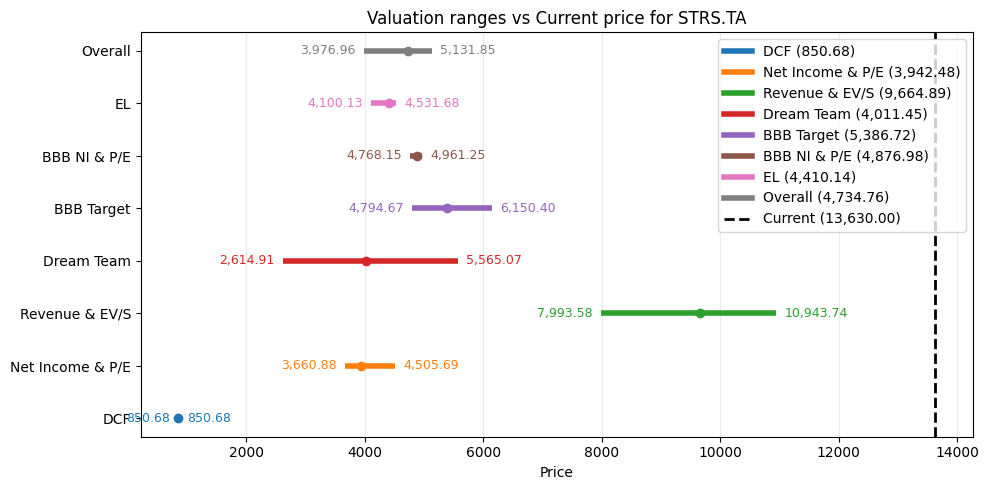

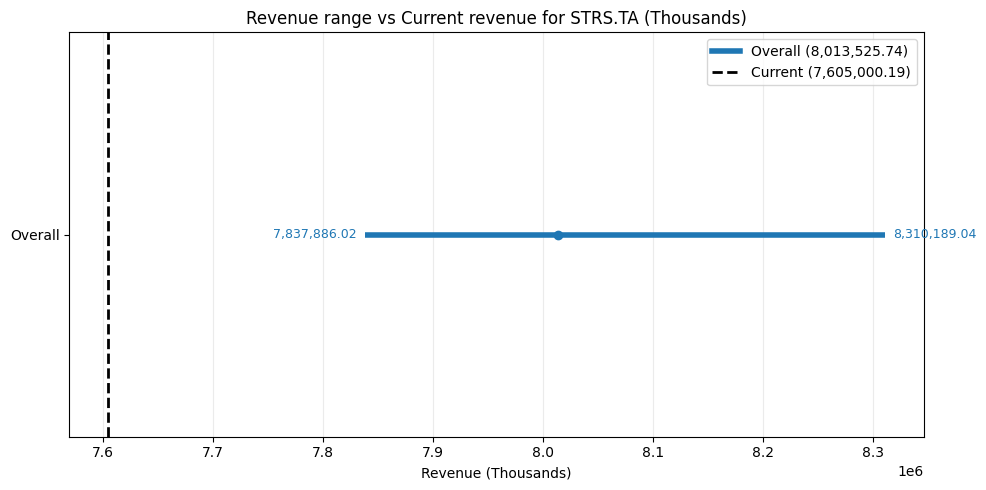

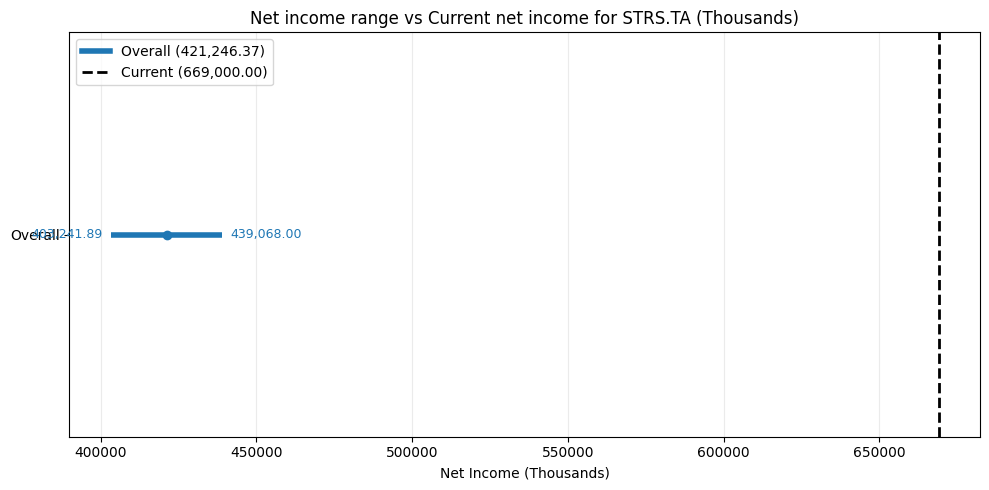

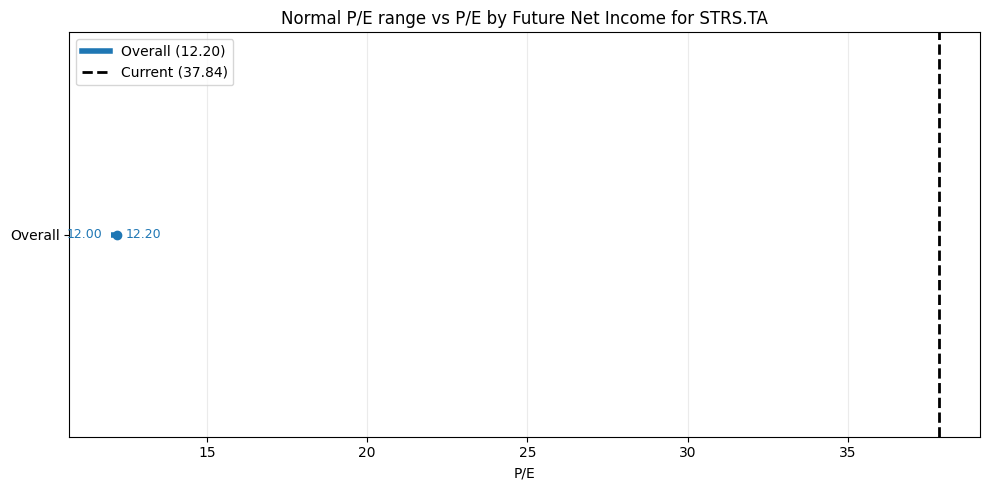

Ticker: STRS.TA
Current Price: 13629.999999999998
Price By Overall: 4394.8547021380045
NI By Overall: 453,826.51 (in Thousands)
PE By Overall: 13.143575499173954


In [ ]:
# Usage:
print(ticker)
plot_all_three(final_dict, ticker)
print_overall_valuations(ticker, final_dict, variables_dict)

In [ ]:
# pdf_downloader(ticker)

# VISUALIZATION


STRS.TA


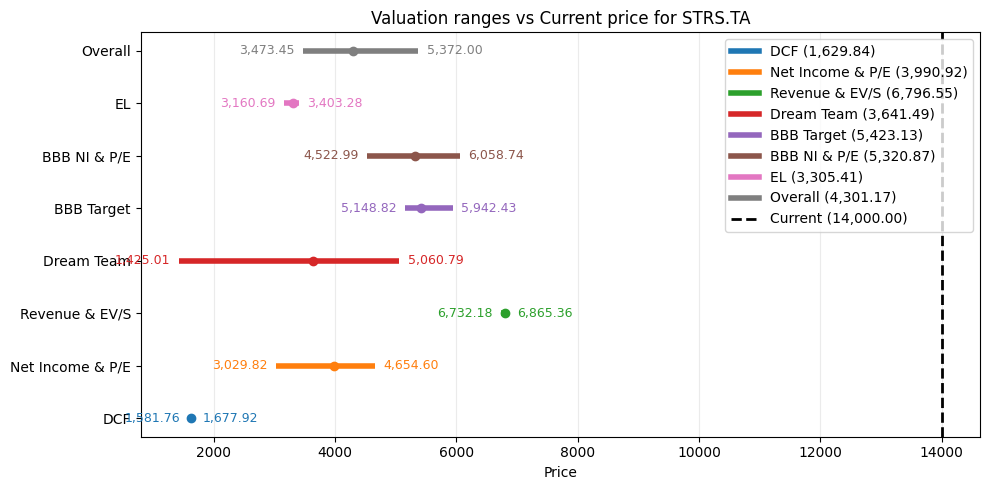

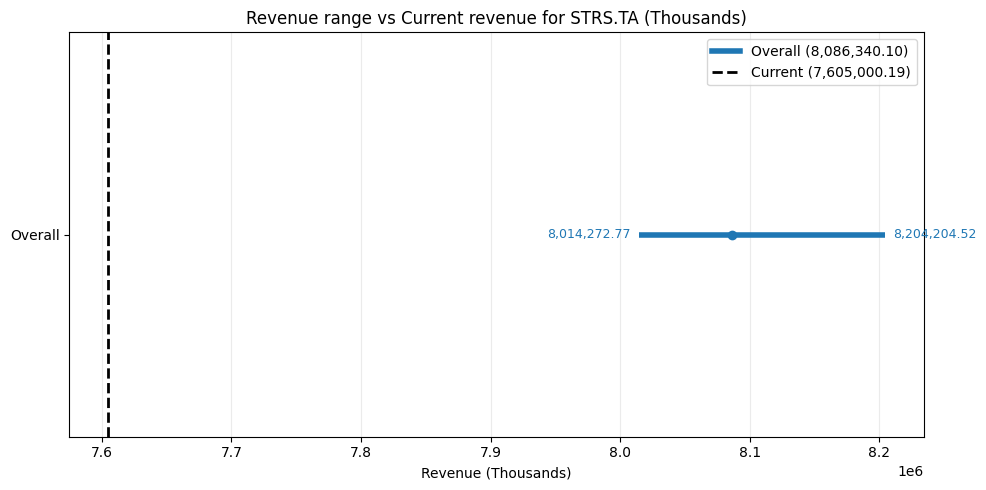

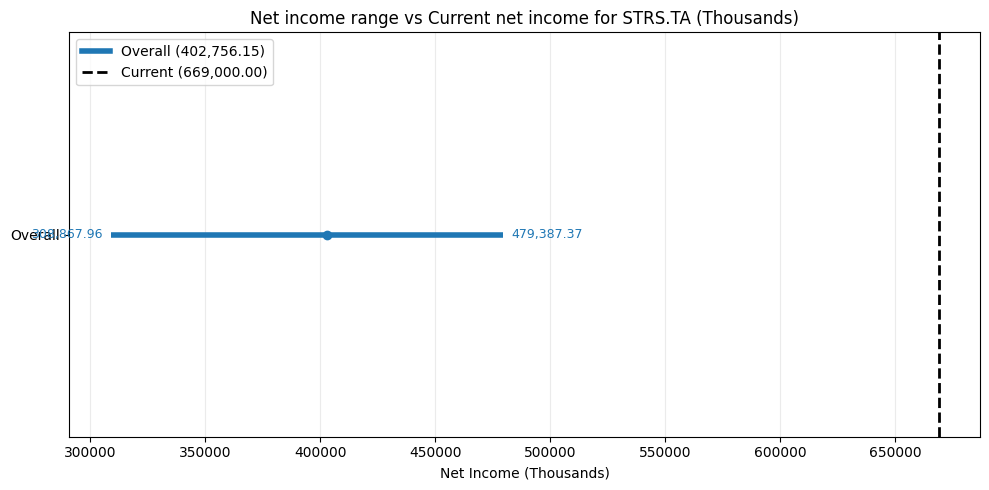

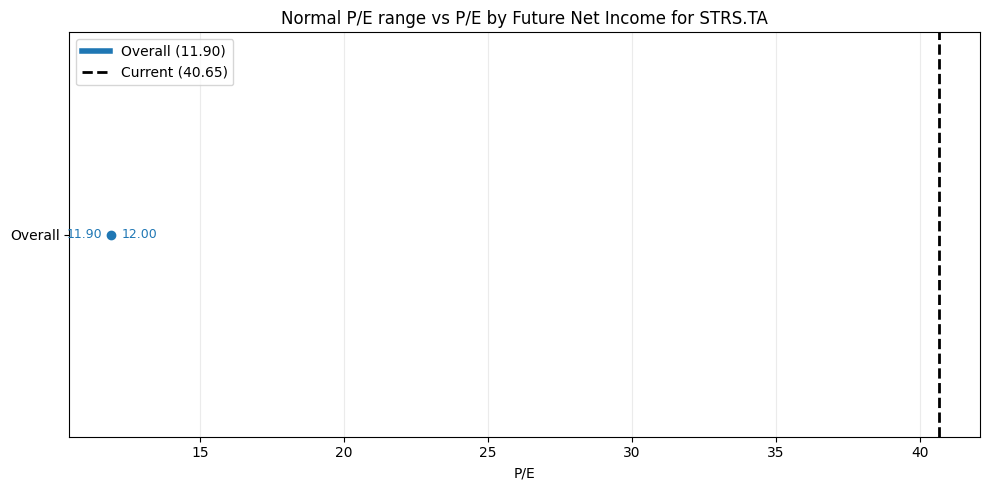

Ticker: STRS.TA
Current Price: 14000.0
Price By Overall: 4098.620095854961
NI By Overall: 422,660.19 (in Thousands)
PE By Overall: 12.48809291178282


In [ ]:
# Usage:
print(ticker)
plot_all_three(final_dict, ticker)
print_overall_valuations(ticker, final_dict, variables_dict)

In [ ]:
pdf_downloader(ticker)

DEBUG:fontTools.ttLib.ttFont:Reading 'maxp' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'maxp' table
DEBUG:fontTools.subset.timer:Took 0.009s to load 'maxp'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'maxp'
INFO:fontTools.subset:maxp pruned
DEBUG:fontTools.ttLib.ttFont:Reading 'cmap' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'cmap' table
DEBUG:fontTools.ttLib.ttFont:Reading 'post' table from disk
DEBUG:fontTools.ttLib.ttFont:Decompiling 'post' table
DEBUG:fontTools.subset.timer:Took 0.010s to load 'cmap'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'cmap'
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:fpgm dropped
INFO:fontTools.subset:prep dropped
INFO:fontTools.subset:cvt  dropped
INFO:fontTools.subset:kern dropped
DEBUG:fontTools.subset.timer:Took 0.000s to load 'post'
DEBUG:fontTools.subset.timer:Took 0.000s to prune 'post'
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:GPOS dropped
INFO:fontTools.subset:GSUB dropped
DEBUG:f

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Main

In [ ]:
def main_function(ticker, download_text = False, download_pdf = True, download_pptx = False, download_excel = False):
  info_dict, files_dict, financial_dict, variables_dict = make_analysis_file(ticker)
  if not info_dict.get("short_name"):
        print("No valid ticker")
        return {}
  text = load_text_from_file()
  final_dict = run_valuations(ticker, info_dict, financial_dict, variables_dict, text, n = 3)
  text = load_text_from_file()
  if download_excel:
    make_sicum_file_full(ticker, text, financial_dict, variables_dict, n_years = 3, n_runs = 1, append_to_file = True)
  download_text_pdf_pptx(download_text, download_pdf, download_pptx)
  plot_all_three(final_dict, ticker)
  print_overall_valuations(ticker, final_dict, variables_dict)
  return final_dict



In [ ]:
# ticker = "NICE"
# final_dict = main_function(ticker, download_text = False, download_pdf = False, download_pptx = False, download_excel = False)